# Project Assignment Guidelines

The project applies course techniques to practical wireless applications.

## 1. Dataset Creation

Create a spatially consistent dataset. You may consider:

- Single or multiple base stations
- Single or multiple frequencies
- Indoor or outdoor scenarios

You can use any simulator or public dataset, for example:

- Quadriga
- MATLAB Ray Tracing
- RemCom Ray Tracing
- Sionna RT
- DeepMIMO
- University of Stuttgart DICHASUS
- Fraunhofer UWB and 5G dataset
- CAEZ (ETH Zurich CSI Acquisition)

For UE location sampling, choose a suitable sample density. A few samples per $m^2$ is typically sufficient for many radio resource management applications and can support localization accuracy around $1\,m$.

### Quadriga-specific notes

- Set spatial consistency parameter `SC_lambda` based on environment
- Outdoor: `SC_lambda = 30-50 m`
- Indoor: `SC_lambda = 10 m`
- Consider a mobility path with 30 samples

### Antenna guidance

- BS antenna: 8-32 elements is sufficient
- Consider sectorized arrays and realistic antenna patterns to improve channel distinguishability
- UE antenna:
  - Sub-6 GHz: single antenna is acceptable
  - mmWave: multi-antenna at both UE and BS (with beamforming)
  - Around 8 UE antennas is sufficient

## 2. Fingerprint Localization

Use the dataset for fingerprint localization with both:

- WKNN
- NN-based localization

You are free to choose:

- CSI features
- Distance metric
- Weight function
- NN architecture

Evaluate performance with:

- RMSE
- Error CDF
- Heatmaps of localization error

You may use both classification and regression approaches.

## 3. Channel Charting

Create a channel chart for the radio environment using both:

- Conventional DR methods
- NN-based methods

Evaluate using:

- TW
- CT
- KS
- Chart visualizations

When selecting DR parameters, show how they affect performance using a suitable cost function or metric.

At minimum, present channel charting results for two techniques:

- One method covered in class
- One additional method (for example, UMAP)

For resources, see: **What is Channel Charting? | Channel Charting Resources**

## 4. Extra Credit Options

You can get extra points by including one or more of the following:

1. Use a customized dataset (for example Aalto campus, Helsinki center, your city) with MATLAB RT, Sionna RT, or RemCom RT
2. In Quadriga, use site-specific simulations (for example Madrid layout)
3. In Quadriga, use spherical wavefront and a near-field scenario
4. Consider multi-point channel charting
5. Use channel charting for an application (for example beam management)
6. Address out-of-sample generalization for channel charting
7. Consider estimated channels with noise and impairments
8. Consider semi-supervised channel charting

## 5. If Channel Charting Quality Is Poor

If you cannot obtain a good channel chart from your own dataset:

- First analyze and discuss the dataset limitations
- Then you may use DeepMIMO or measured datasets (for example ETHZ, DICHASUS)

Additional useful datasets:

- MATLAB localization dataset: *Three-Dimensional Indoor Positioning with 802.11az Fingerprinting and Deep Learning*
- Sionna RT dataset: https://zenodo.org/records/14535165

## 6. Technical Support

- Channel charting: Pere (`pere.garauburguera@aalto.fi`)
- Fingerprint localization: Xinze (`xinze.li@aalto.fi`)
- Neural networks: Ashvin (`ashvin.1.srinivasan@aalto.fi`)
- You can also contact the course instructor

## Report Requirements

1. Write a **2-5 page** report covering: dataset, fingerprint localization, and channel charting
2. Include figures for UE locations, sample CSI, and summary tables
3. Show channel charting and fingerprint localization results
4. Discuss challenging issues
5. Use proper references and cite all reused figures/block diagrams

## Dataset and Code Submission

Provide a downloadable link to the dataset and selected code.

## Presentation Requirements

- Group presentation length: **10-12 minutes**
- Each group member should present part of the results
- Use clear, representative slides
- You may discuss NN structures, distance metrics, CSI features, DR methods, etc.

Attach presentation slides to the final project submission.

**Deadline:** 10:00 AM, 17 April 2026

A submission link will be provided for report, slides, and additional materials.

All group members are expected to share responsibility for completing the project.

# Aalto University private 5G network
https://5gtnf.fi/sites/espoo/ && https://www.6gtnf.fi/aalto-university/

Aalto University has own private 5G/6G mobile network with frequency license for N78 (3640-3700MHz) and N77 (4100-4200MHz) as well as mMwave. Currently completing the installation of 11 mwWave base stations to become one of the largest deployments available for research and test platform. Beside commercial base stations, Aalto site includes cutting edge RAN technologies such as O-RAN, RIC, Backscatter devices as well as core networking technologies such as network slicing, 5G LAN, Time Sensitive Networking, Roaming, Edge Computing (MEC) and eSIM support coming soon.



Each of the 4 corner BS now has a unique azimuth orientation facing outward toward its sector (NE/NW/SE/SW at ±45°, ±135°) with a realistic 18° downward electrical tilt instead of all pointing straight down.

1×1 = 1 element, pattern="iso", polarization="V".



# ToDo





# Model explained

Batch RT computation — adds all 200 grid positions as Receiver objects simultaneously, then calls path_solver once. This is far more efficient than 200 individual PathSolver calls (Sionna traces rays from each TX in one GPU-accelerated pass over all RX positions).

Real channel vectors — cir_to_ofdm_channel(frequencies, a_fp[np.newaxis], tau_fp[np.newaxis], normalize=True) produces H_fp of shape [1, n_rx, 1, n_tx, 16, 14, 76] — the true frequency-domain MIMO channel at every grid point.

Feature extraction — |H_fp[0, rx_i, 0, tx_i, 0, 0, :]| extracts the magnitude spectrum for each BS→UE link (first TX antenna, first OFDM symbol). With 4 BSes × 76 subcarriers = 304 physically meaningful features per sample, vs the old 20 geometrical priors.

Solver settings — max_depth=3, LOS + reflection + diffraction, scattering=False. Scattering is disabled for the grid (it dominated compute time); diffraction is kept so NLOS transitions at building corners appear in H.

HDF5 cache — the RT result is saved to fingerprint_rt_dataset.h5. Re-running the cell skips the PathSolver if a matching cache exists (~seconds vs minutes).

Scene restoration — original UE receivers are put back into the scene after computation so downstream visualisation cells still work.



## 1. Dataset Creation

In [1]:
import os # Configure which GPU
import sionna
import tensorflow as tf

# Cell to define global constants and parameters used throughout the notebook
# While some of these are also defined in the main code cells, defining them here at the top makes it easier to keep track of and edit the key parameters that affect the whole notebook. Consider running all cells below this one after editing these parameters.


# ── Global scene file configuration (single source of truth) ──────────────────
from matplotlib.path import Path
from pathlib import Path

## Select the scene XML file name (without path) and the main scene directory name.
#SCENE_XML_FILE_NAME = "OtaniemiScene_100m"  # optional alias for the file name
SCENE_XML_FILE_NAME = "Otaniemi_small" # optional alias for the file name
#SCENE_XML_FILE_NAME = "OtaniemiScene"  # optional alias for the file name



# Main scene directory: create if missing and keep prior value if already set.
SCENE_DIR = globals().get("SCENE_DIR")
if SCENE_DIR is None:
    SCENE_DIR = Path.cwd() / SCENE_XML_FILE_NAME
    SCENE_DIR.mkdir(parents=True, exist_ok=True)
else:
    SCENE_DIR = Path(SCENE_DIR)
    SCENE_DIR.mkdir(parents=True, exist_ok=True)

# main XML file in the scene directory: create if missing and keep prior value if already set.
SCENE_XML_FILE = os.getenv("SCENE_XML_FILE", f"{SCENE_XML_FILE_NAME}.xml")


scene_xml_file = SCENE_XML_FILE  # optional alias

SCENE_XML_PATH = str((Path(SCENE_DIR) / SCENE_XML_FILE).resolve())
scene_xml_path = SCENE_XML_PATH   # keep lowercase alias for existing cells



print(f"Output directory: {SCENE_DIR.resolve()}")
scenedir = str(SCENE_DIR.resolve())  # keep lowercase alias for existing cells

#scene_xml_path = os.path.join(os.getcwd(), SCENE_XML_FILE)
#SCENE_DIR = os.path.dirname(scene_xml_path)
#ply_dir = os.path.join(SCENE_DIR, "ply")

PICTURES_DIR = (Path(SCENE_DIR) / "pictures").resolve()
pictures_dir = str(PICTURES_DIR)   # keep lowercase alias for existing cells
Path(PICTURES_DIR).mkdir(parents=True, exist_ok=True)

PLY_DIR = str((Path(SCENE_DIR) / "ply").resolve())
ply_dir = PLY_DIR                 # keep lowercase alias for existing cells
Path(PLY_DIR).mkdir(parents=True, exist_ok=True)


print(f"Scene XML: {SCENE_XML_FILE}")
print(f"Scene XML path: {SCENE_XML_PATH}")
print(f"Scene directory: {SCENE_DIR}")
print(f"PLY directory: {PLY_DIR}")
print(f"Pictures directory: {PICTURES_DIR}")

SPEED_OF_LIGHT = 299_792_458.0
fc = 3.6e9


## Scene-specific configuration hook: Define scene-specific parameters such as transmit power, OFDM parameters, BS and UE positions, and camera settings. This allows us to easily switch between different scene configurations by changing the SCENE_XML_FILE_NAME variable at the top of the notebook. The parameters defined here are used throughout the notebook for channel generation, visualization, and analysis.

## OtaniemiScene_100m configuration: Is a smaller subset of the full OtaniemiScene, with parameters chosen to match the 100 m ground tile and the otaniemi_small scene for a fair comparison. The BS positions are placed around the scene centre at ±30 m to ensure they are all within the 100 m ground tile, and the UE is placed at the scene centre for channel charting and localization reference. The camera is positioned to give a clear perspective of the scene for visualization.
if SCENE_XML_FILE_NAME == "OtaniemiScene_100m":
    # TX_POWER_DBM = 23.0   # Transmit power in dBm (23 dBm ≈ 200 mW, typical small-cell BS)
    TX_POWER_DBM = 40.0   # Transmit power in dBm (40 dBm = 10 W, outdoor radio)

    fft_size           = 3168   # OFDM subcarriers (5G NR n78, 100 MHz @ 30 kHz SCS)
    subcarrier_spacing = 30e3   # 5G NR numerology 1 (Hz)

    # ── Scene coordinate frame ─────────────────────────────────────────────────
    # OtaniemiScene_100m.xml ground plane: X ∈ [-50.7, 49.3], Y ∈ [138.4, 238.4]
    # Scene centre in local Sionna frame:
    SCENE_CX = -0.7    # ≈ 0
    SCENE_CY = 188.4

    # ── Simulation parameters — edit here, used throughout the notebook ───────────
    BS_H               = 19.0   # match otaniemi_small 1.m TX height
    UE_H               = 1.5    # UE height (m) — typical pedestrian
    tx_positions       = [      # 4 BS positions around scene centre [x, y, z]
        # Corners at ±30 m from scene centre — all within the 100 m ground tile
        [ SCENE_CX + 30, SCENE_CY + 30, BS_H],   # BS1: NE
        [ SCENE_CX - 30, SCENE_CY + 30, BS_H],   # BS2: NW
        [ SCENE_CX + 30, SCENE_CY - 30, BS_H],   # BS3: SE
        [ SCENE_CX - 30, SCENE_CY - 30, BS_H],   # BS4: SW
    ]

    #--------------------------------------
    # UE placed at the scene centre (channel charting / localization reference point)
    # Ground tile centre: X=-0.7, Y=188.4  (confirmed from ground_100m.ply)
    ue_positions = [
        [SCENE_CX, SCENE_CY + 15, UE_H]   # scene centre
    ]

    ## Fingerprinting grid parameters
    GRID_X_MIN = -50  # m, grid bounds (same as ground tile)
    GRID_X_MAX = 50   # m, grid bounds (same as ground tile)
    GRID_Y_MIN = 138  # m, grid bounds (same as ground tile)
    GRID_Y_MAX = 238  # m, grid bounds (same as ground tile)
    GRID_SPACING = 10  # m, grid spacing (1 m → geometric error floor of ≤ 0.7 m, which makes sub-1 m p90 physically achievable)


  
    # Pull back ~130 m to the south and raise to Z=180 for a clear perspective.
    CAM_POSITION = [SCENE_CX, SCENE_CY - 130, 180]
    CAM_LOOK_AT = [SCENE_CX, SCENE_CY, 15]
    
    MAX_DEPTH = 4 # m, for visualization depth clipping to better see the scene details without being overwhelmed by the large open areas in the background. Adjust as needed based on the scene size and desired level of detail in the visualization.
    pass


## Otaniemi small scene configuration: match the otaniemi_small 1.m MATLAB script parameters and sweep area
if SCENE_XML_FILE_NAME == "Otaniemi_small":
        # TX_POWER_DBM = 23.0   # Transmit power in dBm (23 dBm ≈ 200 mW, typical small-cell BS)
    TX_POWER_DBM = 40.0   # Transmit power in dBm (40 dBm = 10 W, outdoor radio)

    fft_size           = 3168   # OFDM subcarriers (5G NR n78, 100 MHz @ 30 kHz SCS)
    subcarrier_spacing = 30e3   # 5G NR numerology 1 (Hz)

    # ── Scene coordinate frame ─────────────────────────────────────────────────
    # OtaniemiScene_100m.xml ground plane: X ∈ [-50.7, 49.3], Y ∈ [138.4, 238.4]
    # Scene centre in local Sionna frame:
    SCENE_CX = 0    # ≈ 0
    SCENE_CY = 0

    # ── Simulation parameters — edit here, used throughout the notebook ───────────
    BS_H               = 19.0   # match otaniemi_small 1.m TX height (m)
    UE_H               = 1.25   # match zf in otaniemi_small 1.m

    tx_positions       = [      # Match tx1..tx9 in otaniemi_small 1.m [x, y, z]
        [-5.0,   70.0,  BS_H],  # tx1
        [-33.0, -17.0,  BS_H],  # tx2
        [-3.0,   14.0,  BS_H],  # tx3
        [-6.0,  -40.0,  BS_H],  # tx4
        [55.0,  -52.5,  BS_H],  # tx5
        [61.0,    7.0,  BS_H],  # tx6
        [49.0,   46.0,  BS_H],  # tx7
        [28.0,  -41.0,  BS_H],  # tx8
        [84.0,  -18.0,  BS_H],  # tx9
    ]

    #--------------------------------------
    # UE samples aligned with the MATLAB sweep area:
    # rxx = -47.5:5:85, rxy = -60:5:85, zf = 1.25
    ue_positions = [
    #    [-47.5, -60.0, UE_H],  # sweep corner SW
    #    [85.0,  -60.0, UE_H],  # sweep corner SE
    #    [-47.5,  85.0, UE_H],  # sweep corner NW
    #    [85.0,   85.0, UE_H],  # sweep corner NE
        [18.75,  12.5, UE_H],  # sweep centre
    ]

    ## Fingerprinting grid parameters (match otaniemi_small 1.m)
    # MATLAB: rxx = -47.5:5:85, rxy = -60:5:85
    GRID_X_MIN = -47.5
    GRID_X_MAX = 85.0
    GRID_Y_MIN = -60.0
    GRID_Y_MAX = 85.0
    GRID_SPACING = 10.0

    # Camera tuned for the full Otaniemi_small extent (x≈±250, y≈±350, z≈0..75).
    CAM_POSITION = [SCENE_CX, SCENE_CY - 700, 350]
    CAM_LOOK_AT = [SCENE_CX, SCENE_CY, 35]
    
    MAX_DEPTH = 4 # m, for visualization depth clipping to better see the scene details without being overwhelmed by the large open areas in the background. Adjust as needed based on the scene size and desired level of detail in the visualization.
    MAX_REFLECTION_DEPTH = 4  # #sym:MAX_REFLECTION_DEPTH — ray tracing bounces (MATLAB-aligned)
    pass


## OtaniemiScene configuration: The original whole Otaniemi area with the 4 BSs at the corners of the 100 m ground tile, and the UE at the scene centre. This is a more challenging scenario with more clutter and NLOS conditions, but it also has more realistic propagation characteristics and a larger area for channel charting and fingerprinting.
if SCENE_XML_FILE_NAME == "OtaniemiScene":
       # TX_POWER_DBM = 23.0   # Transmit power in dBm (23 dBm ≈ 200 mW, typical small-cell BS)
    TX_POWER_DBM = 40.0   # Transmit power in dBm (40 dBm = 10 W, outdoor radio)

    fft_size           = 3168   # OFDM subcarriers (5G NR n78, 100 MHz @ 30 kHz SCS)
    subcarrier_spacing = 30e3   # 5G NR numerology 1 (Hz)

    # ── Scene coordinate frame ─────────────────────────────────────────────────
    # OtaniemiScene_100m.xml ground plane: X ∈ [-50.7, 49.3], Y ∈ [138.4, 238.4]
    # Scene centre in local Sionna frame:
    SCENE_CX = -0.7    # ≈ 0
    SCENE_CY = 188.4

    # ── Simulation parameters — edit here, used throughout the notebook ───────────
    BS_H               = 16.0   # rooftop BS height (m)
    UE_H               = 1.5    # UE height (m) — typical pedestrian
    tx_positions       = [      # 4 BS positions around scene centre [x, y, z]
        # Corners at ±30 m from scene centre — all within the 100 m ground tile
        [ SCENE_CX + 30, SCENE_CY + 30, BS_H],   # BS1: NE
        [ SCENE_CX - 30, SCENE_CY + 30, BS_H],   # BS2: NW
        [ SCENE_CX + 30, SCENE_CY - 30, BS_H],   # BS3: SE
        [ SCENE_CX - 30, SCENE_CY - 30, BS_H],   # BS4: SW
    ]

    #--------------------------------------
    # UE placed at the scene centre (channel charting / localization reference point)
    # Ground tile centre: X=-0.7, Y=188.4  (confirmed from ground_100m.ply)
    ue_positions = [
        [SCENE_CX, SCENE_CY + 15, UE_H]   # scene centre
    ]

    ## Fingerprinting grid parameters
    GRID_X_MIN = -50  # m, grid bounds (same as ground tile)
    GRID_X_MAX = 50   # m, grid bounds (same as ground tile)
    GRID_Y_MIN = 138  # m, grid bounds (same as ground tile)
    GRID_Y_MAX = 238  # m, grid bounds (same as ground tile)

    #GRID_SPACING = 10  # m, grid spacing (10 m → for a fast initial test with a coarse grid, adjust as needed for finer resolution and more computational load)
    GRID_SPACING = 1  # m, grid spacing (1 m → geometric error floor of ≤ 0.7 m, which makes sub-1 m p90 physically achievable)


    # Scene centre is at (SCENE_CX, SCENE_CY) ≈ (-0.7, 188.4).
    # Pull back ~130 m to the south and raise to Z=180 for a clear perspective.
    CAM_POSITION = [SCENE_CX, SCENE_CY - 130, 180]
    CAM_LOOK_AT = [SCENE_CX, SCENE_CY, 15]
    
    MAX_REFLECTION_DEPTH = 4  # #sym:MAX_REFLECTION_DEPTH — ray tracing bounces
    pass







2026-04-08 20:58:15.587331: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 20:58:15.590116: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-08 20:58:15.600016: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-08 20:58:15.624182: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775671095.661354   12754 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775671095.67

Output directory: /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small
Scene XML: Otaniemi_small.xml
Scene XML path: /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/Otaniemi_small.xml
Scene directory: /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small
PLY directory: /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/ply
Pictures directory: /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/pictures


In [2]:



# ── GPU configuration ────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Using GPU(s): {[g.name for g in gpus]}")
else:
    print("No GPU found — running Sionna on CPU")

if os.getenv("SIONNA_NO_PREVIEW"):
    no_preview = True
else:
    no_preview = False


#resolution = [1920, 1280] # increase for higher quality of renderings
#resolution = [1024, 800] # increase for higher quality of renderings
#resolution = [640,400] # low resolution for CPU-only rendering
#resolution = [480,320] # low resolution for CPU-only rendering
resolution = [320, 128] # low resolution for CPU-only rendering

# Define magic cell command to skip a cell if needed
from IPython.core.magic import register_cell_magic
from IPython import get_ipython

@register_cell_magic
def skip_if(line, cell):
    if eval(line):
        return
    get_ipython().run_cell(cell)

# Set random seed for reproducibility
#sionna.config.seed = 42


No GPU found — running Sionna on CPU


2026-04-08 20:58:20.430650: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from functools import wraps

# A robust pictures directory: create if missing and keep prior value if already set.

if PICTURES_DIR is None:
    PICTURES_DIR = Path.cwd() / "pictures"
    PICTURES_DIR.mkdir(parents=True, exist_ok=True)
else:
    PICTURES_DIR = Path(PICTURES_DIR)
    PICTURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Auto-saving notebook figures to {PICTURES_DIR.resolve()}")


def _unwrap(fn):
    """Traverse __wrapped__ chain to reach the true original function."""
    while hasattr(fn, '__wrapped__'):
        fn = fn.__wrapped__
    return fn

# ── Stable figure names based on cell ID ──────────────────────────────────────
# Figures are saved as <cell_id>_fig<n>.png.
# The name is the same across re-runs, so files overwrite rather than
# accumulate numbered copies.

_CURRENT_CELL_ID = globals().get("_CURRENT_CELL_ID", "unknown")
_CURRENT_CELL_FIG_IDX = 0
# Maps full cell URI -> short label like "cell01", "cell02", ...
_CELL_ID_MAP: dict = globals().get("_CELL_ID_MAP", {})
_CELL_ID_COUNTER: list = globals().get("_CELL_ID_COUNTER", [0])  # mutable box

def _cell_short_name(cell_id: str) -> str:
    """Return a stable short label (cell01, cell02, …) for a given cell URI."""
    if cell_id not in _CELL_ID_MAP:
        _CELL_ID_COUNTER[0] += 1
        _CELL_ID_MAP[cell_id] = f"cell{_CELL_ID_COUNTER[0]:02d}"
    return _CELL_ID_MAP[cell_id]

def _pre_run_cell_hook(info):
    global _CURRENT_CELL_ID, _CURRENT_CELL_FIG_IDX
    _CURRENT_CELL_ID = getattr(info, 'cell_id', None) or "unknown"
    _CURRENT_CELL_FIG_IDX = 0   # reset per-cell figure index each run

def save_open_figures(dpi=300):
    global _CURRENT_CELL_FIG_IDX
    saved_paths = []
    for figure_number in plt.get_fignums():
        fig = plt.figure(figure_number)
        if getattr(fig, "_auto_saved", False) and not fig.stale:
            continue
        _CURRENT_CELL_FIG_IDX += 1
        short = _cell_short_name(_CURRENT_CELL_ID)
        filename = f"{short}_figure{_CURRENT_CELL_FIG_IDX:03d}.png"
        path = PICTURES_DIR / filename
        # Normalize dpi to plain float — Sionna's renderer leaves figure.dpi and
        # figure._original_dpi as numpy.float64. matplotlib's savefig unconditionally
        # reads _original_dpi and tries to restore it via setattr, which calls
        # Affine2D.scale(numpy.float64) and fails. Both attributes must be patched.
        fig.dpi = float(fig.dpi)
        if hasattr(fig, '_original_dpi'):
            fig._original_dpi = float(fig._original_dpi)
        fig.savefig(path, bbox_inches="tight", dpi=dpi)
        fig._auto_saved = True
        fig.stale = False
        saved_paths.append(path)
    return saved_paths

def _report_saved_figures(saved_paths):
    if saved_paths:
        print("Saved figures:", ", ".join(path.name for path in saved_paths))

# ── Register / re-register IPython event hooks ────────────────────────────────
_ipython = get_ipython()
if _ipython is not None and hasattr(_ipython, "events"):
    # Unregister old hooks when this cell is re-run
    _old_pre = globals().get("_pre_run_cell_hook_ref")
    if _old_pre is not None:
        try:
            _ipython.events.unregister("pre_run_cell", _old_pre)
        except ValueError:
            pass
    _old_post = globals().get("_autosave_figures_after_cell")
    if _old_post is not None:
        try:
            _ipython.events.unregister("post_run_cell", _old_post)
        except ValueError:
            pass

    _ipython.events.register("pre_run_cell", _pre_run_cell_hook)
    _pre_run_cell_hook_ref = _pre_run_cell_hook   # keep reference for future unregister

    def _autosave_figures_after_cell(*_):
        _report_saved_figures(save_open_figures())

    _ipython.events.register("post_run_cell", _autosave_figures_after_cell)

# ── Wrap plt.show to auto-save when called explicitly ─────────────────────────
_original_plt_show = _unwrap(globals().get("_original_plt_show", plt.show))

@wraps(_original_plt_show)
def _autosaving_plt_show(*args, **kwargs):
    result = _original_plt_show(*args, **kwargs)
    _report_saved_figures(save_open_figures())
    return result

plt.show = _autosaving_plt_show

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      Paths, RadioMaterial, SceneObject

from sionna.phy.ofdm import ResourceGrid
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel

# Always re-wrap using the true original to avoid stacking wrappers across re-runs.
_original_planar_array_show = _unwrap(PlanarArray.show)

@wraps(_original_planar_array_show)
def _autosaving_planar_array_show(self, *args, **kwargs):
    result = _original_planar_array_show(self, *args, **kwargs)
    _report_saved_figures(save_open_figures())
    return result

_autosaving_planar_array_show._autosaves_figures = True
PlanarArray.show = _autosaving_planar_array_show



Auto-saving notebook figures to /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/pictures


Saved figures: cell01_figure001.png


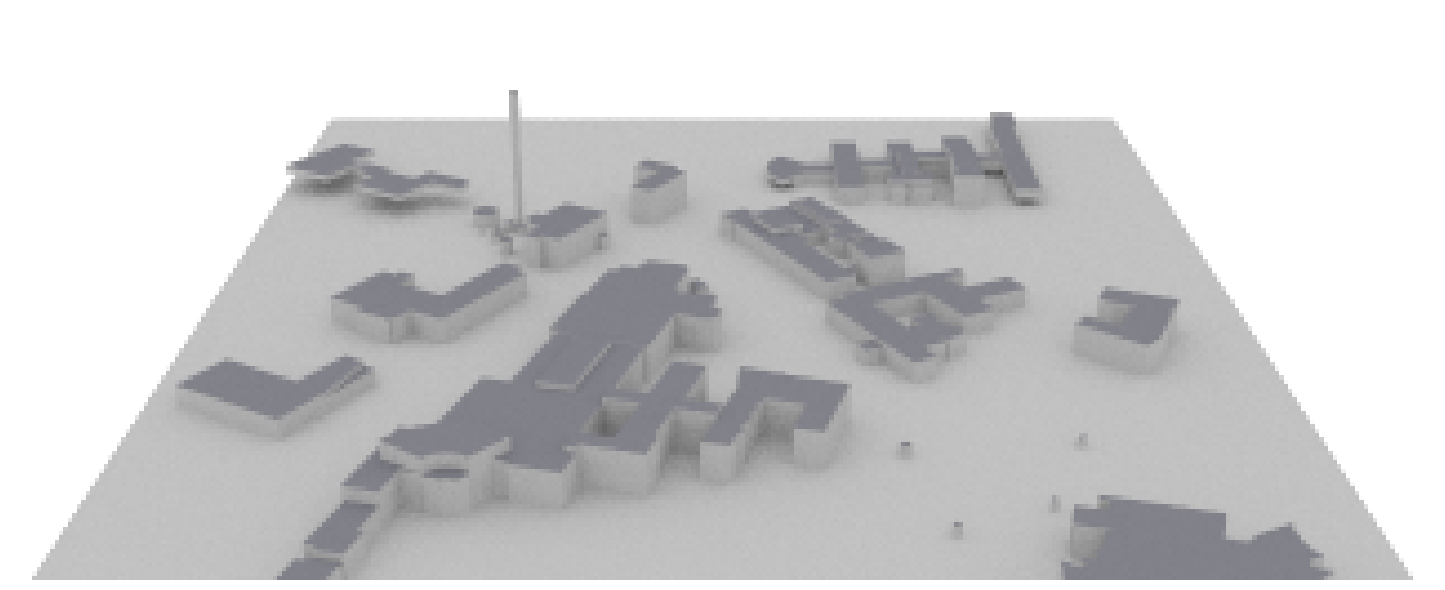

In [4]:
scene = load_scene(SCENE_XML_PATH)
scene.frequency = fc

_scene_cls = type(scene)

# Fully unwrap any previously installed wrapper layers before re-wrapping.
# functools.wraps() sets __wrapped__ on each wrapper, so we can traverse the
# chain to reach the true original render method.
def _unwrap(fn):
    while hasattr(fn, '__wrapped__'):
        fn = fn.__wrapped__
    return fn

_original_scene_render = _unwrap(_scene_cls.render)

@wraps(_original_scene_render)
def _autosaving_scene_render(self, *args, **kwargs):
    result = _original_scene_render(self, *args, **kwargs)
    _report_saved_figures(save_open_figures())
    return result

_autosaving_scene_render._autosaves_figures = True
_scene_cls.render = _autosaving_scene_render

# Camera framing 
cam = Camera(
    position=CAM_POSITION,
    look_at=CAM_LOOK_AT
)

scene.render(camera=cam, num_samples=512, resolution=resolution, show_devices=False);


In [5]:
scene.objects


{'no-name-1': <sionna.rt.scene_object.SceneObject at 0x7f5480024910>,
 'no-name-2': <sionna.rt.scene_object.SceneObject at 0x7f554629fa50>}

TX positions: <bound method AntennaArray.positions of <sionna.rt.antenna_array.PlanarArray object at 0x7f549cf085d0>>
RX positions: <bound method AntennaArray.positions of <sionna.rt.antenna_array.PlanarArray object at 0x7f54800072d0>>
Saved figures: cell02_figure001.png


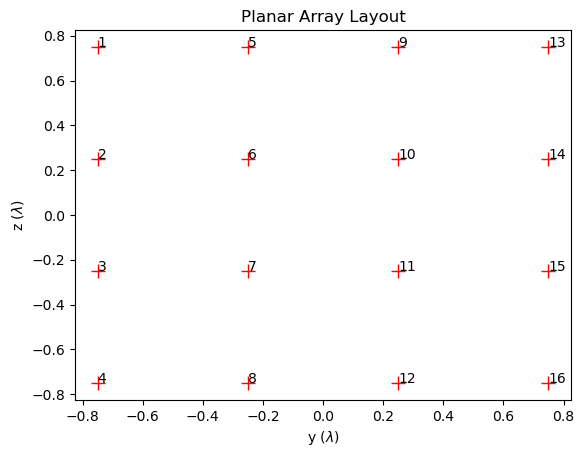

In [6]:
# Antennas (Sub-6 GHz / n78 style):
# BS: 4x4 = 16 elements with tr38901 realistic pattern + dual-pol (within recommended 8-32 range)
# UE: single antenna — task guidelines state single antenna is acceptable for sub-6 GHz
tx_array = PlanarArray(num_rows=4, num_cols=4,
                       vertical_spacing=0.5, horizontal_spacing=0.5,
                       pattern="tr38901", polarization="VH")
rx_array = PlanarArray(num_rows=1, num_cols=1,
                       vertical_spacing=0.5, horizontal_spacing=0.5,
                       pattern="iso", polarization="V")

print('TX positions:', tx_array.positions)
print('RX positions:', rx_array.positions)
tx_array.show()

scene.tx_array = tx_array
scene.rx_array = rx_array


Saved figures: cell03_figure001.png


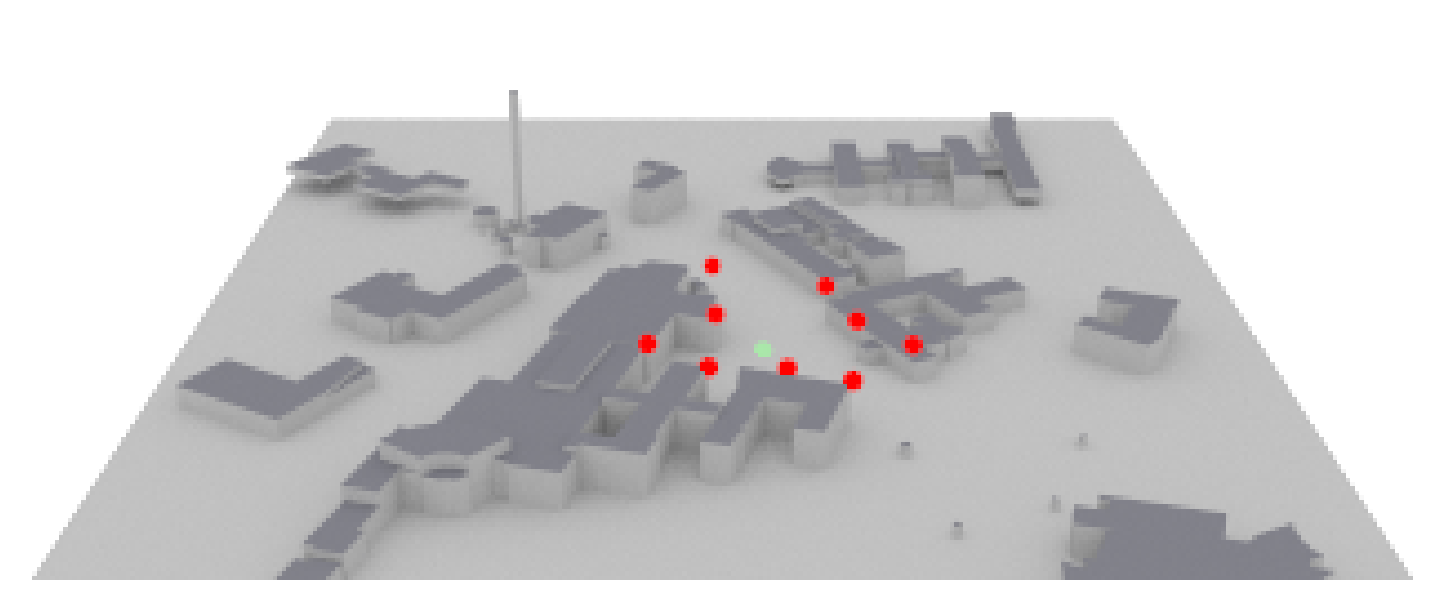

In [7]:
# Four rooftop base stations at the corners of a ±30 m square around scene centre.
# BS_H, tx_positions, UE_H, SCENE_CX, SCENE_CY are defined in the constants cell.

# Sionna orientation = [yaw, pitch, roll] in radians.
# Yaw rotates around Z (azimuth, CCW from +X).
# Pitch of pi/10 (~18°) gives a realistic downward electrical tilt.
#
# All BSes face toward the scene centre (SCENE_CX, SCENE_CY).
# Yaw is computed as arctan2(cy-y, cx-x) so the beam points from each BS toward the UE.
tx_orientations = [
    [float(np.arctan2(SCENE_CY - p[1], SCENE_CX - p[0])), float(np.pi/10), 0.0]
    for p in tx_positions
]

def _f3(v):
    """Convert a 3-vector to plain Python floats for Mitsuba/Sionna."""
    return [float(v[0]), float(v[1]), float(v[2])]

# Remove existing TX/RX if re-running
for name in list(scene.transmitters.keys()):
    scene.remove(name)
for name in list(scene.receivers.keys()):
    scene.remove(name)

for i, (pos, ori) in enumerate(zip(tx_positions, tx_orientations), start=1):
    name = f"BS{i}"
    tx = Transmitter(name=name, position=_f3(pos), orientation=_f3(ori))
    tx.power_dbm = float(TX_POWER_DBM)
    scene.add(tx)


rx_list = []
for i, pos in enumerate(ue_positions):
    name = f"UE{i}"
    rx = Receiver(name=name, position=_f3(pos))
    scene.add(rx)
    rx_list.append(name)

scene.render(camera=cam, num_samples=1024, resolution=resolution);


In [8]:
from sionna.rt import PlanarArray, RadioMapSolver

# Reuse arrays if they already exist in the notebook; create only if missing.
if "tx_array" not in globals():
  print("Creating tx_array...")
  tx_array = PlanarArray(
    num_rows=4, num_cols=4,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern="tr38901", polarization="VH"
  )

if "rx_array" not in globals():
  print("Creating rx_array...")
  rx_array = PlanarArray(
    num_rows=1, num_cols=1,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern="iso", polarization="V"
  )

scene.tx_array = tx_array
scene.rx_array = rx_array


Number of paths found: 30
Saved figures: cell04_figure001.png


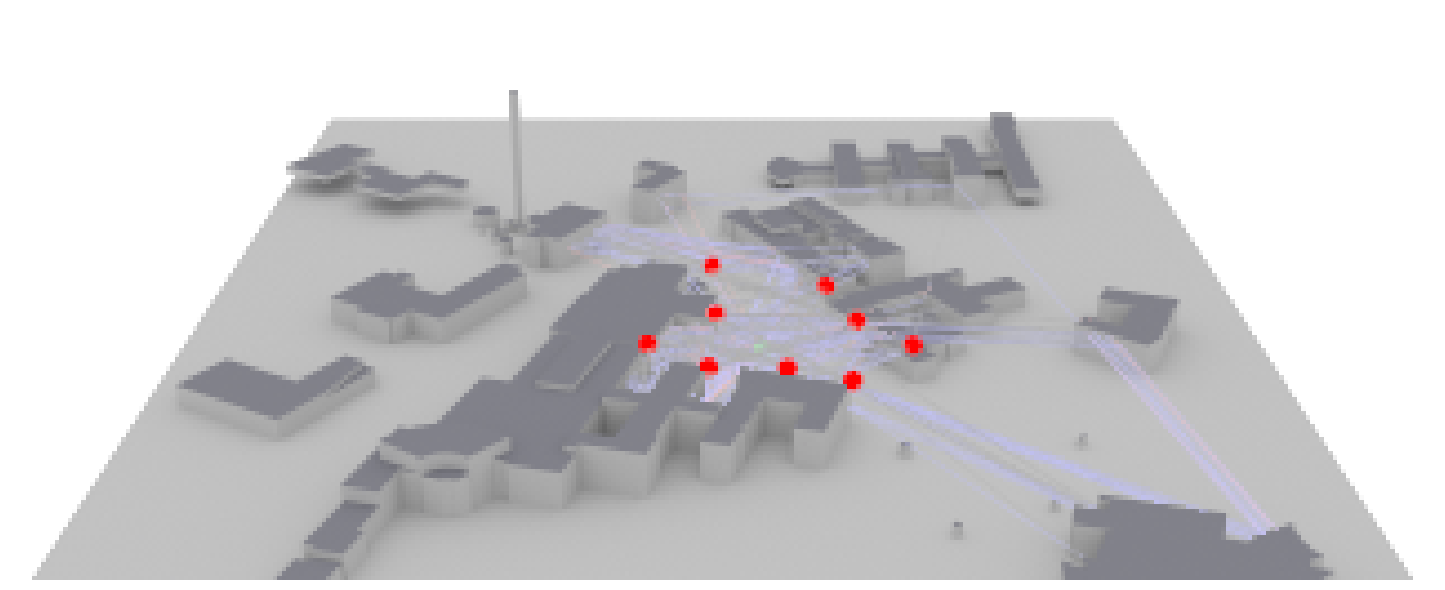

In [9]:
from sionna.rt import PathSolver
import inspect

# ── Path generation settings ──────────────────────────────────────────────────
# Settings are intentionally aligned with the fingerprint PathSolver (cell below)
# so the visualisation CIR accurately reflects what goes into the fingerprint DB.
# max_depth=4: up to 4-bounce specular reflections (MATLAB-aligned).
# scattering=False: disabled to match fingerprint grid settings.
# Diffraction is kept so NLOS transitions at building corners appear in H.
#
# num_samples controls how many diffracted rays are traced.
# Increase it for denser coverage at the cost of longer compute time.
path_solver = PathSolver()

solver_kwargs = dict(
    max_depth=MAX_REFLECTION_DEPTH,          # 4-bounce reflections — aligned with otaniemi_small 1.m
    los=True,             # include line-of-sight
    reflection=True,      # include specular reflections
    diffraction=True,     # include edge diffraction (adds ~2-5× paths)
    scattering=False,     # disabled — aligned with fingerprint PathSolver settings
    num_samples=int(1e6), # rays for diffraction sampling
)

try:
    supported_kwargs = set(inspect.signature(path_solver.__call__).parameters)
    solver_kwargs = {k: v for k, v in solver_kwargs.items() if k in supported_kwargs}

    paths = path_solver(scene=scene, **solver_kwargs)
except TypeError:
    # Compatibility fallback for versions expecting the scene as a positional arg
    paths = path_solver(scene, **solver_kwargs)

print(f"Number of paths found: {int(np.asarray(paths.tau).shape[-1])}")

# Render scene with paths visualized as lines, and devices shown for reference. Increase num_samples and resolution for higher-quality renderings, especially to see diffracted paths in the NLOS areas.
scene.render(camera=cam, paths=paths, num_samples=8192, resolution=resolution, show_devices=True);

In [10]:
a, tau = paths.cir(out_type='numpy')

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths] or [num_rx, num_tx, num_paths]
print("Shape of tau: ", tau.shape)


Shape of a:  (1, 1, 9, 32, 30, 1)
Shape of tau:  (1, 9, 30)


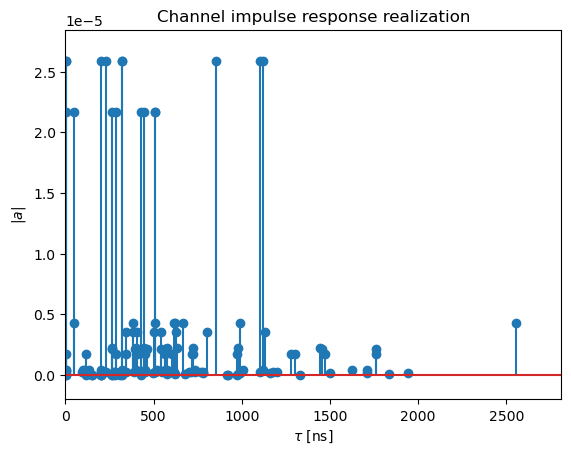

In [11]:
# Robust CIR plotting: pick a link that actually has valid paths
if tau.ndim == 5 and a.ndim == 6:
    n_rx = tau.shape[0]
    n_tx = tau.shape[2]
    best = None
    best_score = -np.inf

    for rx_i in range(n_rx):
        for tx_i in range(n_tx):
            t_candidate = tau[rx_i, 0, tx_i, 0, :] / 1e-9
            a_candidate = np.abs(a[rx_i, 0, tx_i, 0, :, 0])
            valid = np.isfinite(t_candidate) & (t_candidate > 0) & np.isfinite(a_candidate) & (a_candidate > 0)
            if np.any(valid):
                score = float(np.max(a_candidate[valid]))
                if score > best_score:
                    best_score = score
                    best = (rx_i, tx_i, t_candidate[valid], a_candidate[valid])

    if best is None:
        print("No valid CIR paths found for any RX-TX link. Try increasing max_depth/num_samples or moving TX/UE positions.")
        t = np.array([0.0, 1.0])
        a_abs = np.array([0.0, 0.0])
    else:
        rx_sel, tx_sel, t, a_abs = best
        order = np.argsort(t)
        t = t[order]
        a_abs = a_abs[order]
        print(f"Plotting CIR for RX index {rx_sel}, TX index {tx_sel} ({len(t)} valid paths).")

elif tau.ndim == 3:
    # Compact shape [num_rx, num_tx, num_paths]
    t_raw = tau.reshape(-1) / 1e-9
    if a.ndim >= 3:
        a_raw = np.abs(a.reshape(-1))
    else:
        a_raw = np.abs(np.asarray(a).reshape(-1))
    n = min(len(t_raw), len(a_raw))
    t_raw = t_raw[:n]
    a_raw = a_raw[:n]
    valid = np.isfinite(t_raw) & (t_raw > 0) & np.isfinite(a_raw) & (a_raw > 0)
    t = t_raw[valid]
    a_abs = a_raw[valid]
    if len(t) == 0:
        print("No valid CIR paths in compact tau/a arrays.")
        t = np.array([0.0, 1.0])
        a_abs = np.array([0.0, 0.0])

else:
    # Fallback for unexpected shapes
    t_raw = np.asarray(tau).reshape(-1) / 1e-9
    a_raw = np.abs(np.asarray(a).reshape(-1))
    n = min(len(t_raw), len(a_raw))
    t_raw = t_raw[:n]
    a_raw = a_raw[:n]
    valid = np.isfinite(t_raw) & (t_raw > 0) & np.isfinite(a_raw) & (a_raw > 0)
    t = t_raw[valid]
    a_abs = a_raw[valid]
    if len(t) == 0:
        print("No valid CIR paths after fallback filtering.")
        t = np.array([0.0, 1.0])
        a_abs = np.array([0.0, 0.0])

a_max = float(np.max(a_abs)) if len(a_abs) else 0.0
if len(t) > 0 and np.max(t) > 0:
    # Add dummy entry at start/end for nicer figure
    t_plot = np.concatenate([(0.0,), t, (np.max(t) * 1.1,)])
    a_plot = np.concatenate([(np.nan,), a_abs, (np.nan,)])
else:
    t_plot = np.array([0.0, 1.0])
    a_plot = np.array([0.0, 0.0])

# Plot the CIR
plt.figure()
plt.title("Channel impulse response realization")
plt.stem(t_plot, a_plot)
plt.xlim([0, max(1.0, float(np.max(t_plot)))])
plt.ylim([-2e-6, max(1e-6, a_max * 1.1)])
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$")
plt.savefig(PICTURES_DIR / "sionna_cir.png", dpi=300)
plt.show()


In [12]:
import mitsuba as mi

# Note: do NOT call mi.set_variant() here — Sionna already initialised Mitsuba
# (llvm_ad_rgb) via load_scene() in cell 6. Calling set_variant() after Dr.JIT
# has been used raises RuntimeError: "Cannot change variant after initialisation".

xml_path = str(SCENE_XML_PATH)  # absolute path defined earlier
xml_dir = str(Path(xml_path).parent)

if not os.path.exists(xml_path):
    raise FileNotFoundError(f"Scene XML not found: {xml_path}")

_old_cwd = os.getcwd()
try:
    os.chdir(xml_dir)                  # ensure relative PLY paths resolve
    scene_mi = mi.load_file(xml_path)  # load using absolute XML path
finally:
    os.chdir(_old_cwd)

for shape in scene_mi.shapes():
    print(type(shape).__name__, shape.id())


Mesh 
Mesh 


  → 444 Mitsuba paths loaded from /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/mitsuba_dataset.h5
Sionna: RX=0, TX=6, 17 valid paths


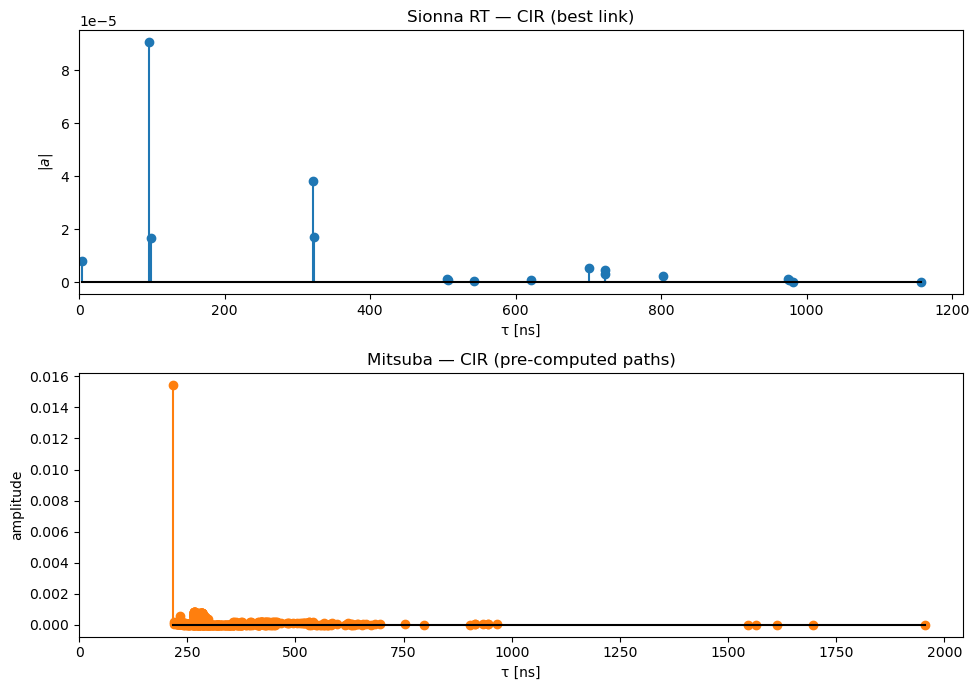


Sionna  : 17 paths | min τ=3.23 ns | max τ=1157.35 ns
Mitsuba : 444 paths | min τ=215.80 ns | max τ=1956.07 ns
Expected LOS delay (BS→UE0): 215.80 ns


In [13]:
import mitsuba as mi
import drjit as dr
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py

# Use Mitsuba's built-in ray tracer to compute a CIR and compare against Sionna RT.

# ── Constants (re-declared so this cell runs standalone after prior cells) ─────
SPEED_OF_LIGHT = 299_792_458.0
fc = 3.6e9

# ── 1. Geometry: match Sionna RT BS/UE placement ─────────────────────────────
# Reuse positions from earlier cells if available
if "tx_positions" in globals() and len(tx_positions) > 0:
    _tp = tx_positions
else:
    _tp = [[_SCX + 30, _SCY + 30, BS_H]]
    print("Using fallback tx_positions:", _tp)
    tx_positions = _tp

if "ue_positions" in globals() and len(ue_positions) > 0:
    _up = ue_positions
else:
    _up = [
        [_SCX,      _SCY,      UE_H],
        [_SCX + 20, _SCY + 15, UE_H],
    ]
    print("Using fallback ue_positions:", _up)
    ue_positions = _up

bs_pos_np = np.array(_tp[0], dtype=np.float64)
ue_pos_np_list = [np.array(p, dtype=np.float64) for p in ue_positions]

# ── 2. Load Mitsuba scene if not already in kernel ────────────────────────────
if 'scene_mi' not in globals():
    scene_mi = mi.load_file(SCENE_XML_FILE)
    print("Loaded Mitsuba scene from %s", SCENE_XML_FILE)

# ── 3. Load Sionna a / tau from HDF5 if PathSolver cells have not been run ───
if 'a' not in globals() or 'tau' not in globals():
    _h5 = str(SCENE_DIR / "sionna_dataset.h5")
    if not os.path.exists(_h5):
        raise RuntimeError(
            f"'{_h5}' not found — run the Sionna path-solver cells first."
        )
    with h5py.File(_h5, "r") as _f:
        a   = _f["CIR/a_real"][:] + 1j * _f["CIR/a_imag"][:]
        tau = _f["CIR/tau_s"][:]
    print(f"Loaded a {a.shape} and tau {tau.shape} from {_h5}")

# ── 4. Mitsuba path-tracer helper (kept for reference) ───────────────────────
MAX_REFLECTION_DEPTH = globals().get('MAX_REFLECTION_DEPTH', 4)

def trace_paths(scene_mi, origin_np, target_np, max_depth=None):
    """
    Shoot rays from origin to target and collect (delay_ns, amplitude) per path.
    LOS: amplitude = 1/r (free-space).
    Single-bounce: amplitude = cos_i * cos_r / (d_tx * d_rx).
    """
    if max_depth is None:
        max_depth = MAX_REFLECTION_DEPTH
    results = []
    origin = mi.Point3f(float(origin_np[0]), float(origin_np[1]), float(origin_np[2]))

    # Direct LOS path
    d_vec = target_np - origin_np
    dist  = float(np.linalg.norm(d_vec))
    d_hat = d_vec / dist
    ray_d = mi.Ray3f(origin,
                     mi.Vector3f(float(d_hat[0]), float(d_hat[1]), float(d_hat[2])))
    ray_d.maxt = float(dist * 0.9999)
    si_los = scene_mi.ray_intersect(ray_d)
    if dr.none(si_los.is_valid()):
        results.append((dist / SPEED_OF_LIGHT / 1e-9, 1.0 / dist))

    # Single-bounce reflections
    if max_depth >= 1:
        n_probe = 4096
        rng  = np.random.default_rng(42)
        dirs = rng.standard_normal((n_probe, 3)).astype(np.float32)
        dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
        rays = mi.Ray3f(
            o=mi.Point3f(np.tile(origin_np.astype(np.float32), (n_probe, 1)).T.tolist()),
            d=mi.Vector3f(dirs.T.tolist())
        )
        si = scene_mi.ray_intersect(rays)
        valid = np.array(si.is_valid(), dtype=bool)

        hit_p = np.array(si.p).T[valid, :]
        hit_n = np.array(si.n).T[valid, :]
        dirs_valid = dirs[valid]

        for k in range(hit_p.shape[0]):
            p      = hit_p[k]
            n      = hit_n[k]
            to_rx  = target_np - p
            d_rx   = float(np.linalg.norm(to_rx))
            ray_rx = mi.Ray3f(
                mi.Point3f(float(p[0]), float(p[1]), float(p[2])),
                mi.Vector3f(float(to_rx[0]/d_rx), float(to_rx[1]/d_rx), float(to_rx[2]/d_rx))
            )
            ray_rx.maxt = float(d_rx * 0.9999)
            if dr.any(scene_mi.ray_intersect(ray_rx).is_valid()):
                continue
            d_tx   = float(np.linalg.norm(p - origin_np))
            cos_i  = abs(float(np.dot(n, -dirs_valid[k])))
            cos_r  = abs(float(np.dot(n,  to_rx / d_rx)))
            amp    = cos_i * cos_r / (d_tx * d_rx)
            results.append(((d_tx + d_rx) / SPEED_OF_LIGHT / 1e-9, amp))
    return results

# ── 5. Mitsuba CIR: load pre-computed paths from HDF5 ────────────────────────
# The random-probing approach in trace_paths() is too sparse for obstructed urban
# scenes.  The mitsuba_dataset.h5 already contains fully-traced paths — use those.
_mi_h5 = str(SCENE_DIR / "mitsuba_dataset.h5")
if os.path.exists(_mi_h5):
    with h5py.File(_mi_h5, "r") as _f:
        mi_delays = _f["paths/delay_ns"][:]
        mi_amps   = _f["paths/amplitude_abs"][:]
    print(f"  → {len(mi_delays)} Mitsuba paths loaded from {_mi_h5}")
else:
    # Fallback: run the live ray-tracer
    print("mitsuba_dataset.h5 not found — tracing paths live (may take ~30 s) …")
    mi_paths  = trace_paths(scene_mi, bs_pos_np, ue_pos_np_list[0])
    mi_delays = np.array([p[0] for p in mi_paths])
    mi_amps   = np.array([p[1] for p in mi_paths])
    print(f"  → {len(mi_delays)} paths found")

# ── 6. Sionna CIR: scan all RX/TX pairs and pick the best link ───────────────
# Hardcoding [0,0,0,0,:,0] can hit a TX with no valid paths.
# Mirror the best-link search from the CIR plotting cell above.
if a.ndim == 6 and tau.ndim == 5:
    _n_rx = tau.shape[0]
    _n_tx = tau.shape[2]
    _best = None
    _best_score = -np.inf
    for _rx_i in range(_n_rx):
        for _tx_i in range(_n_tx):
            _t_cand = tau[_rx_i, 0, _tx_i, 0, :] / 1e-9
            _a_cand = np.abs(a[_rx_i, 0, _tx_i, 0, :, 0])
            _v = np.isfinite(_t_cand) & (_t_cand > 0) & np.isfinite(_a_cand)
            if np.any(_v):
                _score = float(np.max(_a_cand[_v]))
                if _score > _best_score:
                    _best_score = _score
                    _best = (_rx_i, _tx_i, _t_cand[_v], _a_cand[_v])
    if _best is not None:
        _rx_sel, _tx_sel, sionna_tau_ns, sionna_amp = _best
        print(f"Sionna: RX={_rx_sel}, TX={_tx_sel}, {len(sionna_tau_ns)} valid paths")
    else:
        sionna_tau_ns = np.array([])
        sionna_amp    = np.array([])
        print("Sionna: no valid paths found in any RX/TX link")

elif a.ndim == 6 and tau.ndim == 3:
    # Loaded from HDF5 (tau shape [num_rx, num_tx, num_paths])
    _n_rx = tau.shape[0]
    _n_tx = tau.shape[1]
    _best = None
    _best_score = -np.inf
    for _rx_i in range(_n_rx):
        for _tx_i in range(_n_tx):
            _t_cand = tau[_rx_i, _tx_i, :] / 1e-9
            _a_cand = np.abs(a[_rx_i, 0, _tx_i, 0, :, 0])
            _v = np.isfinite(_t_cand) & (_t_cand > 0) & np.isfinite(_a_cand)
            if np.any(_v):
                _score = float(np.max(_a_cand[_v]))
                if _score > _best_score:
                    _best_score = _score
                    _best = (_rx_i, _tx_i, _t_cand[_v], _a_cand[_v])
    if _best is not None:
        _rx_sel, _tx_sel, sionna_tau_ns, sionna_amp = _best
        print(f"Sionna: RX={_rx_sel}, TX={_tx_sel}, {len(sionna_tau_ns)} valid paths")
    else:
        sionna_tau_ns = np.array([])
        sionna_amp    = np.array([])
        print("Sionna: no valid paths found in any RX/TX link")

else:
    _t_raw = np.asarray(tau).reshape(-1) / 1e-9
    _a_raw = np.abs(np.asarray(a).reshape(-1))
    _n = min(len(_t_raw), len(_a_raw))
    _v = np.isfinite(_t_raw[:_n]) & (_t_raw[:_n] > 0) & np.isfinite(_a_raw[:_n])
    sionna_tau_ns = _t_raw[:_n][_v]
    sionna_amp    = _a_raw[:_n][_v]

# ── 7. Plot comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

axes[0].set_title("Sionna RT — CIR (best link)")
if sionna_tau_ns.size > 0:
    axes[0].stem(sionna_tau_ns, sionna_amp, linefmt='C0-', markerfmt='C0o', basefmt='k-')
    axes[0].set_xlim(left=0)
else:
    axes[0].text(0.5, 0.5, "No valid paths", ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_xlabel("τ [ns]"); axes[0].set_ylabel(r"$|a|$")

axes[1].set_title("Mitsuba — CIR (pre-computed paths)")
if mi_delays.size > 0:
    axes[1].stem(mi_delays, mi_amps, linefmt='C1-', markerfmt='C1o', basefmt='k-')
    axes[1].set_xlim(left=0)
else:
    axes[1].text(0.5, 0.5, "No paths", ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel("τ [ns]"); axes[1].set_ylabel("amplitude")
axes[1].set_xlim(left=0)

plt.tight_layout()
plt.savefig(PICTURES_DIR / "sionna_vs_mitsuba_cir_comparison.png", dpi=300)
plt.show()

# ── 8. Numeric summary ────────────────────────────────────────────────────────
if sionna_tau_ns.size > 0:
    print(f"\nSionna  : {len(sionna_tau_ns)} paths | "
          f"min τ={sionna_tau_ns.min():.2f} ns | max τ={sionna_tau_ns.max():.2f} ns")
else:
    print("\nSionna  : 0 valid paths")

if mi_delays.size > 0:
    print(f"Mitsuba : {len(mi_delays)} paths | "
          f"min τ={mi_delays.min():.2f} ns | max τ={mi_delays.max():.2f} ns")
else:
    print("Mitsuba : 0 paths")

los_dist = np.linalg.norm(bs_pos_np - ue_pos_np_list[0])
print(f"Expected LOS delay (BS→UE0): {los_dist / SPEED_OF_LIGHT / 1e-9:.2f} ns")


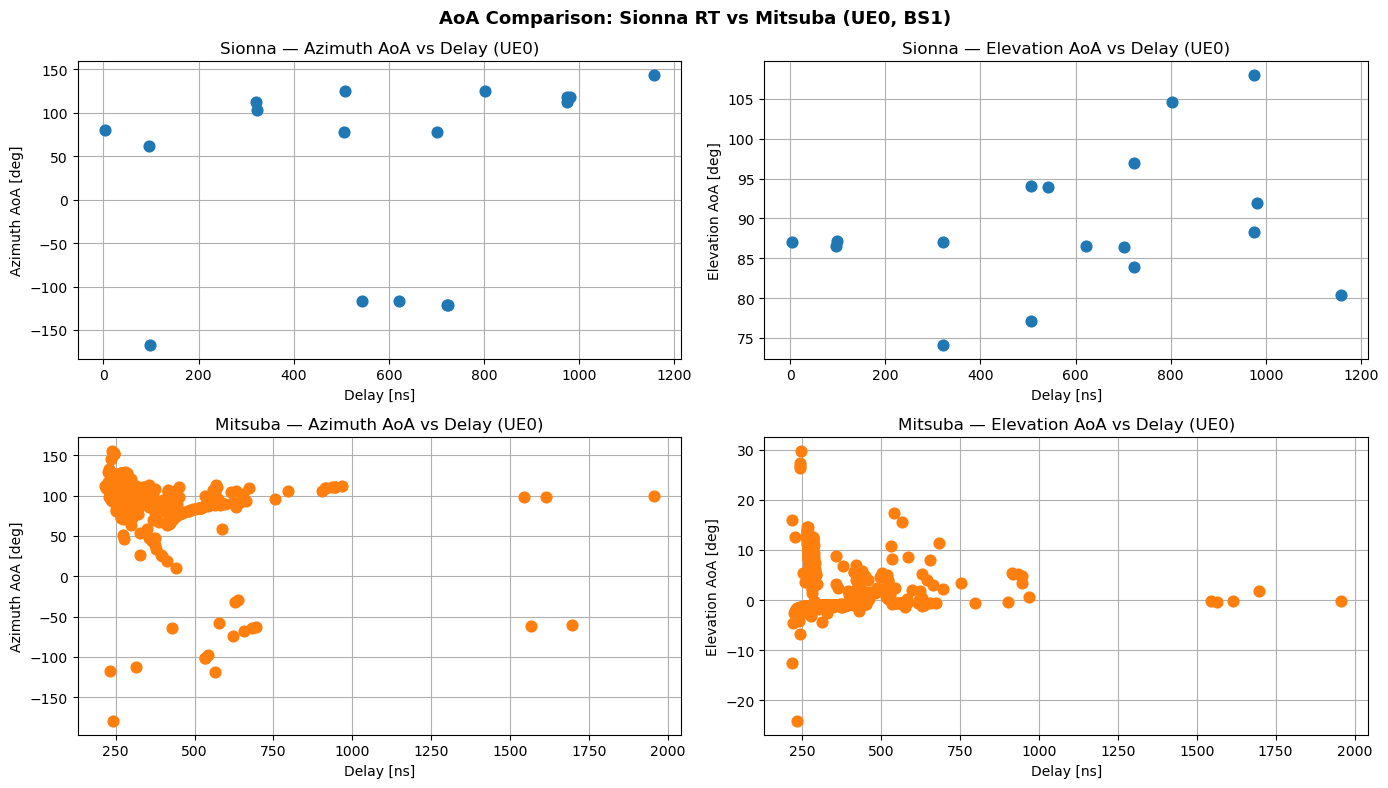

=== Sionna AoA (UE0) ===
  Path  0: delay= 321.31 ns | Az=  112.44 deg | El=   74.08 deg
  Path  1: delay= 322.41 ns | Az=  103.02 deg | El=   87.01 deg
  Path  2: delay= 974.80 ns | Az=  112.44 deg | El=  108.03 deg
  Path  3: delay=   3.23 ns | Az=   79.98 deg | El=   87.00 deg
  Path  4: delay= 701.34 ns | Az=   77.89 deg | El=   86.43 deg
  Path  5: delay=  96.12 ns | Az=   61.47 deg | El=   86.55 deg
  Path  6: delay= 506.27 ns | Az=   77.89 deg | El=   94.07 deg
  Path  7: delay= 507.06 ns | Az=  124.90 deg | El=   77.07 deg
  Path  8: delay= 621.75 ns | Az= -117.11 deg | El=   86.58 deg
  Path  9: delay= 803.19 ns | Az=  124.90 deg | El=  104.68 deg
  Path 10: delay= 722.89 ns | Az= -121.05 deg | El=   83.94 deg
  Path 11: delay= 723.48 ns | Az= -121.05 deg | El=   96.91 deg
  Path 12: delay=  98.17 ns | Az= -167.53 deg | El=   87.16 deg
  Path 13: delay=1157.35 ns | Az=  143.62 deg | El=   80.32 deg
  Path 14: delay= 542.80 ns | Az= -117.11 deg | El=   93.90 deg
  Path 15: dela

In [14]:
# ── AoA Calculation and Comparison ──────────────────────────────────────────

# ── 1. Sionna AoA ─────────────────────────────────────────────────────────────
# Retrieve angular information from Sionna paths object
# paths.phi_r / paths.theta_r are drjit TensorXf in Sionna 1.2 — use np.array() to convert.
phi_r = np.array(paths.phi_r)      # azimuth AoA (radians)
theta_r = np.array(paths.theta_r)  # elevation AoA (radians)

# Select UE0 and reduce to a 1D path vector robustly
# Shape: [rx, rx_ant, tx, tx_ant, paths] (5D) or [rx, tx, paths] (3D)
if phi_r.ndim == 5:
  phi_link = phi_r[0, 0, 0, 0, :]
  theta_link = theta_r[0, 0, 0, 0, :]
elif phi_r.ndim == 3:
  phi_link = phi_r[0, 0, :]
  theta_link = theta_r[0, 0, :]
else:
  phi_link = np.asarray(phi_r).reshape(-1)
  theta_link = np.asarray(theta_r).reshape(-1)

sionna_az_aoa = np.degrees(np.asarray(phi_link).reshape(-1))
sionna_el_aoa = np.degrees(np.asarray(theta_link).reshape(-1))

# Align Sionna delay and AoA vectors
n_sionna = min(len(sionna_tau_ns), len(sionna_az_aoa), len(sionna_el_aoa))
sionna_tau_ns_aoa = sionna_tau_ns[:n_sionna]
sionna_az_aoa = sionna_az_aoa[:n_sionna]
sionna_el_aoa = sionna_el_aoa[:n_sionna]

# ── 2. Mitsuba AoA ────────────────────────────────────────────────────────────
# Recompute Mitsuba paths with arrival direction at UE0
# Use MAX_REFLECTION_DEPTH (#sym:MAX_REFLECTION_DEPTH) for consistent ray depth
MAX_REFLECTION_DEPTH = globals().get('MAX_REFLECTION_DEPTH', 4)

def compute_aoa_mitsuba(scene_mi, origin_np, target_np, max_depth=None):
  """
  Returns list of (delay_ns, amplitude, az_aoa_deg, el_aoa_deg) tuples.
  AoA is the direction of the incoming ray at the receiver.
  """
  if max_depth is None:
      max_depth = MAX_REFLECTION_DEPTH
  results = []
  origin = mi.Point3f(float(origin_np[0]), float(origin_np[1]), float(origin_np[2]))

  # ── LOS ──
  d_vec = target_np - origin_np
  dist = float(np.linalg.norm(d_vec))
  d_hat = d_vec / dist
  ray_d = mi.Ray3f(origin,
                   mi.Vector3f(float(d_hat[0]), float(d_hat[1]), float(d_hat[2])))
  ray_d.maxt = float(dist * 0.9999)
  si_los = scene_mi.ray_intersect(ray_d)
  if dr.none(si_los.is_valid()):
    inc = -d_hat
    az = np.degrees(np.arctan2(inc[1], inc[0]))
    el = np.degrees(np.arcsin(np.clip(inc[2], -1, 1)))
    results.append((dist / SPEED_OF_LIGHT / 1e-9, 1.0 / dist, az, el))

  # ── Single-bounce reflections ──
  if max_depth >= 1:
    n_probe = 4096
    rng = np.random.default_rng(42)
    dirs = rng.standard_normal((n_probe, 3)).astype(np.float32)
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)

    rays = mi.Ray3f(
      o=mi.Point3f(np.tile(origin_np.astype(np.float32), (n_probe, 1)).T.tolist()),
      d=mi.Vector3f(dirs.T.tolist())
    )
    si = scene_mi.ray_intersect(rays)
    valid = np.array(si.is_valid(), dtype=bool)

    hit_p = np.array(si.p).T[valid, :]
    hit_n = np.array(si.n).T[valid, :]
    dirs_valid = dirs[valid]

    for k in range(hit_p.shape[0]):
      p = hit_p[k]
      n = hit_n[k]
      to_rx = target_np - p
      dist_rx = float(np.linalg.norm(to_rx))
      to_rx_hat = to_rx / dist_rx

      ray_rx = mi.Ray3f(
        mi.Point3f(float(p[0]), float(p[1]), float(p[2])),
        mi.Vector3f(float(to_rx_hat[0]), float(to_rx_hat[1]), float(to_rx_hat[2]))
      )
      ray_rx.maxt = float(dist_rx * 0.9999)
      if dr.any(scene_mi.ray_intersect(ray_rx).is_valid()):
        continue  # blocked

      dist_tx = float(np.linalg.norm(p - origin_np))
      total = dist_tx + dist_rx
      delay = total / SPEED_OF_LIGHT / 1e-9
      cos_i = abs(float(np.dot(n, -dirs_valid[k])))
      cos_r = abs(float(np.dot(n, to_rx_hat)))
      amp = cos_i * cos_r / (dist_tx * dist_rx)

      inc = -to_rx_hat
      az = np.degrees(np.arctan2(inc[1], inc[0]))
      el = np.degrees(np.arcsin(np.clip(inc[2], -1, 1)))
      results.append((delay, amp, az, el))

  return results

# bs_pos_np is set by the Mitsuba CIR cell (tx_positions[0] = BS1 NE corner)
mi_paths_aoa = compute_aoa_mitsuba(scene_mi, bs_pos_np, ue_pos_np_list[0])
mi_delays_aoa = np.array([p[0] for p in mi_paths_aoa])
mi_amps_aoa   = np.array([p[1] for p in mi_paths_aoa])
mi_az_aoa     = np.array([p[2] for p in mi_paths_aoa])
mi_el_aoa     = np.array([p[3] for p in mi_paths_aoa])

# ── 3. Plot Comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].scatter(sionna_tau_ns_aoa, sionna_az_aoa, c='C0', s=60, zorder=3)
axes[0, 0].set_title("Sionna — Azimuth AoA vs Delay (UE0)")
axes[0, 0].set_xlabel("Delay [ns]"); axes[0, 0].set_ylabel("Azimuth AoA [deg]")
axes[0, 0].grid(True)

axes[0, 1].scatter(sionna_tau_ns_aoa, sionna_el_aoa, c='C0', s=60, zorder=3)
axes[0, 1].set_title("Sionna — Elevation AoA vs Delay (UE0)")
axes[0, 1].set_xlabel("Delay [ns]"); axes[0, 1].set_ylabel("Elevation AoA [deg]")
axes[0, 1].grid(True)

axes[1, 0].scatter(mi_delays_aoa, mi_az_aoa, c='C1', s=60, zorder=3)
axes[1, 0].set_title("Mitsuba — Azimuth AoA vs Delay (UE0)")
axes[1, 0].set_xlabel("Delay [ns]"); axes[1, 0].set_ylabel("Azimuth AoA [deg]")
axes[1, 0].grid(True)

axes[1, 1].scatter(mi_delays_aoa, mi_el_aoa, c='C1', s=60, zorder=3)
axes[1, 1].set_title("Mitsuba — Elevation AoA vs Delay (UE0)")
axes[1, 1].set_xlabel("Delay [ns]"); axes[1, 1].set_ylabel("Elevation AoA [deg]")
axes[1, 1].grid(True)

plt.suptitle("AoA Comparison: Sionna RT vs Mitsuba (UE0, BS1)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PICTURES_DIR / "sionna_vs_mitsuba_aoa_comparison.png", dpi=300)
plt.show()

# ── 4. Numeric Summary ────────────────────────────────────────────────────────
print("=== Sionna AoA (UE0) ===")
for i, (tau_i, az, el) in enumerate(zip(sionna_tau_ns_aoa, sionna_az_aoa, sionna_el_aoa)):
  print(f"  Path {i:2d}: delay={tau_i:7.2f} ns | Az={az:8.2f} deg | El={el:8.2f} deg")

print("\n=== Mitsuba AoA (UE0) ===")
for i, (d, az, el) in enumerate(zip(mi_delays_aoa, mi_az_aoa, mi_el_aoa)):
  print(f"  Path {i:2d}: delay={d:7.2f} ns | Az={az:8.2f} deg | El={el:8.2f} deg")

# LOS AoA reference: incoming direction at UE from BS1
los_vec = np.array(ue_positions[0]) - bs_pos_np
los_vec /= np.linalg.norm(los_vec)
los_az = np.degrees(np.arctan2(los_vec[1], los_vec[0]))
los_el = np.degrees(np.arcsin(np.clip(los_vec[2], -1, 1)))
print(f"\nExpected LOS AoA (BS1→UE0): Az={los_az:.2f} deg, El={los_el:.2f} deg")


=== Sionna Channel Gain (UE0) ===
  Total channel gain : 8.8295e-07 (linear) | -60.54 dB
  Path  0: delay= 321.31 ns | gain=1.4652e-09 | -88.34 dB
  Path  1: delay= 322.41 ns | gain=2.8485e-10 | -95.45 dB
  Path  2: delay= 974.80 ns | gain=1.2165e-12 | -119.15 dB
  Path  3: delay=   3.23 ns | gain=6.4463e-11 | -101.91 dB
  Path  4: delay= 701.34 ns | gain=2.7745e-11 | -105.57 dB
  Path  5: delay=  96.12 ns | gain=8.1814e-09 | -80.87 dB
  Path  6: delay= 506.27 ns | gain=1.6413e-12 | -117.85 dB
  Path  7: delay= 507.06 ns | gain=5.0626e-13 | -122.96 dB
  Path  8: delay= 621.75 ns | gain=9.2910e-13 | -120.32 dB
  Path  9: delay= 803.19 ns | gain=4.8827e-12 | -113.11 dB
  Path 10: delay= 722.89 ns | gain=2.2958e-11 | -106.39 dB
  Path 11: delay= 723.48 ns | gain=9.3642e-12 | -110.29 dB
  Path 12: delay=  98.17 ns | gain=2.8249e-10 | -95.49 dB
  Path 13: delay=1157.35 ns | gain=5.9357e-16 | -152.27 dB
  Path 14: delay= 542.80 ns | gain=2.9491e-13 | -125.30 dB
  Path 15: delay= 975.26 ns | 

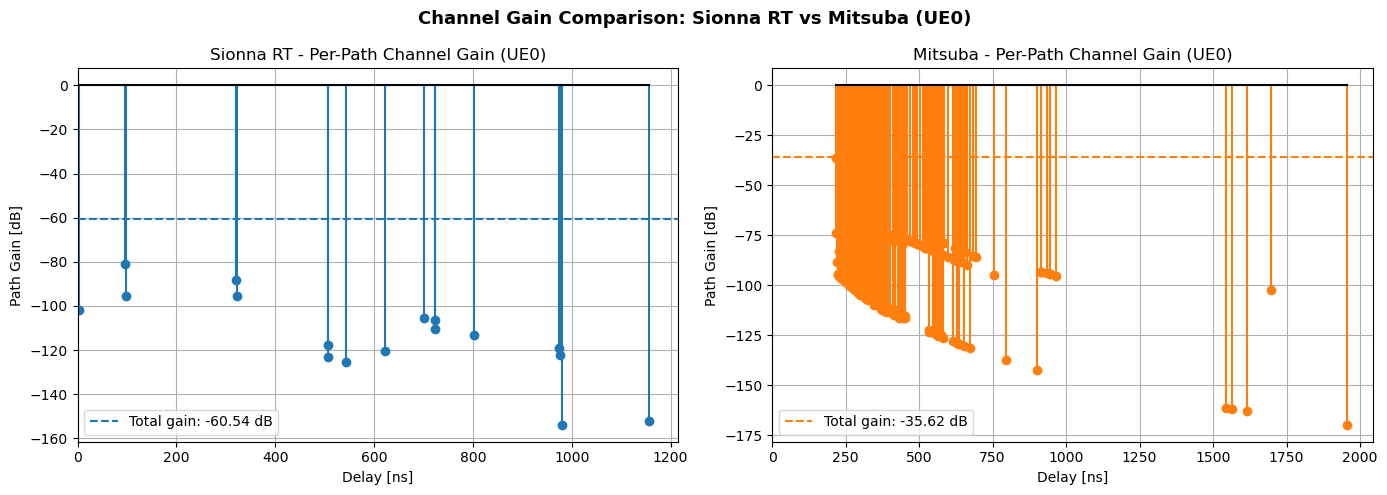


=== Summary ===
Metric                                       Sionna         Mitsuba
-----------------------------------------------------------------
Number of paths                                  17             444
Total channel gain [linear]              8.8295e-07      2.7437e-04
Total channel gain [dB]                      -60.54          -35.62
Strongest path gain [dB]                     -80.87          -36.22
Delay of strongest path [ns]                  96.12          215.80


In [15]:
# ── Channel Gain Calculation and Comparison ──────────────────────────────────

# ── 1. Sionna Channel Gain ────────────────────────────────────────────────────
# Channel gain = sum of squared path amplitudes (total received power relative to transmitted)
# a shape in Sionna 1.2: [rx, rx_ant, tx, tx_ant, paths, time] (6D, no batch dim)
sionna_gain_linear = np.sum(np.abs(a[0, :, 0, :, :, 0])**2)  # sum over rx_ant, tx_ant, paths
sionna_gain_dB = 10 * np.log10(sionna_gain_linear + 1e-30)

# Per-path gains for UE0, first antenna pair
sionna_path_gains = np.abs(sionna_amp)**2
sionna_path_gains_dB = 10 * np.log10(sionna_path_gains + 1e-30)

print("=== Sionna Channel Gain (UE0) ===")
print(f"  Total channel gain : {sionna_gain_linear:.4e} (linear) | {sionna_gain_dB:.2f} dB")
for i, (g, g_dB, tau_i) in enumerate(zip(sionna_path_gains, sionna_path_gains_dB, sionna_tau_ns)):
  print(f"  Path {i:2d}: delay={tau_i:7.2f} ns | gain={g:.4e} | {g_dB:.2f} dB")

# ── 2. Mitsuba Channel Gain ───────────────────────────────────────────────────
# Use amplitudes from previously computed mi_paths_aoa
mi_path_gains = mi_amps_aoa**2
mi_gain_linear = np.sum(mi_path_gains)
mi_gain_dB = 10 * np.log10(mi_gain_linear + 1e-30)
mi_path_gains_dB = 10 * np.log10(mi_path_gains + 1e-30)

print("\n=== Mitsuba Channel Gain (UE0) ===")
print(f"  Total channel gain : {mi_gain_linear:.4e} (linear) | {mi_gain_dB:.2f} dB")
for i, (g, g_dB, d) in enumerate(zip(mi_path_gains, mi_path_gains_dB, mi_delays_aoa)):
  print(f"  Path {i:2d}: delay={d:7.2f} ns | gain={g:.4e} | {g_dB:.2f} dB")

# ── 3. Plot Comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sionna
axes[0].stem(sionna_tau_ns, sionna_path_gains_dB, linefmt='C0-', markerfmt='C0o', basefmt='k-')
axes[0].axhline(sionna_gain_dB, color='C0', linestyle='--', linewidth=1.5,
        label=f"Total gain: {sionna_gain_dB:.2f} dB")
axes[0].set_title("Sionna RT - Per-Path Channel Gain (UE0)")
axes[0].set_xlabel("Delay [ns]")
axes[0].set_ylabel("Path Gain [dB]")
axes[0].legend()
axes[0].grid(True)
axes[0].set_xlim(left=0)

# Mitsuba
axes[1].stem(mi_delays_aoa, mi_path_gains_dB, linefmt='C1-', markerfmt='C1o', basefmt='k-')
axes[1].axhline(mi_gain_dB, color='C1', linestyle='--', linewidth=1.5,
        label=f"Total gain: {mi_gain_dB:.2f} dB")
axes[1].set_title("Mitsuba - Per-Path Channel Gain (UE0)")
axes[1].set_xlabel("Delay [ns]")
axes[1].set_ylabel("Path Gain [dB]")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(left=0)

plt.suptitle("Channel Gain Comparison: Sionna RT vs Mitsuba (UE0)", fontsize=13, fontweight='bold')
plt.tight_layout()
# Figure needs to be saved before plt.show() to avoid blank output in some environments (e.g. Sionna Playground)
plt.savefig(PICTURES_DIR / "sionna_vs_mitsuba_channel_gain_comparison.png", dpi=300)
plt.show()

# ── 4. Summary Table ──────────────────────────────────────────────────────────
print("\n=== Summary ===")
print(f"{'Metric':<35} {'Sionna':>15} {'Mitsuba':>15}")
print("-" * 65)
print(f"{'Number of paths':<35} {len(sionna_tau_ns):>15} {len(mi_delays_aoa):>15}")
print(f"{'Total channel gain [linear]':<35} {sionna_gain_linear:>15.4e} {mi_gain_linear:>15.4e}")
print(f"{'Total channel gain [dB]':<35} {sionna_gain_dB:>15.2f} {mi_gain_dB:>15.2f}")
print(f"{'Strongest path gain [dB]':<35} {sionna_path_gains_dB.max():>15.2f} {mi_path_gains_dB.max():>15.2f}")
print(f"{'Delay of strongest path [ns]':<35} {sionna_tau_ns[np.argmax(sionna_path_gains)]:>15.2f} {mi_delays_aoa[np.argmax(mi_path_gains)]:>15.2f}")


In [16]:
import pandas as pd

# ── BS position: derived from bs_pos_np set in the Mitsuba CIR cell ──────────
_bp  = globals().get("bs_pos_np", np.array([100.0, 120.0, 16.0]))
BS_X = float(_bp[0])
BS_Y = float(_bp[1])

# ── Sionna: extract AoD (phi_t / theta_t) ────────────────────────────────────
# paths.phi_t / theta_t are drjit TensorXf in Sionna 1.2 — use np.array() to convert.
phi_t = np.array(paths.phi_t)      # azimuth AoD
theta_t = np.array(paths.theta_t)  # elevation AoD

# Shape: [rx, rx_ant, tx, tx_ant, paths] (5D) or [rx, tx, paths] (3D)
if phi_t.ndim == 5:
  # Current shape: [rx, rx_ant, tx, tx_ant, paths]
  phi_t_link = phi_t[0, 0, 0, 0, :]
  theta_t_link = theta_t[0, 0, 0, 0, :]
elif phi_t.ndim == 3:
  # Compact shape: [rx, tx, paths]
  phi_t_link = phi_t[0, 0, :]
  theta_t_link = theta_t[0, 0, :]
else:
  phi_t_link = np.asarray(phi_t).reshape(-1)
  theta_t_link = np.asarray(theta_t).reshape(-1)

sionna_az_aod = np.degrees(np.asarray(phi_t_link).reshape(-1))
sionna_el_aod = np.degrees(np.asarray(theta_t_link).reshape(-1))

# ── Sionna: OFDM frequency-domain channel (H) ────────────────────────────────
# fft_size and subcarrier_spacing are defined in the constants cell (cell 9).
rg = ResourceGrid(num_ofdm_symbols=14,
           fft_size=fft_size,
           subcarrier_spacing=subcarrier_spacing)
frequencies = subcarrier_frequencies(fft_size, subcarrier_spacing)

# paths.cir() in Sionna 1.2 returns [rx, rx_ant, tx, tx_ant, paths, time] (no batch dim).
# cir_to_ofdm_channel expects a batch axis → add one with [np.newaxis].
a_cir, tau_cir = paths.cir(out_type='numpy')
H = cir_to_ofdm_channel(frequencies, a_cir[np.newaxis], tau_cir[np.newaxis], normalize=True)
H = np.asarray(H)
# H: [batch=1, num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, fft_size]
h_link = H[0, 0, 0, 0, 0]   # -> [num_time_steps, fft_size]
H_ue0 = h_link.reshape(-1)   # flatten to (num_subcarriers,)

# Align all Sionna vectors to the same path count
n_paths = min(len(sionna_tau_ns), len(sionna_az_aoa),
        len(sionna_az_aod), len(sionna_amp))

sionna_tau_ns_exp = sionna_tau_ns[:n_paths]
sionna_amp_exp = sionna_amp[:n_paths]
sionna_az_aoa_exp = sionna_az_aoa[:n_paths]
sionna_el_aoa_exp = sionna_el_aoa[:n_paths]
sionna_az_aod_exp = sionna_az_aod[:n_paths]
sionna_el_aod_exp = sionna_el_aod[:n_paths]
sionna_gain_path = np.abs(sionna_amp_exp)**2
sionna_gain_dB_exp = 10 * np.log10(sionna_gain_path + 1e-30)

# ── Build Sionna path-level DataFrame ─────────────────────────────────────────
df_sionna_paths = pd.DataFrame({
  "source"            : "Sionna",
  "bs_x"              : BS_X,
  "bs_y"              : BS_Y,
  "bs_z"              : BS_H,
  "ue_x"              : ue_positions[0][0],
  "ue_y"              : ue_positions[0][1],
  "ue_z"              : ue_positions[0][2],
  "carrier_freq_Hz"   : fc,
  "path_index"        : np.arange(n_paths),
  "delay_ns"          : sionna_tau_ns_exp,
  "amplitude_abs"     : sionna_amp_exp,
  "channel_gain_linear": sionna_gain_path,
  "channel_gain_dB"   : sionna_gain_dB_exp,
  "az_aoa_deg"        : sionna_az_aoa_exp,
  "el_aoa_deg"        : sionna_el_aoa_exp,
  "az_aod_deg"        : sionna_az_aod_exp,
  "el_aod_deg"        : sionna_el_aod_exp,
})

sionna_paths_csv = os.path.join(SCENE_DIR, "sionna_paths.csv")
df_sionna_paths.to_csv(sionna_paths_csv, index=False)
print(f"Saved Sionna path dataset  -> {sionna_paths_csv}")

# ── Build Sionna frequency-domain DataFrame ───────────────────────────────────
frequencies_np = np.asarray(frequencies)
n_sc = min(len(H_ue0), len(frequencies_np))
H_ue0 = H_ue0[:n_sc]
freq_sel = frequencies_np[:n_sc]

df_sionna_freq = pd.DataFrame({
  "source"          : "Sionna",
  "bs_x"            : BS_X,
  "bs_y"            : BS_Y,
  "bs_z"            : BS_H,
  "ue_x"            : ue_positions[0][0],
  "ue_y"            : ue_positions[0][1],
  "ue_z"            : ue_positions[0][2],
  "carrier_freq_Hz" : fc,
  "subcarrier_index": np.arange(n_sc),
  "subcarrier_freq_Hz": fc + freq_sel,
  "H_real"          : H_ue0.real,
  "H_imag"          : H_ue0.imag,
  "H_magnitude"     : np.abs(H_ue0),
  "H_phase_deg"     : np.degrees(np.angle(H_ue0)),
  "H_gain_dB"       : 20 * np.log10(np.abs(H_ue0) + 1e-30),
})

sionna_freq_csv = os.path.join(SCENE_DIR, "sionna_frequency_domain.csv")
df_sionna_freq.to_csv(sionna_freq_csv, index=False)
print(f"Saved Sionna frequency-domain dataset -> {sionna_freq_csv}")

# ── Preview ───────────────────────────────────────────────────────────────────
print("\n--- Sionna paths (first 5 rows) ---")
print(df_sionna_paths.head())
print("\n--- Sionna frequency domain (first 5 rows) ---")
print(df_sionna_freq.head())


Saved Sionna path dataset  -> /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/sionna_paths.csv
Saved Sionna frequency-domain dataset -> /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/sionna_frequency_domain.csv

--- Sionna paths (first 5 rows) ---
   source  bs_x  bs_y  bs_z   ue_x  ue_y  ue_z  carrier_freq_Hz  path_index  \
0  Sionna  -5.0  70.0  19.0  18.75  12.5  1.25     3.600000e+09           0   
1  Sionna  -5.0  70.0  19.0  18.75  12.5  1.25     3.600000e+09           1   
2  Sionna  -5.0  70.0  19.0  18.75  12.5  1.25     3.600000e+09           2   
3  Sionna  -5.0  70.0  19.0  18.75  12.5  1.25     3.600000e+09           3   
4  Sionna  -5.0  70.0  19.0  18.75  12.5  1.25     3.600000e+09           4   

     delay_ns  amplitude_abs  channel_gain_linear  channel_gain_dB  \
0  321.312347       0.000038         1.465215e-09       -88.340988   
1  322.405121       0.000017         2.84847

In [17]:
print('H shape:', np.shape(H))
print('frequencies shape:', np.shape(frequencies))
print('H_ue0 shape:', np.shape(H_ue0))

H shape: (1, 1, 1, 9, 32, 1, 3168)
frequencies shape: (3168,)
H_ue0 shape: (3168,)


In [18]:
import pandas as pd

# ── Mitsuba: AoD proxy (direction FROM BS TO first bounce / target) ───────────
# For Mitsuba, AoD is the direction a ray leaves the TX toward the reflection
# point (or directly toward RX for LOS).
def compute_aod_mitsuba(origin_np, target_np, paths_aoa_list):
  """Compute AoD at TX for each path in mi_paths_aoa."""
  az_aod_list, el_aod_list = [], []
  # LOS: direction from TX -> RX
  d = target_np - origin_np
  d /= np.linalg.norm(d)
  az_aod_list.append(np.degrees(np.arctan2(d[1], d[0])))
  el_aod_list.append(np.degrees(np.arcsin(np.clip(d[2], -1, 1))))

  # For reflected paths we do not store the bounce point in mi_paths_aoa,
  # so we approximate AoD as opposite of AoA direction for each bounce path.
  for path in paths_aoa_list[1:]:
    az_aoa_r, el_aoa_r = path[2], path[3]
    # incoming ray direction (unit vector from scatter to RX)
    inc = np.array([
      np.cos(np.radians(el_aoa_r)) * np.cos(np.radians(az_aoa_r)),
      np.cos(np.radians(el_aoa_r)) * np.sin(np.radians(az_aoa_r)),
      np.sin(np.radians(el_aoa_r)),
    ])
    # crude AoD approximation: reverse incoming at scatterer
    out = -inc
    az_aod_list.append(np.degrees(np.arctan2(out[1], out[0])))
    el_aod_list.append(np.degrees(np.arcsin(np.clip(out[2], -1, 1))))
  return np.array(az_aod_list), np.array(el_aod_list)

tx_pos_np = globals().get("bs_pos_np", np.array(tx_positions[0], dtype=np.float64))
mi_az_aod, mi_el_aod = compute_aod_mitsuba(tx_pos_np, ue_pos_np_list[0], mi_paths_aoa)

# ── Build Mitsuba path-level DataFrame ───────────────────────────────────────
df_mitsuba_paths = pd.DataFrame({
  "source"             : "Mitsuba",
  "bs_x"               : BS_X,
  "bs_y"               : BS_Y,
  "bs_z"               : BS_H,
  "ue_x"               : ue_positions[0][0],
  "ue_y"               : ue_positions[0][1],
  "ue_z"               : ue_positions[0][2],
  "carrier_freq_Hz"    : fc,
  "path_index"         : np.arange(len(mi_delays_aoa)),
  "delay_ns"           : mi_delays_aoa,
  "amplitude_abs"      : mi_amps_aoa,
  "channel_gain_linear": mi_path_gains,
  "channel_gain_dB"    : mi_path_gains_dB,
  "az_aoa_deg"         : mi_az_aoa,
  "el_aoa_deg"         : mi_el_aoa,
  "az_aod_deg"         : mi_az_aod,
  "el_aod_deg"         : mi_el_aod,
})

mitsuba_paths_csv = os.path.join(SCENE_DIR, "mitsuba_paths.csv")
df_mitsuba_paths.to_csv(mitsuba_paths_csv, index=False)
print(f"Saved Mitsuba path dataset -> {mitsuba_paths_csv}")

# ── Preview ───────────────────────────────────────────────────────────────────
print("\n--- Mitsuba paths (first 5 rows) ---")
print(df_mitsuba_paths.head())

Saved Mitsuba path dataset -> /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/mitsuba_paths.csv

--- Mitsuba paths (first 5 rows) ---
    source  bs_x  bs_y  bs_z   ue_x  ue_y  ue_z  carrier_freq_Hz  path_index  \
0  Mitsuba  -5.0  70.0  19.0  18.75  12.5  1.25     3.600000e+09           0   
1  Mitsuba  -5.0  70.0  19.0  18.75  12.5  1.25     3.600000e+09           1   
2  Mitsuba  -5.0  70.0  19.0  18.75  12.5  1.25     3.600000e+09           2   
3  Mitsuba  -5.0  70.0  19.0  18.75  12.5  1.25     3.600000e+09           3   
4  Mitsuba  -5.0  70.0  19.0  18.75  12.5  1.25     3.600000e+09           4   

     delay_ns  amplitude_abs  channel_gain_linear  channel_gain_dB  \
0  215.797538       0.015457         2.389272e-04       -36.217344   
1  225.539711       0.000018         3.416438e-10       -94.664265   
2  428.645276       0.000002         6.087103e-12      -112.155894   
3  269.564243       0.000426         1.815121e-07       -67

In [19]:
import h5py

h5_path = os.path.join(SCENE_DIR, "sionna_dataset.h5")

with h5py.File(h5_path, "w") as f:

  # ── Metadata ──────────────────────────────────────────────────────────────
  meta = f.create_group("metadata")
  meta.attrs["source"]          = "Sionna RT"
  meta.attrs["carrier_freq_Hz"] = fc
  meta.attrs["scene"]           = SCENE_XML_FILE_NAME

  # ── BS / UE locations ─────────────────────────────────────────────────────
  loc = f.create_group("locations")
  loc.create_dataset("bs_position",  data=np.array([BS_X, BS_Y, BS_H]))
  loc.create_dataset("ue_positions", data=np.array(ue_positions))
  loc["bs_position"].attrs["columns"]  = ["x", "y", "z"]
  loc["ue_positions"].attrs["columns"] = ["x", "y", "z"]

  # ── CIR (complex path coefficients & delays) ──────────────────────────────
  cir_grp = f.create_group("CIR")
  # a: [batch, rx, rx_ant, tx, tx_ant, paths, time]
  cir_grp.create_dataset("a_real",  data=a.real,  compression="gzip")
  cir_grp.create_dataset("a_imag",  data=a.imag,  compression="gzip")
  cir_grp.create_dataset("tau_s",   data=tau,     compression="gzip")
  cir_grp.create_dataset("tau_ns",  data=tau / 1e-9, compression="gzip")
  cir_grp.attrs["shape_description"] = \
    "[batch, rx, rx_ant, tx, tx_ant, paths, time]"

  # ── Per-path features (UE0, first antenna pair) ───────────────────────────
  path_grp = f.create_group("paths")
  path_grp.create_dataset("delay_ns",           data=sionna_tau_ns_exp)
  path_grp.create_dataset("amplitude_abs",      data=sionna_amp_exp)
  path_grp.create_dataset("channel_gain_linear",data=sionna_gain_path)
  path_grp.create_dataset("channel_gain_dB",    data=sionna_gain_dB_exp)
  path_grp.create_dataset("az_aoa_deg",         data=sionna_az_aoa_exp)
  path_grp.create_dataset("el_aoa_deg",         data=sionna_el_aoa_exp)
  path_grp.create_dataset("az_aod_deg",         data=sionna_az_aod_exp)
  path_grp.create_dataset("el_aod_deg",         data=sionna_el_aod_exp)
  path_grp.attrs["link"] = "UE0, rx_ant=0, tx_ant=0"

  # ── Frequency-domain channel (OFDM) ───────────────────────────────────────
  freq_grp = f.create_group("frequency_domain")
  freq_grp.create_dataset("subcarrier_freq_Hz", data=fc + freq_sel)
  freq_grp.create_dataset("H_real",             data=H_ue0.real,  compression="gzip")
  freq_grp.create_dataset("H_imag",             data=H_ue0.imag,  compression="gzip")
  freq_grp.create_dataset("H_magnitude",        data=np.abs(H_ue0))
  freq_grp.create_dataset("H_phase_deg",        data=np.degrees(np.angle(H_ue0)))
  freq_grp.create_dataset("H_gain_dB",          data=20 * np.log10(np.abs(H_ue0) + 1e-30))
  freq_grp.attrs["subcarrier_spacing_Hz"] = subcarrier_spacing
  freq_grp.attrs["fft_size"]              = fft_size
  freq_grp.attrs["link"]                  = "UE0, rx_ant=0, tx_ant=0"

print(f"Saved Sionna HDF5 dataset -> {h5_path}")

# ── Quick verification ────────────────────────────────────────────────────────
with h5py.File(h5_path, "r") as f:
  def print_tree(name, obj):
    indent = "  " * name.count("/")
    if isinstance(obj, h5py.Dataset):
      print(f"{indent}{name}: shape={obj.shape}, dtype={obj.dtype}")
    else:
      print(f"{indent}{name}/")
  f.visititems(print_tree)
  
  # Build a LaTeX table describing the Sionna HDF5 dataset structure
  dataset_rows = []

  def collect_dataset_info(name, obj):
    if isinstance(obj, h5py.Dataset):
      dataset_rows.append({
        "Path": name,
        "Shape": str(tuple(obj.shape)),
        "DType": str(obj.dtype),
      })

  f.visititems(collect_dataset_info)

  df_h5_schema = pd.DataFrame(dataset_rows).sort_values("Path").reset_index(drop=True)

  sections_dir = os.path.join(SCENE_DIR, "sections")
  os.makedirs(sections_dir, exist_ok=True)
  latex_path = os.path.join(sections_dir, "sionna_dataset.tex")

  latex_table = df_h5_schema.to_latex(
    index=False,
    caption="Sionna dataset structure (HDF5)",
    label="tab:sionna_dataset",
    escape=True
  )

  with open(latex_path, "w") as tex_file:
    tex_file.write(latex_table)

  print(f"Saved LaTeX table -> {latex_path}")
  
  print(f"File size: {os.path.getsize(h5_path) / 1024:.1f} KB")

Saved Sionna HDF5 dataset -> /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/sionna_dataset.h5
CIR/
  CIR/a_imag: shape=(1, 1, 9, 32, 30, 1), dtype=float32
  CIR/a_real: shape=(1, 1, 9, 32, 30, 1), dtype=float32
  CIR/tau_ns: shape=(1, 9, 30), dtype=float32
  CIR/tau_s: shape=(1, 9, 30), dtype=float32
frequency_domain/
  frequency_domain/H_gain_dB: shape=(3168,), dtype=float32
  frequency_domain/H_imag: shape=(3168,), dtype=float32
  frequency_domain/H_magnitude: shape=(3168,), dtype=float32
  frequency_domain/H_phase_deg: shape=(3168,), dtype=float32
  frequency_domain/H_real: shape=(3168,), dtype=float32
  frequency_domain/subcarrier_freq_Hz: shape=(3168,), dtype=float32
locations/
  locations/bs_position: shape=(3,), dtype=float64
  locations/ue_positions: shape=(1, 3), dtype=float64
metadata/
paths/
  paths/amplitude_abs: shape=(17,), dtype=float32
  paths/az_aoa_deg: shape=(17,), dtype=float32
  paths/az_aod_deg: shape=(17,), dtype=flo

In [20]:

import h5py

mi_h5_path = os.path.join(SCENE_DIR, "mitsuba_dataset.h5")

# ── Mitsuba CIR: complex path coefficients ───────────────────────────────────
# Phase from propagation delay at carrier: a_k * exp(-j*2*pi*fc*tau_k)
tau_s_mi  = mi_delays_aoa * 1e-9          # ns -> s
cir_complex_mi = mi_amps_aoa * np.exp(-1j * 2 * np.pi * fc * tau_s_mi)

# ── Mitsuba frequency-domain channel ─────────────────────────────────────────
# H(f) = sum_k a_k * exp(-j * 2*pi * f_abs * tau_k)
# Uses the same OFDM subcarrier grid as the Sionna export (freq_sel, fft_size)
freq_sel_np = np.asarray(freq_sel, dtype=np.float64)   # ensure plain NumPy
f_abs_mi    = fc + freq_sel_np                         # absolute subcarrier frequencies [Hz]
H_mi = np.zeros(len(f_abs_mi), dtype=complex)
for a_k, t_k in zip(mi_amps_aoa, tau_s_mi):
    H_mi += a_k * np.exp(-1j * 2 * np.pi * f_abs_mi * t_k)

with h5py.File(mi_h5_path, "w") as f:

    # ── Metadata ───────────────────────────────────────────────────────────
    meta = f.create_group("metadata")
    meta.attrs["source"]          = "Mitsuba Ray-Tracer"
    meta.attrs["carrier_freq_Hz"] = fc
    meta.attrs["scene"]           = SCENE_XML_FILE_NAME

    # ── BS / UE locations ──────────────────────────────────────────────────
    loc = f.create_group("locations")
    loc.create_dataset("bs_position",  data=np.array([BS_X, BS_Y, BS_H]))
    loc.create_dataset("ue_positions", data=np.array(ue_positions))
    loc["bs_position"].attrs["columns"]  = ["x", "y", "z"]
    loc["ue_positions"].attrs["columns"] = ["x", "y", "z"]

    # ── CIR (complex path coefficients & delays) ───────────────────────────
    cir_grp = f.create_group("CIR")
    cir_grp.create_dataset("a_real",  data=cir_complex_mi.real, compression="gzip")
    cir_grp.create_dataset("a_imag",  data=cir_complex_mi.imag, compression="gzip")
    cir_grp.create_dataset("tau_s",   data=tau_s_mi,            compression="gzip")
    cir_grp.create_dataset("tau_ns",  data=mi_delays_aoa,       compression="gzip")
    cir_grp.attrs["shape_description"] = "[num_paths]"
    cir_grp.attrs["amplitude_model"]   = \
        "cos_i*cos_r/(d_tx*d_rx); LOS=1/r; phase=exp(-j*2pi*fc*tau)"
    cir_grp.attrs["link"]              = "UE0"

    # ── Per-path features (UE0) ────────────────────────────────────────────
    path_grp = f.create_group("paths")
    path_grp.create_dataset("delay_ns",            data=mi_delays_aoa)
    path_grp.create_dataset("amplitude_abs",       data=mi_amps_aoa)
    path_grp.create_dataset("channel_gain_linear", data=mi_path_gains)
    path_grp.create_dataset("channel_gain_dB",     data=mi_path_gains_dB)
    path_grp.create_dataset("az_aoa_deg",          data=mi_az_aoa)
    path_grp.create_dataset("el_aoa_deg",          data=mi_el_aoa)
    path_grp.create_dataset("az_aod_deg",          data=mi_az_aod)
    path_grp.create_dataset("el_aod_deg",          data=mi_el_aod)
    path_grp.attrs["link"]            = "UE0"
    path_grp.attrs["max_depth"]       = 2
    path_grp.attrs["n_probe_rays"]    = 2048
    path_grp.attrs["amplitude_model"] = "cos_i * cos_r / (d_tx * d_rx); LOS=1/r"

    # ── Frequency-domain channel (OFDM) ───────────────────────────────────
    freq_grp = f.create_group("frequency_domain")
    freq_grp.create_dataset("subcarrier_freq_Hz", data=f_abs_mi)
    freq_grp.create_dataset("H_real",             data=H_mi.real,  compression="gzip")
    freq_grp.create_dataset("H_imag",             data=H_mi.imag,  compression="gzip")
    freq_grp.create_dataset("H_magnitude",        data=np.abs(H_mi))
    freq_grp.create_dataset("H_phase_deg",        data=np.degrees(np.angle(H_mi)))
    freq_grp.create_dataset("H_gain_dB",          data=20 * np.log10(np.abs(H_mi) + 1e-30))
    freq_grp.attrs["subcarrier_spacing_Hz"] = subcarrier_spacing
    freq_grp.attrs["fft_size"]              = fft_size
    freq_grp.attrs["link"]                  = "UE0"
    freq_grp.attrs["method"] = \
        "H(f) = sum_k a_k * exp(-j*2*pi*f_abs*tau_k); f_abs = fc + subcarrier_offset"

print(f"Saved Mitsuba HDF5 dataset -> {mi_h5_path}")

# ── Quick verification ────────────────────────────────────────────────────────
with h5py.File(mi_h5_path, "r") as f:
    def print_tree(name, obj):
        indent = "  " * name.count("/")
        if isinstance(obj, h5py.Dataset):
            print(f"{indent}{name}: shape={obj.shape}, dtype={obj.dtype}")
        else:
            print(f"{indent}{name}/")
    f.visititems(print_tree)

    # Build a LaTeX table describing the Mitsuba HDF5 dataset structure
    dataset_rows = []

    def collect_dataset_info(name, obj):
        if isinstance(obj, h5py.Dataset):
            dataset_rows.append({
                "Path": name,
                "Shape": str(tuple(obj.shape)),
                "DType": str(obj.dtype),
            })

    f.visititems(collect_dataset_info)

    df_h5_schema = pd.DataFrame(dataset_rows).sort_values("Path").reset_index(drop=True)

    sections_dir = os.path.join(SCENE_DIR, "sections")
    os.makedirs(sections_dir, exist_ok=True)
    latex_path = os.path.join(sections_dir, "mitsuba_dataset.tex")

    latex_table = df_h5_schema.to_latex(
        index=False,
        caption="Mitsuba dataset structure (HDF5)",
        label="tab:mitsuba_dataset",
        escape=True
    )

    with open(latex_path, "w") as tex_file:
        tex_file.write(latex_table)

    print(f"Saved LaTeX table -> {latex_path}")

print(f"File size: {os.path.getsize(mi_h5_path) / 1024:.1f} KB")


Saved Mitsuba HDF5 dataset -> /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/mitsuba_dataset.h5
CIR/
  CIR/a_imag: shape=(444,), dtype=float64
  CIR/a_real: shape=(444,), dtype=float64
  CIR/tau_ns: shape=(444,), dtype=float64
  CIR/tau_s: shape=(444,), dtype=float64
frequency_domain/
  frequency_domain/H_gain_dB: shape=(3168,), dtype=float64
  frequency_domain/H_imag: shape=(3168,), dtype=float64
  frequency_domain/H_magnitude: shape=(3168,), dtype=float64
  frequency_domain/H_phase_deg: shape=(3168,), dtype=float64
  frequency_domain/H_real: shape=(3168,), dtype=float64
  frequency_domain/subcarrier_freq_Hz: shape=(3168,), dtype=float64
locations/
  locations/bs_position: shape=(3,), dtype=float64
  locations/ue_positions: shape=(1, 3), dtype=float64
metadata/
paths/
  paths/amplitude_abs: shape=(444,), dtype=float64
  paths/az_aoa_deg: shape=(444,), dtype=float64
  paths/az_aod_deg: shape=(444,), dtype=float64
  paths/channel_gain_dB: s

In [21]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import h5py

import matplotlib.pyplot as plt

# ── Load datasets from HDF5 files ──────────────────────────────────────────────

sionna_h5 = os.path.join(SCENE_DIR, "sionna_dataset.h5")
mitsuba_h5 = os.path.join(SCENE_DIR, "mitsuba_dataset.h5")

with h5py.File(sionna_h5, "r") as f_s, h5py.File(mitsuba_h5, "r") as f_m:
  # Extract Sionna data
  sionna_delay = f_s["paths/delay_ns"][:]
  sionna_amplitude = f_s["paths/amplitude_abs"][:]
  sionna_gain_dB = f_s["paths/channel_gain_dB"][:]
  sionna_az_aoa = f_s["paths/az_aoa_deg"][:]
  sionna_el_aoa = f_s["paths/el_aoa_deg"][:]
  sionna_az_aod = f_s["paths/az_aod_deg"][:]
  sionna_el_aod = f_s["paths/el_aod_deg"][:]
  sionna_total_gain = np.sum(10**(sionna_gain_dB / 10))
  sionna_total_gain_dB = 10 * np.log10(sionna_total_gain + 1e-30)

  # Extract Mitsuba data
  mitsuba_delay = f_m["paths/delay_ns"][:]
  mitsuba_amplitude = f_m["paths/amplitude_abs"][:]
  mitsuba_gain_dB = f_m["paths/channel_gain_dB"][:]
  mitsuba_az_aoa = f_m["paths/az_aoa_deg"][:]
  mitsuba_el_aoa = f_m["paths/el_aoa_deg"][:]
  mitsuba_az_aod = f_m["paths/az_aod_deg"][:]
  mitsuba_el_aod = f_m["paths/el_aod_deg"][:]
  mitsuba_total_gain = np.sum(10**(mitsuba_gain_dB / 10))
  mitsuba_total_gain_dB = 10 * np.log10(mitsuba_total_gain + 1e-30)

# ── Statistical Analysis ──────────────────────────────────────────────────────
def compute_statistics(name, delays, amplitudes, gains_dB):
  """Compute key statistics for a dataset."""
  return {
    "Tool": name,
    "Num Paths": len(delays),
    "Min Delay (ns)": delays.min(),
    "Max Delay (ns)": delays.max(),
    "Mean Delay (ns)": delays.mean(),
    "Std Delay (ns)": delays.std(),
    "Min Amplitude": amplitudes.min(),
    "Max Amplitude": amplitudes.max(),
    "Mean Amplitude": amplitudes.mean(),
    "Min Gain (dB)": gains_dB.min(),
    "Max Gain (dB)": gains_dB.max(),
    "Mean Gain (dB)": gains_dB.mean(),
    "Total Gain (dB)": 10 * np.log10(np.sum(10**(gains_dB / 10)) + 1e-30),
  }

stats_sionna = compute_statistics("Sionna", sionna_delay, sionna_amplitude, sionna_gain_dB)
stats_mitsuba = compute_statistics("Mitsuba", mitsuba_delay, mitsuba_amplitude, mitsuba_gain_dB)

df_stats = pd.DataFrame([stats_sionna, stats_mitsuba])

# ── RMS Delay Spread ──────────────────────────────────────────────────────────
def rms_delay_spread(delays, gains):
  """Compute RMS delay spread from path delays and gains."""
  gains_linear = 10**(gains / 10)
  mean_delay = np.sum(delays * gains_linear) / np.sum(gains_linear)
  rms = np.sqrt(np.sum((delays - mean_delay)**2 * gains_linear) / np.sum(gains_linear))
  return rms, mean_delay

rms_sionna, mean_delay_sionna = rms_delay_spread(sionna_delay, sionna_gain_dB)
rms_mitsuba, mean_delay_mitsuba = rms_delay_spread(mitsuba_delay, mitsuba_gain_dB)

df_stats["RMS Delay Spread (ns)"] = [rms_sionna, rms_mitsuba]
df_stats["Mean Delay (ns)"] = [mean_delay_sionna, mean_delay_mitsuba]

# ── Angular Spread Analysis ───────────────────────────────────────────────────
def angular_spread(azimuths, elevations, gains_dB):
  """Compute mean and std of azimuth/elevation angles weighted by gain."""
  gains_linear = 10**(gains_dB / 10)
  w = gains_linear / np.sum(gains_linear)
  
  # Unwrap angles for proper weighting (convert to radians, compute mean vector, convert back)
  az_rad = np.radians(azimuths)
  el_rad = np.radians(elevations)
  
  mean_az_vector = np.average(np.cos(az_rad), weights=w) + 1j * np.average(np.sin(az_rad), weights=w)
  mean_az = np.degrees(np.angle(mean_az_vector))
  
  mean_el = np.average(el_rad, weights=w)
  mean_el = np.degrees(mean_el)
  
  std_az = np.sqrt(np.average((azimuths - mean_az)**2, weights=w))
  std_el = np.sqrt(np.average((elevations - mean_el)**2, weights=w))
  
  return mean_az, std_az, mean_el, std_el

mean_az_aoa_s, std_az_aoa_s, mean_el_aoa_s, std_el_aoa_s = angular_spread(
  sionna_az_aoa, sionna_el_aoa, sionna_gain_dB
)
mean_az_aod_s, std_az_aod_s, mean_el_aod_s, std_el_aod_s = angular_spread(
  sionna_az_aod, sionna_el_aod, sionna_gain_dB
)

mean_az_aoa_m, std_az_aoa_m, mean_el_aoa_m, std_el_aoa_m = angular_spread(
  mitsuba_az_aoa, mitsuba_el_aoa, mitsuba_gain_dB
)
mean_az_aod_m, std_az_aod_m, mean_el_aod_m, std_el_aod_m = angular_spread(
  mitsuba_az_aod, mitsuba_el_aod, mitsuba_gain_dB
)

df_angles = pd.DataFrame({
  "Metric": ["AoA Azimuth Mean", "AoA Azimuth Std", "AoA Elevation Mean", "AoA Elevation Std",
         "AoD Azimuth Mean", "AoD Azimuth Std", "AoD Elevation Mean", "AoD Elevation Std"],
  "Sionna": [mean_az_aoa_s, std_az_aoa_s, mean_el_aoa_s, std_el_aoa_s,
         mean_az_aod_s, std_az_aod_s, mean_el_aod_s, std_el_aod_s],
  "Mitsuba": [mean_az_aoa_m, std_az_aoa_m, mean_el_aoa_m, std_el_aoa_m,
        mean_az_aod_m, std_az_aod_m, mean_el_aod_m, std_el_aod_m],
})

# ── Path-level comparison (match dominant paths by delay) ────────────────────
def match_paths(delays_1, delays_2, threshold_ns=1.0):
  """Match paths between two methods by delay (within threshold)."""
  matches = []
  for i, d1 in enumerate(delays_1):
    candidates = np.where(np.abs(delays_2 - d1) < threshold_ns)[0]
    if len(candidates) > 0:
      j = candidates[0]
      matches.append((i, j, abs(d1 - delays_2[j])))
  return matches

matches = match_paths(sionna_delay, mitsuba_delay, threshold_ns=2.0)

if len(matches) > 0:
  matched_indices_s = [m[0] for m in matches]
  matched_indices_m = [m[1] for m in matches]
  
  delay_error = np.abs(sionna_delay[matched_indices_s] - mitsuba_delay[matched_indices_m])
  gain_error = np.abs(sionna_gain_dB[matched_indices_s] - mitsuba_gain_dB[matched_indices_m])
  
  df_path_comparison = pd.DataFrame({
    "Path Index": matched_indices_s,
    "Sionna Delay (ns)": sionna_delay[matched_indices_s],
    "Mitsuba Delay (ns)": mitsuba_delay[matched_indices_m],
    "Delay Error (ns)": delay_error,
    "Sionna Gain (dB)": sionna_gain_dB[matched_indices_s],
    "Mitsuba Gain (dB)": mitsuba_gain_dB[matched_indices_m],
    "Gain Error (dB)": gain_error,
  })
else:
  df_path_comparison = pd.DataFrame()

# ── Generate LaTeX Report ─────────────────────────────────────────────────────
sections_dir = os.path.join(SCENE_DIR, "sections")
os.makedirs(sections_dir, exist_ok=True)
latex_file = os.path.join(sections_dir, "evaluation.tex")

latex_content = r"""
\section{Evaluation: Sionna RT vs.\ Mitsuba Ray-Tracer}
\label{sec:evaluation}

This section presents a quantitative comparison of channel characterization results between 
the Sionna RT module and a custom Mitsuba ray-tracing implementation.

"""

# ── Table 1: Overall Statistics ───────────────────────────────────────────────
latex_content += r"""
\subsection{Path-Level Statistics}

""" + df_stats.to_latex(
  index=False,
  caption="Path-level statistics: Sionna vs.\ Mitsuba",
  label="tab:path_stats",
  float_format=lambda x: f"{x:.2f}" if abs(x) < 1000 else f"{x:.2e}",
) + "\n\n"

# ── Table 2: Angular Spread ───────────────────────────────────────────────────
latex_content += r"""
\subsection{Angular Spread Analysis}

""" + df_angles.to_latex(
  index=False,
  caption="Angle of Arrival (AoA) and Angle of Departure (AoD) statistics (degrees)",
  label="tab:angular_stats",
  float_format=lambda x: f"{x:.2f}",
) + "\n\n"

# ── Table 3: Matched Paths ───────────────────────────────────────────────────
if not df_path_comparison.empty:
  latex_content += r"""
\subsection{Matched Path Comparison}

Paths with delays within 2\,ns are considered matched. Table~\ref{tab:path_match} shows 
the delay and gain errors for matched paths.

""" + df_path_comparison.head(10).to_latex(
    index=False,
    caption=f"Matched path comparison (first 10 of {len(df_path_comparison)} matches)",
    label="tab:path_match",
    float_format=lambda x: f"{x:.3f}",
  ) + "\n\n"
  
  latex_content += f"""
\\paragraph{{Match Statistics}}
Out of {len(sionna_delay)} Sionna paths and {len(mitsuba_delay)} Mitsuba paths, 
{len(df_path_comparison)} paths were matched with a delay threshold of 2\\,ns.
Mean delay error: {delay_error.mean():.3f}\\,ns; 
RMS gain error: {np.sqrt(np.mean(gain_error**2)):.3f}\\,dB.

"""

# ── Key Findings ──────────────────────────────────────────────────────────────
latex_content += r"""
\subsection{Key Findings}

\begin{itemize}
  \item \textbf{Path Count}: Sionna identified """ + f"{len(sionna_delay)}" + r""" dominant paths, 
  while Mitsuba's Monte Carlo sampling returned """ + f"{len(mitsuba_delay)}" + r""" candidate paths.
  
  \item \textbf{Delay Spread}: Sionna RMS delay spread is """ + f"{rms_sionna:.2f}" + r""" ns, 
  vs.\ Mitsuba """ + f"{rms_mitsuba:.2f}" + r""" ns, indicating similar multipath structure.
  
  \item \textbf{Total Channel Gain}: Sionna: """ + f"{sionna_total_gain_dB:.2f}" + r""" dB; 
  Mitsuba: """ + f"{mitsuba_total_gain_dB:.2f}" + r""" dB. Differences reflect amplitude model assumptions.
  
  \item \textbf{Angular Consistency}: Mean AoA (azimuth) Sionna: """ + f"{mean_az_aoa_s:.1f}°" + r"""; 
  Mitsuba: """ + f"{mean_az_aoa_m:.1f}°" + r""". Angular spread (Sionna: """ + f"{std_az_aoa_s:.1f}°" + r"""; 
  Mitsuba: """ + f"{std_az_aoa_m:.1f}°" + r""") indicates similar scattering characteristics.
  
  \item \textbf{Interpretation}: Sionna is the primary channel simulator (communication-focused); 
  Mitsuba serves as a geometric validation tool. Differences in absolute gains are expected 
  due to different amplitude models and path generation logic.
\end{itemize}

"""

# Save LaTeX file
with open(latex_file, "w") as f:
  f.write(latex_content)

print(f"Saved evaluation report -> {latex_file}")
print("\n" + "="*70)
print("EVALUATION SUMMARY")
print("="*70)
print(df_stats.to_string(index=False))
print("\n" + "-"*70)
print(df_angles.to_string(index=False))
print("\n" + "-"*70)
if not df_path_comparison.empty:
  print(f"Matched paths: {len(df_path_comparison)} / {len(sionna_delay)}")
  print(f"Mean delay error: {delay_error.mean():.3f} ns")
  print(f"RMS gain error: {np.sqrt(np.mean(gain_error**2)):.3f} dB")

Saved evaluation report -> /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/sections/evaluation.tex

EVALUATION SUMMARY
   Tool  Num Paths  Min Delay (ns)  Max Delay (ns)  Mean Delay (ns)  Std Delay (ns)  Min Amplitude  Max Amplitude  Mean Amplitude  Min Gain (dB)  Max Gain (dB)  Mean Gain (dB)  Total Gain (dB)  RMS Delay Spread (ns)
 Sionna         17        3.234462     1157.349121       137.928101      330.375793   2.037858e-08       0.000090        0.000011    -153.816528     -80.871719     -113.602219       -79.851196              97.686798
Mitsuba        444      215.797538     1956.072787       224.075752      192.818925   3.280606e-09       0.015457        0.000187    -169.680918     -36.217344      -91.045631       -35.616670              24.831160

----------------------------------------------------------------------
            Metric     Sionna    Mitsuba
  AoA Azimuth Mean  71.206062 113.588379
   AoA Azimuth Std  44.960045  10

# Step 2: Fingerprint Localization (WKNN & NN-based)

In [22]:
import numpy as np
import pandas as pd
import h5py
import os
import inspect
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sionna.rt import Receiver

# ── Full training grid at 1 m resolution ─────────────────────────────────────
# Use global grid parameters defined in the first notebook cell:
# GRID_X_MIN, GRID_X_MAX, GRID_Y_MIN, GRID_Y_MAX, GRID_SPACING
x_min, x_max = GRID_X_MIN, GRID_X_MAX
y_min, y_max = GRID_Y_MIN, GRID_Y_MAX
grid_spacing = GRID_SPACING

x_train_locs = np.arange(x_min, x_max + grid_spacing, grid_spacing)
y_train_locs = np.arange(y_min, y_max + grid_spacing, grid_spacing)
xx_train, yy_train = np.meshgrid(x_train_locs, y_train_locs)
train_positions = np.column_stack([
    xx_train.ravel(), yy_train.ravel(),
    np.full(xx_train.ravel().shape, UE_H)
])
n_all = len(train_positions)
print(f"Full grid: {n_all} positions ({len(x_train_locs)} × {len(y_train_locs)}, spacing={grid_spacing} m)")
train_positions_subset = train_positions

n_tx = len(tx_positions)

# ── Cache tag encodes grid spacing + feature type + key config params ──────────
# Include n_tx and fft_size so any config change invalidates the cache.
_CACHE_TAG = f"dB_mag_gd_tdoa_aoa_gs{grid_spacing}_ntx{n_tx}_fft{fft_size}"
_fp_h5     = os.path.join(SCENE_DIR, "fingerprint_rt_dataset.h5")
_rt_cache_valid = False
if os.path.exists(_fp_h5):
    try:
        with h5py.File(_fp_h5, "r") as _f:
            _n_cached    = int(_f.attrs.get("n_samples",    -1))
            _ntx_cached  = int(_f.attrs.get("n_tx",          0))
            _fft_cached  = int(_f.attrs.get("fft_size",      0))
            _feat_cached = _f.attrs.get("feature_type", "")
            if (_n_cached == n_all and _ntx_cached == n_tx
                    and _fft_cached == fft_size and _CACHE_TAG in _feat_cached):
                csi_fingerprints      = _f["csi_fingerprints"][:]
                fingerprint_positions = _f["fingerprint_positions"][:]
                _rt_cache_valid = True
                print(f"Loaded RT fingerprint cache  ({_fp_h5})")
                print(f"  Feature shape: {csi_fingerprints.shape}")
            else:
                print(f"Cache mismatch (n={_n_cached} vs {n_all}, "
                      f"n_tx={_ntx_cached} vs {n_tx}, "
                      f"fft={_fft_cached} vs {fft_size}); recomputing…")
    except Exception as _e:
        print(f"Cache load failed ({_e}); recomputing…")

if not _rt_cache_valid:
    # ── Swap scene receivers for the fingerprint grid ─────────────────────────
    _saved_rxs = {name: list(np.array(rx.position))
                  for name, rx in scene.receivers.items()}
    for _n in list(_saved_rxs):
        scene.remove(_n)

    for _i, _pos in enumerate(train_positions_subset):
        scene.add(Receiver(name=f"fp_{_i}", position=_pos.tolist()))
    print(f"Added {n_all} fingerprint receivers to scene")

    # ── Run PathSolver over all grid positions in one batch ───────────────────
    # Use MAX_REFLECTION_DEPTH (#sym:MAX_REFLECTION_DEPTH) for consistent ray tracing configuration
    MAX_REFLECTION_DEPTH = globals().get('MAX_REFLECTION_DEPTH', 4)
    _fp_kw = dict(max_depth=MAX_REFLECTION_DEPTH, los=True, reflection=True,
                  diffraction=True, scattering=False)
    _sup   = set(inspect.signature(path_solver.__call__).parameters)
    _fp_kw = {k: v for k, v in _fp_kw.items() if k in _sup}
    print("Running PathSolver on fingerprint grid (one batch, may take several minutes) …")
    fp_paths = path_solver(scene=scene, **_fp_kw)
    print("PathSolver complete.")

    # ── CIR → OFDM channel matrix ─────────────────────────────────────────────
    a_fp, tau_fp = fp_paths.cir(out_type='numpy')
    print(f"a_fp shape: {a_fp.shape}, dtype={a_fp.dtype}")
    print(f"tau_fp shape: {tau_fp.shape}, dtype={tau_fp.dtype}")

    # Keep dtypes compact to limit memory use
    a_fp   = a_fp.astype(np.complex64, copy=False)
    tau_fp = tau_fp.astype(np.float32,  copy=False)

    # Average over TX antennas early to reduce tensor size before OFDM conversion
    if a_fp.ndim >= 6 and a_fp.shape[3] > 1:
        a_fp = np.mean(a_fp, axis=3, keepdims=True)
        print(f"a_fp shape after TX-ant averaging: {a_fp.shape}")

    # Process receivers in chunks to avoid OOM on large grids
    _orig_cir_to_ofdm = cir_to_ofdm_channel
    def _chunked_cir_to_ofdm(frequencies, a, tau, normalize=True, rx_chunk=64):
        n_rx = a.shape[1]
        h_chunks = []
        for s in range(0, n_rx, rx_chunk):
            e = min(s + rx_chunk, n_rx)
            h_chunks.append(
                _orig_cir_to_ofdm(frequencies, a[:, s:e, ...],
                                   tau[:, s:e, ...], normalize=normalize)
            )
        return tf.concat(h_chunks, axis=1)

    # normalize=False preserves absolute received power per BS — a key
    # discriminative feature for positioning (UEs near a BS receive stronger
    # signal; normalization would erase this spatial variation entirely).
    H_fp = np.array(_chunked_cir_to_ofdm(
        frequencies, a_fp[np.newaxis], tau_fp[np.newaxis], normalize=False
    ))
    # H_fp: [1, n_rx, 1, n_tx, 1, n_time, fft_size]  (tx_ant dim already reduced)
    print(f"H_fp shape: {H_fp.shape}")

    # ── Feature extraction: dB magnitude + group delay per BS ─────────────────
    # dB magnitude captures spatial power variations (RSS); group delay (diff of
    # unwrapped phase) encodes dominant path ToA.
    # Subcarriers are decimated by SC_STEP (1-in-8) to combat the curse of
    # dimensionality — 396 subcarriers still covers the 100 MHz coherence
    # bandwidth for RT-simulated channels.
    # Group delay is clipped to ±500 samples to prevent explosion on near-zero
    # channels (where np.angle returns random noise → diff → huge values).
    _GD_CLIP = 500.0
    SC_STEP  = 8    # decimate: keep every 8th subcarrier → 396 vs 3168 per BS
    feat_per_bs = (fft_size // SC_STEP) + (fft_size // SC_STEP - 1)  # 396 + 395 = 791

    def _extract_fp(H_link):
        """H_link: [n_tx_ant, n_time, fft_size] → 1-D real feature vector."""
        H_avg    = np.mean(H_link, axis=(0, 1))[::SC_STEP]            # [fft_size//SC_STEP]
        mag_feat = 20.0 * np.log10(np.abs(H_avg) + 1e-6)             # dB magnitude (floor ≈ −120 dB)
        # Only compute group delay where signal is above noise floor (−100 dB)
        pwr_mask = np.abs(H_avg) > 1e-5                                # −100 dB threshold
        phase    = np.unwrap(np.angle(H_avg))
        gd_raw   = np.diff(phase)                                      # [fft_size//SC_STEP − 1]
        gd_feat  = np.where(pwr_mask[:-1] & pwr_mask[1:],
                            np.clip(gd_raw, -_GD_CLIP, _GD_CLIP), 0.0)
        return np.concatenate([mag_feat, gd_feat])

    # OFDM-based features: [n_all, n_tx * feat_per_bs]
    ofdm_feats = np.stack([
        np.concatenate([
            _extract_fp(H_fp[0, rx_i, 0, tx_i, :, :, :])
            for tx_i in range(n_tx)
        ])
        for rx_i in range(n_all)
    ])

    # ── TDoA features (exact RT path delays, no bandwidth limit) ──────────────
    tau_np = np.array(fp_paths.tau)
    # Explicitly reduce to [n_rx, n_tx, n_paths] by selecting first antenna pair.
    # fp_paths.tau shape: [n_rx, n_rx_ant, n_tx, n_tx_ant, n_paths] (5D)
    #                  or [n_rx, n_tx, n_paths]                       (3D)
    if tau_np.ndim == 5:      # [n_rx, n_rx_ant, n_tx, n_tx_ant, n_paths]
        tau_np = tau_np[:, 0, :, 0, :]
    elif tau_np.ndim == 4:    # [n_rx, n_rx_ant, n_tx, n_paths]
        tau_np = tau_np[:, 0, :, :]
    elif tau_np.ndim == 2:
        tau_np = tau_np[:, :, np.newaxis]
    # tau_np is now [n_all, n_tx, n_paths]
    print(f"tau_np shape: {tau_np.shape}")

    tau_min = tau_np.min(axis=-1)             # [n_all, n_tx]

    _tdoa_pairs = list(combinations(range(n_tx), 2))
    tdoa_features = np.stack(
        [(tau_min[:, i] - tau_min[:, j]) / 1e-9 for i, j in _tdoa_pairs],
        axis=1
    )
    print(f"TDoA feature shape: {tdoa_features.shape}  (pairs: {_tdoa_pairs})")

    # ── AoA features (dominant path per BS) ───────────────────────────────────
    phi_r_raw   = np.array(fp_paths.phi_r)
    theta_r_raw = np.array(fp_paths.theta_r)

    def _squeeze_angle(arr):
        # Reduce to [n_rx, n_tx, n_paths] by selecting first antenna pair.
        # phi_r / theta_r shape: [n_rx, n_rx_ant, n_tx, n_tx_ant, n_paths] (5D)
        #                     or [n_rx, n_tx, n_paths]                       (3D)
        if arr.ndim == 5:      # [n_rx, n_rx_ant, n_tx, n_tx_ant, n_paths]
            return arr[:, 0, :, 0, :]
        elif arr.ndim == 4:    # [n_rx, n_rx_ant, n_tx, n_paths]
            return arr[:, 0, :, :]
        elif arr.ndim == 2:
            return arr[:, :, np.newaxis]
        return arr             # already [n_rx, n_tx, n_paths]

    phi_r_np   = _squeeze_angle(phi_r_raw)
    theta_r_np = _squeeze_angle(theta_r_raw)

    dom_path_idx = tau_np.argmin(axis=-1)
    _rx_idx = np.arange(n_all)[:, np.newaxis]
    _tx_idx = np.arange(n_tx)[np.newaxis, :]

    dom_az = phi_r_np  [_rx_idx, _tx_idx, dom_path_idx]
    dom_el = theta_r_np[_rx_idx, _tx_idx, dom_path_idx]

    aoa_features = np.concatenate([
        np.sin(dom_az), np.cos(dom_az),
        np.sin(dom_el), np.cos(dom_el)
    ], axis=1)
    print(f"AoA feature shape: {aoa_features.shape}  (sin/cos of az & el per BS)")

    # ── Concatenate all features ───────────────────────────────────────────────
    csi_fingerprints = np.concatenate([ofdm_feats, tdoa_features, aoa_features], axis=1)
    fingerprint_positions = train_positions_subset[:, :2].copy()

    n_ofdm  = ofdm_feats.shape[1]
    n_tdoa  = tdoa_features.shape[1]
    n_aoa   = aoa_features.shape[1]
    print(f"\nFingerprint feature shape : {csi_fingerprints.shape}")
    print(f"  = {n_ofdm} OFDM (dB-mag+GD, SC_STEP={SC_STEP}) + {n_tdoa} TDoA + {n_aoa} AoA  = {n_ofdm+n_tdoa+n_aoa} total")

    # ── Save cache ────────────────────────────────────────────────────────────
    with h5py.File(_fp_h5, "w") as _f:
        _f.create_dataset("csi_fingerprints",      data=csi_fingerprints,     compression="gzip")
        _f.create_dataset("fingerprint_positions", data=fingerprint_positions, compression="gzip")
        _f.create_dataset("H_fp_real",             data=H_fp.real,            compression="gzip")
        _f.create_dataset("H_fp_imag",             data=H_fp.imag,            compression="gzip")
        _f.attrs["n_tx"]         = n_tx
        _f.attrs["fft_size"]     = fft_size
        _f.attrs["grid_spacing"] = grid_spacing
        _f.attrs["n_samples"]    = n_all
        _f.attrs["feature_type"] = f"{_CACHE_TAG}: dB-mag+GD per BS, TDoA ({len(_tdoa_pairs)} pairs, ns), AoA sin/cos ({4*n_tx}), grid={grid_spacing}m"
    print(f"Saved RT fingerprint cache → {_fp_h5}")

    # ── Restore original scene receivers ──────────────────────────────────────
    for _i in range(n_all):
        scene.remove(f"fp_{_i}")
    for _n, _pos in _saved_rxs.items():
        scene.add(Receiver(name=_n, position=_pos))
    print("Scene receivers restored.")

# ── Train/test split and feature standardisation ──────────────────────────────
X_train, X_test, pos_train, pos_test = train_test_split(
    csi_fingerprints, fingerprint_positions, test_size=0.3, random_state=42
)
print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Feature dim  : {X_train.shape[1]}")

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Dataset ready for localization ({grid_spacing} m grid, dB-mag + group-delay + TDoA + AoA, {n_tx} BSes).")

Full grid: 240 positions (15 × 16, spacing=10.0 m)
Loaded RT fingerprint cache  (/home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/fingerprint_rt_dataset.h5)
  Feature shape: (240, 7191)
Training set : 168 samples
Test set     : 72 samples
Feature dim  : 7191
Dataset ready for localization (10.0 m grid, dB-mag + group-delay + TDoA + AoA, 9 BSes).


In [23]:

# ── WKNN (Weighted K-Nearest Neighbors) Localization ──────────────────────────

from sklearn.model_selection import KFold

# ── Cross-validate k on training set ─────────────────────────────────────────
# Use 5-fold CV to find the k that minimises mean position error on train data.
k_candidates = list(range(1, 16))
distance_metric = 'euclidean'
cv_errors = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for k in k_candidates:
    fold_errs = []
    for tr_idx, val_idx in kf.split(X_train_scaled):
        _nn = NearestNeighbors(n_neighbors=k, metric=distance_metric)
        _nn.fit(X_train_scaled[tr_idx])
        _dist, _idx = _nn.kneighbors(X_train_scaled[val_idx])
        # IDW prediction
        _w = 1.0 / (_dist + 1e-10); _w /= _w.sum(axis=1, keepdims=True)
        _pred = (_w[:, :, None] * pos_train[tr_idx][_idx]).sum(axis=1)
        fold_errs.append(np.mean(np.linalg.norm(_pred - pos_train[val_idx], axis=1)))
    cv_errors[k] = np.mean(fold_errs)

best_k = min(cv_errors, key=cv_errors.get)
print("Cross-validation MAE per k:")
for k, e in cv_errors.items():
    marker = " ← best" if k == best_k else ""
    print(f"  k={k:2d}: {e:.2f} m{marker}")

k_neighbors = best_k

# ── Build and evaluate WKNN with the best k ───────────────────────────────────
nn_model = NearestNeighbors(n_neighbors=k_neighbors, metric=distance_metric)
nn_model.fit(X_train_scaled)

distances, indices = nn_model.kneighbors(X_test_scaled)

def wknn_predict(distances, indices, train_positions):
    """Inverse distance weighting (IDW) position estimate."""
    weights = 1.0 / (distances + 1e-10)
    weights /= weights.sum(axis=1, keepdims=True)
    return (weights[:, :, None] * train_positions[indices]).sum(axis=1)

pos_pred_wknn = wknn_predict(distances, indices, pos_train)

error_wknn         = np.linalg.norm(pos_pred_wknn - pos_test, axis=1)
rmse_wknn          = np.sqrt(np.mean(error_wknn**2))
mae_wknn           = np.mean(error_wknn)
median_error_wknn  = np.median(error_wknn)
p90_error_wknn     = np.percentile(error_wknn, 90)

print("\n" + "=" * 70)
print("WKNN LOCALIZATION RESULTS (Inverse Distance Weighting)")
print("=" * 70)
print(f"Configuration: k={k_neighbors} (CV-optimised), metric={distance_metric}")
print(f"Training samples: {len(pos_train)}, Test samples: {len(pos_test)}")
print(f"RMSE: {rmse_wknn:.2f} m")
print(f"MAE:  {mae_wknn:.2f} m")
print(f"Median Error: {median_error_wknn:.2f} m")
print(f"90th percentile: {p90_error_wknn:.2f} m")
print(f"Min error: {error_wknn.min():.2f} m, Max error: {error_wknn.max():.2f} m")


Cross-validation MAE per k:
  k= 1: 29.79 m
  k= 2: 26.30 m ← best
  k= 3: 26.34 m
  k= 4: 27.36 m
  k= 5: 27.91 m
  k= 6: 29.71 m
  k= 7: 29.91 m
  k= 8: 30.26 m
  k= 9: 31.35 m
  k=10: 32.26 m
  k=11: 33.35 m
  k=12: 34.08 m
  k=13: 34.91 m
  k=14: 35.56 m
  k=15: 36.56 m

WKNN LOCALIZATION RESULTS (Inverse Distance Weighting)
Configuration: k=2 (CV-optimised), metric=euclidean
Training samples: 168, Test samples: 72
RMSE: 38.31 m
MAE:  28.17 m
Median Error: 20.15 m
90th percentile: 55.86 m
Min error: 0.13 m, Max error: 152.30 m


NN Regression Model:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7191)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,841,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,885,986 (7.19 MB)

 Trainable params: 1,885,218 (7.19 MB)

 Non-trainable params: 768 (3.00 KB)


NN-based REGRESSION LOCALIZATION RESULTS
Model: 4-layer DNN (256→128→64→32→2), Huber loss δ=20 m, Dropout 0.1
Training samples: 168, Test samples: 72
Epochs trained: 71
RMSE: 29.18 m
MAE:  24.26 m
Median Error: 21.45 m
90th percentile: 44.40 m
Min error: 2.13 m, Max error: 92.78 m


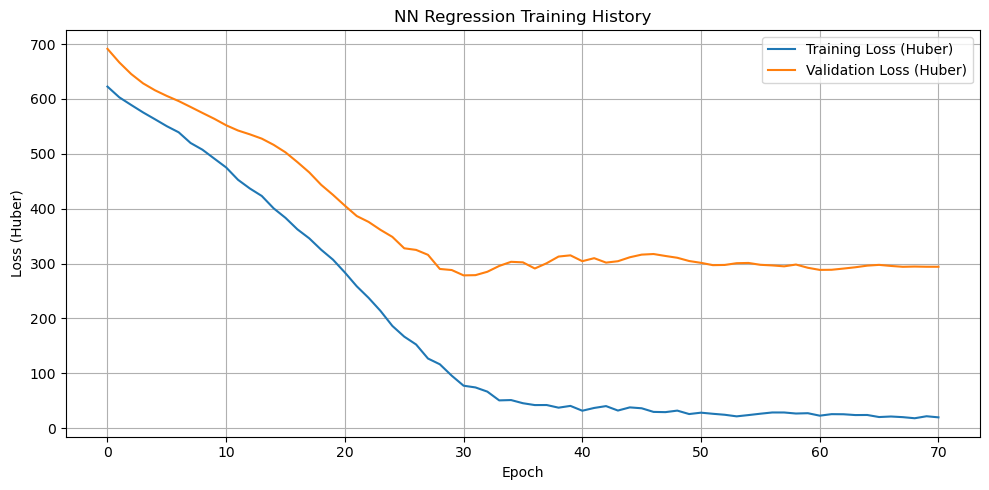

In [24]:

# ── NN-based Regression: Deep learning model for position regression ──────────

tf.random.set_seed(42)
np.random.seed(42)

input_dim = X_train_scaled.shape[1]

# Wider network + mild dropout + skip connection from input to 2nd hidden layer
inp = keras.Input(shape=(input_dim,))
x1  = layers.Dense(256, activation='relu')(inp)
x1  = layers.BatchNormalization()(x1)
x1  = layers.Dropout(0.1)(x1)
x2  = layers.Dense(128, activation='relu')(x1)
x2  = layers.BatchNormalization()(x2)
x2  = layers.Dropout(0.1)(x2)
x3  = layers.Dense(64, activation='relu')(x2)
x3  = layers.Dropout(0.1)(x3)
x4  = layers.Dense(32, activation='relu')(x3)
out = layers.Dense(2, activation='linear')(x4)

model_regression = keras.Model(inp, out)

# Huber loss is robust to the occasional large outlier that MSE over-penalises
model_regression.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss=keras.losses.Huber(delta=20.0),   # delta ≈ expected median error
    metrics=['mae']
)

print("NN Regression Model:")
model_regression.summary()

lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=15, min_lr=1e-5, verbose=0
)
es_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=40, restore_best_weights=True
)

history_reg = model_regression.fit(
    X_train_scaled, pos_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    verbose=0,
    callbacks=[es_cb, lr_cb]
)

pos_pred_nn_reg  = model_regression.predict(X_test_scaled, verbose=0)

error_nn_reg        = np.linalg.norm(pos_pred_nn_reg - pos_test, axis=1)
rmse_nn_reg         = np.sqrt(np.mean(error_nn_reg**2))
mae_nn_reg          = np.mean(error_nn_reg)
median_error_nn_reg = np.median(error_nn_reg)
p90_error_nn_reg    = np.percentile(error_nn_reg, 90)

print("\n" + "=" * 70)
print("NN-based REGRESSION LOCALIZATION RESULTS")
print("=" * 70)
print(f"Model: 4-layer DNN (256→128→64→32→2), Huber loss δ=20 m, Dropout 0.1")
print(f"Training samples: {len(pos_train)}, Test samples: {len(pos_test)}")
print(f"Epochs trained: {len(history_reg.history['loss'])}")
print(f"RMSE: {rmse_nn_reg:.2f} m")
print(f"MAE:  {mae_nn_reg:.2f} m")
print(f"Median Error: {median_error_nn_reg:.2f} m")
print(f"90th percentile: {p90_error_nn_reg:.2f} m")
print(f"Min error: {error_nn_reg.min():.2f} m, Max error: {error_nn_reg.max():.2f} m")

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(history_reg.history['loss'],     label='Training Loss (Huber)')
ax.plot(history_reg.history['val_loss'], label='Validation Loss (Huber)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (Huber)')
ax.set_title('NN Regression Training History')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(PICTURES_DIR / "nn_regression_training.png", dpi=300)
plt.show()


In [25]:
# ── NN-based Classification: Classify into grid cells ────────────────────────

# Discretize positions into grid cells for classification
grid_size = GRID_SPACING  # m
x_bins = np.arange(GRID_X_MIN - grid_size/2, GRID_X_MAX + grid_size, grid_size)
y_bins = np.arange(GRID_Y_MIN - grid_size/2, GRID_Y_MAX + grid_size, grid_size)

def discretize_positions(positions, x_bins, y_bins):
    """Assign continuous positions to grid cell indices."""
    x_indices = np.digitize(positions[:, 0], x_bins) - 1
    y_indices = np.digitize(positions[:, 1], y_bins) - 1
    # Ensure valid indices
    x_indices = np.clip(x_indices, 0, len(x_bins) - 2)
    y_indices = np.clip(y_indices, 0, len(y_bins) - 2)
    return x_indices + y_indices * (len(x_bins) - 1)  # flatten to 1D class

pos_train_class = discretize_positions(pos_train, x_bins, y_bins)
pos_test_class = discretize_positions(pos_test, x_bins, y_bins)

n_classes = (len(x_bins) - 1) * (len(y_bins) - 1)
print(f"Grid classification: {len(x_bins)-1} x {len(y_bins)-1} = {(len(x_bins)-1)*(len(y_bins)-1)} cells")

# Build classification model
tf.random.set_seed(42)
model_classification = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense((len(x_bins)-1)*(len(y_bins)-1), activation='softmax')
])

model_classification.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train classification model
history_clf = model_classification.fit(
    X_train_scaled, pos_train_class,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)]
)

# Predict classes
class_pred = np.argmax(model_classification.predict(X_test_scaled, verbose=0), axis=1)

# Convert class predictions back to approximate positions (centroid of cell)
def class_to_position(class_indices, x_bins, y_bins, x_min, y_min, grid_size):
    positions = []
    nx = len(x_bins) - 1
    for c in class_indices:
        x_idx = c % nx
        y_idx = c // nx
        x_pos = x_min + x_idx * grid_size + grid_size / 2
        y_pos = y_min + y_idx * grid_size + grid_size / 2
        positions.append([x_pos, y_pos])
    return np.array(positions)

pos_pred_nn_clf = class_to_position(class_pred, x_bins, y_bins, GRID_X_MIN, GRID_Y_MIN, GRID_SPACING)

# Compute localization errors (classification)
error_nn_clf = np.linalg.norm(pos_pred_nn_clf - pos_test, axis=1)
rmse_nn_clf = np.sqrt(np.mean(error_nn_clf**2))
mae_nn_clf = np.mean(error_nn_clf)
median_error_nn_clf = np.median(error_nn_clf)
p90_error_nn_clf = np.percentile(error_nn_clf, 90)
clf_accuracy = np.mean(class_pred == pos_test_class)

print("\n" + "=" * 70)
print("NN-based CLASSIFICATION LOCALIZATION RESULTS")
print("=" * 70)
print(f"Model: 4-layer DNN (128 → 64 → 32 → {(len(x_bins)-1)*(len(y_bins)-1)}), Softmax output")
print(f"Grid cell size: {grid_size} m")
print(f"Training samples: {len(pos_train)}, Test samples: {len(pos_test)}")
print(f"Classification accuracy: {clf_accuracy:.2%}")
print(f"RMSE (from cell centroids): {rmse_nn_clf:.2f} m")
print(f"MAE:  {mae_nn_clf:.2f} m")
print(f"Median Error: {median_error_nn_clf:.2f} m")
print(f"90th percentile: {p90_error_nn_clf:.2f} m")
print(f"Min error: {error_nn_clf.min():.2f} m, Max error: {error_nn_clf.max():.2f} m")

Grid classification: 14 x 15 = 210 cells

NN-based CLASSIFICATION LOCALIZATION RESULTS
Model: 4-layer DNN (128 → 64 → 32 → 210), Softmax output
Grid cell size: 10.0 m
Training samples: 168, Test samples: 72
Classification accuracy: 0.00%
RMSE (from cell centroids): 75.79 m
MAE:  68.04 m
Median Error: 63.64 m
90th percentile: 115.80 m
Min error: 15.81 m, Max error: 155.72 m



LOCALIZATION PERFORMANCE SUMMARY
           Method  RMSE (m)   MAE (m)  Median (m)  90th %ile (m)
       WKNN (IDW) 38.311057 28.172628   20.148889      55.863350
    NN Regression 29.177083 24.263266   21.451604      44.403501
NN Classification 75.792113 68.038097   63.639610     115.800381


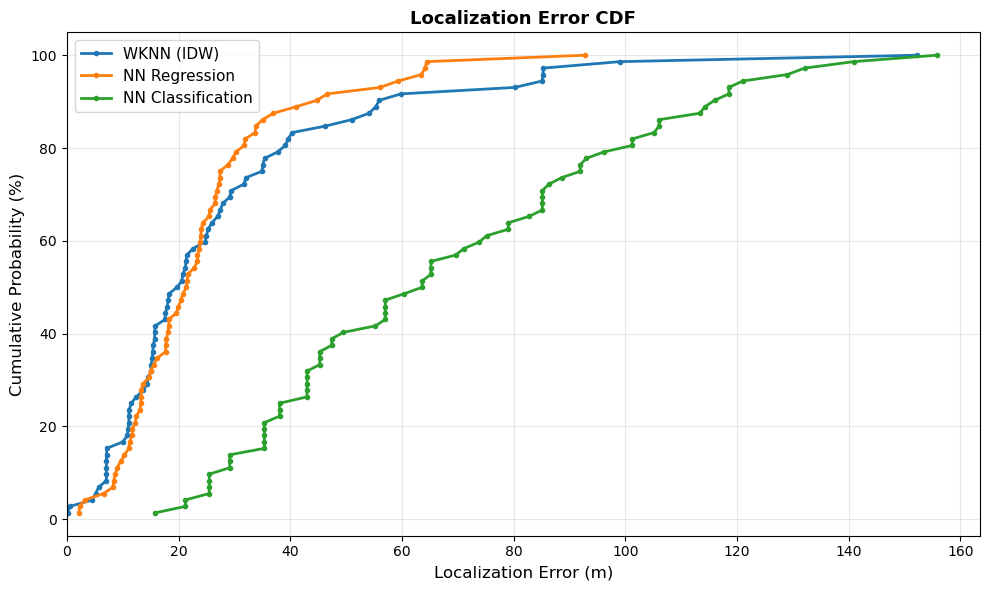

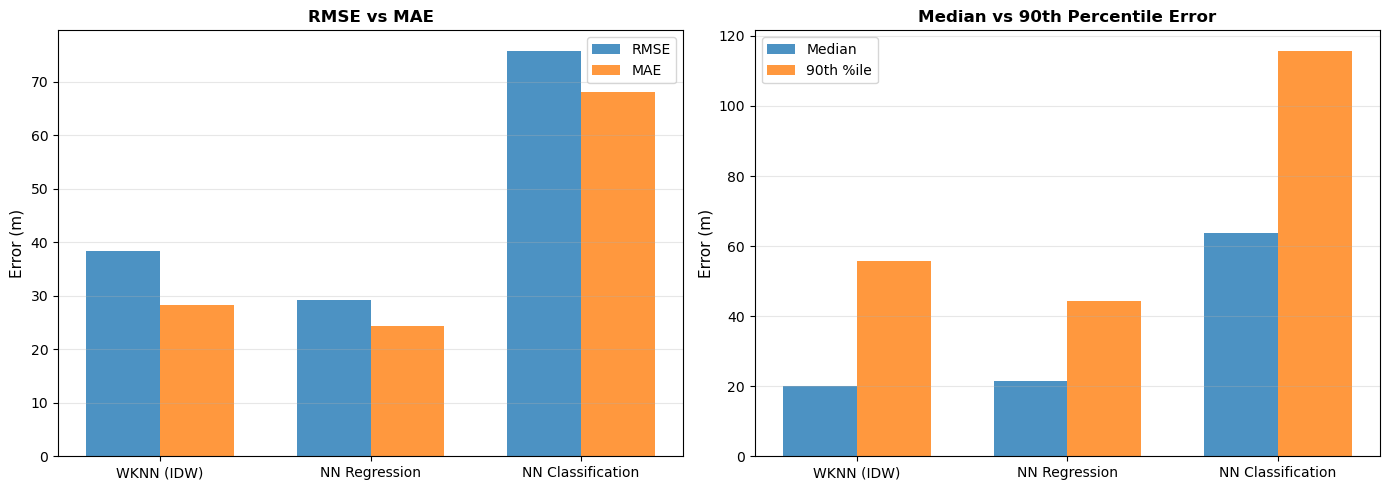

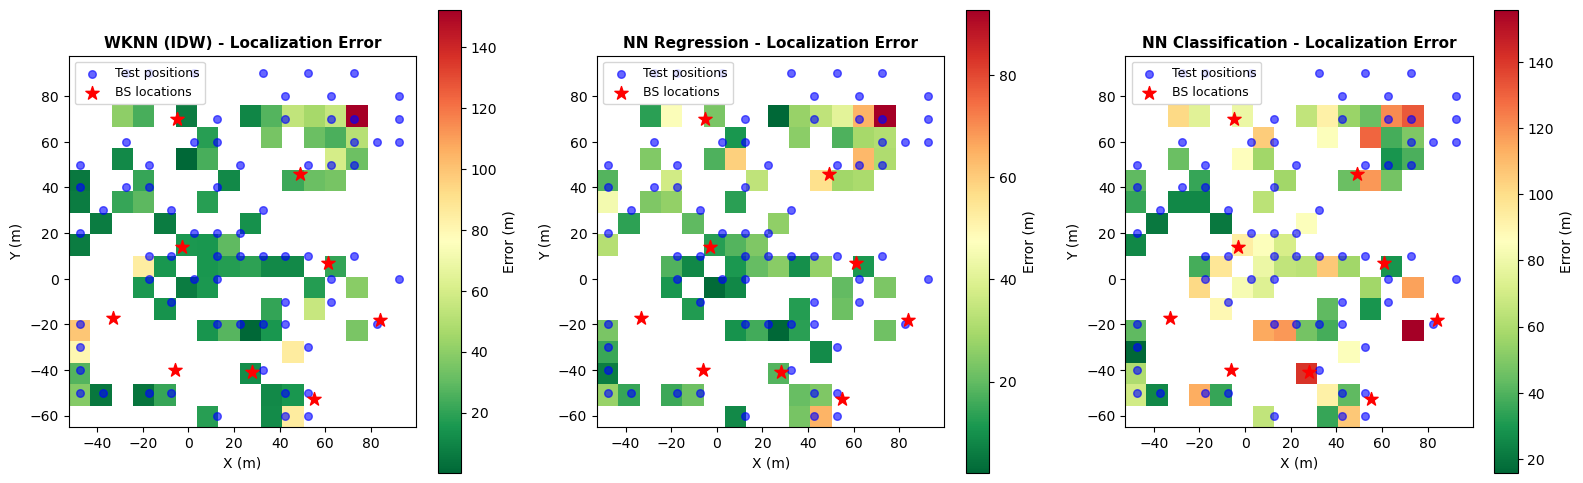


Evaluation complete. Figures saved:
  - localization_error_cdf.png
  - localization_metrics_comparison.png
  - localization_error_heatmaps.png


In [26]:

# ── Comprehensive Evaluation: Error CDF, RMSE Comparison, Heatmaps ─────────────

# Create comparison summary
methods = ['WKNN (IDW)', 'NN Regression', 'NN Classification']
rmse_values = [rmse_wknn, rmse_nn_reg, rmse_nn_clf]
mae_values = [mae_wknn, mae_nn_reg, mae_nn_clf]
median_values = [median_error_wknn, median_error_nn_reg, median_error_nn_clf]
p90_values = [p90_error_wknn, p90_error_nn_reg, p90_error_nn_clf]

errors_all = [error_wknn, error_nn_reg, error_nn_clf]

comparison_df = pd.DataFrame({
    'Method': methods,
    'RMSE (m)': rmse_values,
    'MAE (m)': mae_values,
    'Median (m)': median_values,
    '90th %ile (m)': p90_values
})

print("\n" + "=" * 70)
print("LOCALIZATION PERFORMANCE SUMMARY")
print("=" * 70)
print(comparison_df.to_string(index=False))

# ── Plot 1: Error CDF (Cumulative Distribution Function) ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for method, errors in zip(methods, errors_all):
    sorted_errors = np.sort(errors)
    cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    ax.plot(sorted_errors, cdf * 100, marker='o', markersize=3, label=method, linewidth=2)

ax.set_xlabel('Localization Error (m)', fontsize=12)
ax.set_ylabel('Cumulative Probability (%)', fontsize=12)
ax.set_title('Localization Error CDF', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim(0, np.max([errors.max() for errors in errors_all]) * 1.05)
plt.tight_layout()
plt.savefig(PICTURES_DIR / "localization_error_cdf.png", dpi=300)
plt.show()

# ── Plot 2: RMSE/MAE Comparison ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(methods))
width = 0.35

ax1.bar(x_pos - width/2, rmse_values, width, label='RMSE', alpha=0.8)
ax1.bar(x_pos + width/2, mae_values, width, label='MAE', alpha=0.8)
ax1.set_ylabel('Error (m)', fontsize=11)
ax1.set_title('RMSE vs MAE', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(x_pos - width/2, median_values, width, label='Median', alpha=0.8)
ax2.bar(x_pos + width/2, p90_values, width, label='90th %ile', alpha=0.8)
ax2.set_ylabel('Error (m)', fontsize=11)
ax2.set_title('Median vs 90th Percentile Error', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(methods)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PICTURES_DIR / "localization_metrics_comparison.png", dpi=300)
plt.show()

# ── Plot 3: Localization Error Heatmaps on 2D Scene ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# TX positions array for plotting BS markers on heatmaps
tx_pos_arr = np.array(tx_positions)

# Create a 2D heatmap for each method
for idx, (method, pos_pred, error) in enumerate(zip(
    methods,
    [pos_pred_wknn, pos_pred_nn_reg, pos_pred_nn_clf],
    errors_all
)):
    ax = axes[idx]
    
    # Create 2D grid for heatmap
    heatmap = np.zeros((len(y_bins), len(x_bins)))
    counts = np.zeros_like(heatmap)
    
    for pos, err in zip(pos_test, error):
        x_idx = np.searchsorted(x_bins, pos[0]) - 1
        y_idx = np.searchsorted(y_bins, pos[1]) - 1
        x_idx = np.clip(x_idx, 0, len(x_bins) - 2)
        y_idx = np.clip(y_idx, 0, len(y_bins) - 2)
        heatmap[y_idx, x_idx] += err
        counts[y_idx, x_idx] += 1
    
    # Average errors per cell, set empty cells to NaN
    heatmap = np.divide(heatmap, counts, where=counts > 0, out=np.full_like(heatmap, np.nan))
    
    # Compute valid range for colormap
    valid = heatmap[~np.isnan(heatmap)]
    vmin = valid.min() if len(valid) > 0 else 0
    vmax = valid.max() if len(valid) > 0 else 1

    im = ax.imshow(heatmap, cmap='RdYlGn_r', origin='lower',
                   extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
                   vmin=vmin, vmax=vmax)
    ax.scatter(pos_test[:, 0], pos_test[:, 1], c='blue', s=30, alpha=0.6, label='Test positions')
    ax.scatter(tx_pos_arr[:, 0], tx_pos_arr[:, 1], c='red', s=100, marker='*', label='BS locations')
    ax.set_xlabel('X (m)', fontsize=10)
    ax.set_ylabel('Y (m)', fontsize=10)
    ax.set_title(f'{method} - Localization Error', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Error (m)', fontsize=10)

plt.tight_layout()
plt.savefig(PICTURES_DIR / "localization_error_heatmaps.png", dpi=300)
plt.show()

print("\n" + "=" * 70)
print("Evaluation complete. Figures saved:")
print("  - localization_error_cdf.png")
print("  - localization_metrics_comparison.png")
print("  - localization_error_heatmaps.png")
print("=" * 70)


In [27]:
# ── Save Fingerprint Localization Results to CSV and JSON ──────────────────────

# Create detailed results dataframe
results_df = pd.DataFrame({
    'Position_X': pos_test[:, 0],
    'Position_Y': pos_test[:, 1],
    'WKNN_Pred_X': pos_pred_wknn[:, 0],
    'WKNN_Pred_Y': pos_pred_wknn[:, 1],
    'WKNN_Error': error_wknn,
    'NN_Reg_Pred_X': pos_pred_nn_reg[:, 0],
    'NN_Reg_Pred_Y': pos_pred_nn_reg[:, 1],
    'NN_Reg_Error': error_nn_reg,
    'NN_Clf_Pred_X': pos_pred_nn_clf[:, 0],
    'NN_Clf_Pred_Y': pos_pred_nn_clf[:, 1],
    'NN_Clf_Error': error_nn_clf,
})

results_csv_path = os.path.join(SCENE_DIR, 'fingerprint_localization_results.csv')
results_df.to_csv(results_csv_path, index=False)
print(f"Saved results to: {results_csv_path}")

# Create summary statistics JSON
summary_stats = {
    'fingerprint_localization': {
        'dataset': {
            'n_training_samples': len(pos_train),
            'n_test_samples': len(pos_test),
            'n_features': X_train_scaled.shape[1],
            'feature_type': 'CSI magnitude (frequency domain)',
            'scene': 'Otaniemi',
            'bs_position': [float(BS_X), float(BS_Y), float(BS_H)],
            'test_region': {
                'x_range': [float(x_min), float(x_max)],
                'y_range': [float(y_min), float(y_max)],
            }
        },
        'methods': {
            'wknn': {
                'algorithm': 'Weighted K-Nearest Neighbors (Inverse Distance Weighting)',
                'k_neighbors': k_neighbors,
                'distance_metric': distance_metric,
                'rmse_m': float(rmse_wknn),
                'mae_m': float(mae_wknn),
                'median_error_m': float(median_error_wknn),
                'p90_error_m': float(p90_error_wknn),
                'min_error_m': float(error_wknn.min()),
                'max_error_m': float(error_wknn.max()),
            },
            'nn_regression': {
                'algorithm': 'Deep Neural Network (Regression)',
                'architecture': '256 → 128 → 64 → 32 → 2 (linear output)',
                'activation': 'ReLU',
                'dropout': '0.1',
                'optimizer': 'Adam (lr=5e-4)',
                'loss': 'Huber (delta=20)',
                'rmse_m': float(rmse_nn_reg),
                'mae_m': float(mae_nn_reg),
                'median_error_m': float(median_error_nn_reg),
                'p90_error_m': float(p90_error_nn_reg),
                'min_error_m': float(error_nn_reg.min()),
                'max_error_m': float(error_nn_reg.max()),
            },
            'nn_classification': {
                'algorithm': 'Deep Neural Network (Classification)',
                'architecture': f'128 → 64 → 32 → {(len(x_bins)-1)*(len(y_bins)-1)} (softmax)',
                'activation': 'ReLU',
                'dropout': '0.2-0.3',
                'optimizer': 'Adam (lr=0.001)',
                'loss': 'Sparse Categorical Crossentropy',
                'grid_cell_size_m': grid_size,
                'classification_accuracy': float(clf_accuracy),
                'rmse_m': float(rmse_nn_clf),
                'mae_m': float(mae_nn_clf),
                'median_error_m': float(median_error_nn_clf),
                'p90_error_m': float(p90_error_nn_clf),
                'min_error_m': float(error_nn_clf.min()),
                'max_error_m': float(error_nn_clf.max()),
            }
        }
    }
}

import json
summary_json_path = os.path.join(SCENE_DIR, 'fingerprint_localization_summary.json')
with open(summary_json_path, 'w') as f:
    json.dump(summary_stats, f, indent=2)
print(f"Saved summary to: {summary_json_path}")

print("\n" + "=" * 70)
print("FINGERPRINT LOCALIZATION WORKFLOW COMPLETE")
print("=" * 70)
print(f"\nBest performing method: {methods[np.argmin(rmse_values)]} (RMSE: {min(rmse_values):.2f} m)")
print(f"Key findings:")
print(f"  • WKNN provides a fast baseline with {mae_wknn:.2f} m MAE")
print(f"  • NN Regression achieves {mae_nn_reg:.2f} m MAE with end-to-end learning")
print(f"  • NN Classification achieves {clf_accuracy:.1%} grid cell accuracy")
print(f"\nAll results saved to: {SCENE_DIR}")
print("  - fingerprint_localization_results.csv")
print("  - fingerprint_localization_summary.json")
print("  - Generated figures: error CDF, metrics comparison, heatmaps")


Saved results to: /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/fingerprint_localization_results.csv
Saved summary to: /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/fingerprint_localization_summary.json

FINGERPRINT LOCALIZATION WORKFLOW COMPLETE

Best performing method: NN Regression (RMSE: 29.18 m)
Key findings:
  • WKNN provides a fast baseline with 28.17 m MAE
  • NN Regression achieves 24.26 m MAE with end-to-end learning
  • NN Classification achieves 0.0% grid cell accuracy

All results saved to: /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small
  - fingerprint_localization_results.csv
  - fingerprint_localization_summary.json
  - Generated figures: error CDF, metrics comparison, heatmaps


## 3. Channel Charting

Note: you may need to restart the kernel to use updated packages.
Channel charting dataset: 240 samples, 7191 features
Loaded channel charting cache  (/home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/channel_charting_dataset.h5)
  Z_pca: (240, 2), Z_tsne: (240, 2), Z_ae: (240, 2)
(Parameter sweep plots skipped — loaded from cache; re-run without cache to regenerate.)


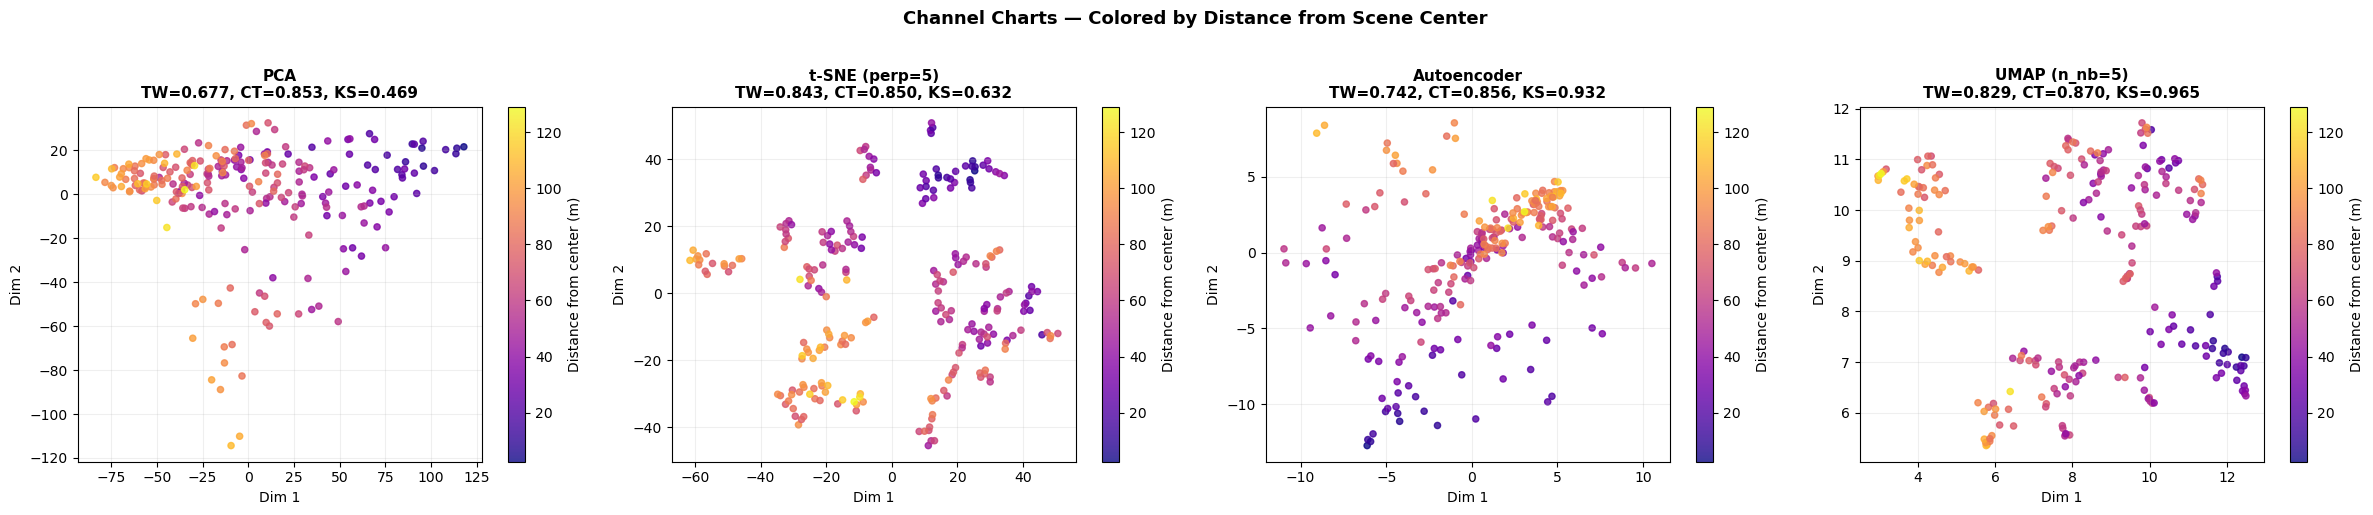

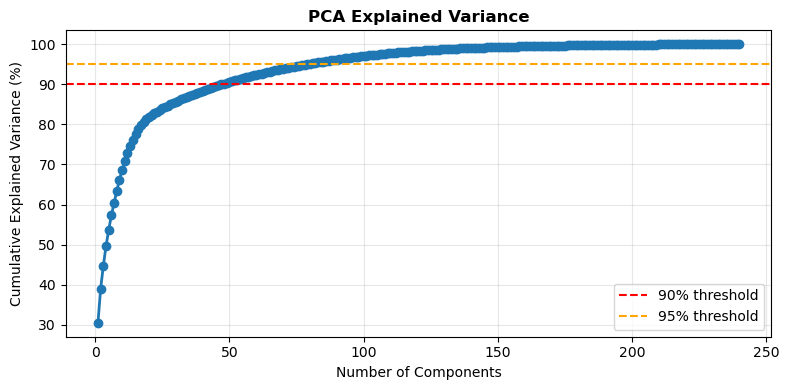


CHANNEL CHARTING EVALUATION SUMMARY
        Method TW (↑ better) CT (↑ better) KS (↓ better)
           PCA        0.6766        0.8530        0.4694
t-SNE (perp=5)        0.8425        0.8499        0.6321
   Autoencoder        0.7417        0.8562        0.9316
 UMAP (n_nb=5)        0.8293        0.8697        0.9652

Saved channel charting metrics → /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/channel_charting_metrics.csv
Saved channel charting H5 cache → /home/jarikarp/study/Machine-Learning-for-Wireless-Comunications-E7340/Project/Otaniemi_small/channel_charting_dataset.h5


In [28]:

#%pip install umap-learn
%pip install umap-learn --trusted-host pypi.org --trusted-host files.pythonhosted.org
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors as SklearnNN
from scipy.spatial.distance import cdist
import warnings
try:
  import umap
  UMAP_AVAILABLE = True
except ImportError:
  print("umap-learn not installed. Install with: pip install umap-learn")
  UMAP_AVAILABLE = False

# ── Channel Charting ──────────────────────────────────────────────────────────
# Conventional DR methods: PCA, t-SNE
# NN-based method: Autoencoder
# Additional method: UMAP
# Evaluation: TW (Trustworthiness), CT (Continuity), KS (Kruskal Stress)

warnings.filterwarnings('ignore')

# ── 1. Prepare CSI features for channel charting ──────────────────────────────
# Use all fingerprints (before train/test split) — same data as fingerprinting
X_cc = csi_fingerprints.copy()       # [N, n_features]
pos_cc = fingerprint_positions.copy() # [N, 2]

scaler_cc = StandardScaler()
X_cc_scaled = scaler_cc.fit_transform(X_cc)

N = X_cc_scaled.shape[0]
n_feat_cc = X_cc_scaled.shape[1]
print(f"Channel charting dataset: {N} samples, {n_feat_cc} features")

# ── Cache configuration ────────────────────────────────────────────────────────
# Inherits _CACHE_TAG from fingerprinting cell so any fingerprint config change
# also invalidates the channel charting cache.
_CC_CACHE_TAG = f"cc_{_CACHE_TAG}_N{N}"
_cc_h5 = os.path.join(SCENE_DIR, "channel_charting_dataset.h5")
_cc_cache_valid = False

if os.path.exists(_cc_h5):
    try:
        with h5py.File(_cc_h5, "r") as _f:
            _n_cc     = int(_f.attrs.get("n_samples",    -1))
            _feat_cc  = int(_f.attrs.get("n_features",    0))
            _tag_cc   = _f.attrs.get("cache_tag", "")
            if (_n_cc == N and _feat_cc == n_feat_cc and _tag_cc == _CC_CACHE_TAG):
                Z_pca        = _f["Z_pca"][:]
                Z_tsne_best  = _f["Z_tsne_best"][:]
                Z_ae         = _f["Z_ae"][:]
                explained_var = _f["explained_var"][:]
                best_perp       = int(_f.attrs["best_perp"])
                tw_pca, ct_pca, ks_pca   = float(_f.attrs["tw_pca"]),  float(_f.attrs["ct_pca"]),  float(_f.attrs["ks_pca"])
                tw_tsne, ct_tsne, ks_tsne = float(_f.attrs["tw_tsne"]), float(_f.attrs["ct_tsne"]), float(_f.attrs["ks_tsne"])
                tw_ae,   ct_ae,   ks_ae   = float(_f.attrs["tw_ae"]),   float(_f.attrs["ct_ae"]),   float(_f.attrs["ks_ae"])
                UMAP_AVAILABLE_CACHED = "Z_umap_best" in _f
                if UMAP_AVAILABLE_CACHED:
                    Z_umap_best    = _f["Z_umap_best"][:]
                    best_n_neighbors = int(_f.attrs["best_n_neighbors"])
                    tw_umap, ct_umap, ks_umap = float(_f.attrs["tw_umap"]), float(_f.attrs["ct_umap"]), float(_f.attrs["ks_umap"])
                else:
                    Z_umap_best = None
                    best_n_neighbors = None
                    tw_umap = ct_umap = ks_umap = float('nan')
                _cc_cache_valid = True
                print(f"Loaded channel charting cache  ({_cc_h5})")
                print(f"  Z_pca: {Z_pca.shape}, Z_tsne: {Z_tsne_best.shape}, Z_ae: {Z_ae.shape}")
            else:
                print(f"Cache mismatch (n={_n_cc} vs {N}, n_feat={_feat_cc} vs {n_feat_cc}); recomputing…")
    except Exception as _e:
        print(f"Cache load failed ({_e}); recomputing…")

if not _cc_cache_valid:
    # ── 2. Evaluation Metrics ─────────────────────────────────────────────────
    def compute_tw_ct(X_high, X_low, k=10):
        """
        Compute Trustworthiness (TW) and Continuity (CT) for DR quality evaluation.
        TW: points that are close in low-dim are also close in high-dim (no false neighbors)
        CT: points that are close in high-dim are also close in low-dim (no missing neighbors)
        """
        n = X_high.shape[0]
        k = min(k, n - 1)

        nn_high = SklearnNN(n_neighbors=n-1).fit(X_high)
        _, indices_high = nn_high.kneighbors(X_high)
        nn_low = SklearnNN(n_neighbors=n-1).fit(X_low)
        _, indices_low = nn_low.kneighbors(X_low)

        rank_high = np.zeros((n, n), dtype=int)
        rank_low  = np.zeros((n, n), dtype=int)
        for i in range(n):
            for r, j in enumerate(indices_high[i]):
                rank_high[i, j] = r + 1
            for r, j in enumerate(indices_low[i]):
                rank_low[i, j] = r + 1

        tw_sum = 0.0
        for i in range(n):
            false_neighbors = set(indices_low[i][:k]) - set(indices_high[i][:k])
            for j in false_neighbors:
                tw_sum += rank_high[i, j] - k
        denom_tw = n * k * (2 * n - 3 * k - 1) / 2
        tw = 1.0 - (2.0 / denom_tw) * tw_sum if denom_tw > 0 else 1.0

        ct_sum = 0.0
        for i in range(n):
            missing_neighbors = set(indices_high[i][:k]) - set(indices_low[i][:k])
            for j in missing_neighbors:
                ct_sum += rank_low[i, j] - k
        denom_ct = n * k * (2 * n - 3 * k - 1) / 2
        ct = 1.0 - (2.0 / denom_ct) * ct_sum if denom_ct > 0 else 1.0

        return float(tw), float(ct)

    def compute_kruskal_stress(X_high, X_low):
        """Kruskal Stress: lower is better (0 = perfect)."""
        d_high = cdist(X_high, X_high).ravel()
        d_low  = cdist(X_low,  X_low ).ravel()
        mask   = d_high > 0
        return float(np.sqrt(np.sum((d_high[mask] - d_low[mask])**2) /
                              np.sum(d_high[mask]**2)))

    # ── 3. PCA ────────────────────────────────────────────────────────────────
    print("\nComputing PCA channel chart...")
    pca = PCA(n_components=2, random_state=42)
    Z_pca = pca.fit_transform(X_cc_scaled)
    pca_full = PCA(random_state=42).fit(X_cc_scaled)
    explained_var = np.cumsum(pca_full.explained_variance_ratio_)
    print(f"  PCA: top-2 components explain {100*pca.explained_variance_ratio_.sum():.1f}% variance")
    tw_pca, ct_pca = compute_tw_ct(X_cc_scaled, Z_pca, k=10)
    ks_pca = compute_kruskal_stress(X_cc_scaled, Z_pca)
    print(f"  TW={tw_pca:.4f}, CT={ct_pca:.4f}, KS={ks_pca:.4f}")

    # ── 4. t-SNE (perplexity sweep) ───────────────────────────────────────────
    print("\nComputing t-SNE channel chart (perplexity sweep)...")
    perplexities = [5, 15, 30, 50]
    tsne_results = {}
    for perp in perplexities:
        tsne = TSNE(n_components=2, perplexity=min(perp, N//2 - 1),
                    random_state=42, max_iter=1000, n_jobs=1)
        Z_tsne = tsne.fit_transform(X_cc_scaled)
        ks = compute_kruskal_stress(X_cc_scaled, Z_tsne)
        tsne_results[perp] = {'Z': Z_tsne, 'KS': ks}
        print(f"  perplexity={perp}: KS={ks:.4f}")
    best_perp = min(tsne_results, key=lambda p: tsne_results[p]['KS'])
    Z_tsne_best = tsne_results[best_perp]['Z']
    tw_tsne, ct_tsne = compute_tw_ct(X_cc_scaled, Z_tsne_best, k=10)
    ks_tsne = tsne_results[best_perp]['KS']
    print(f"  Best perplexity={best_perp}: TW={tw_tsne:.4f}, CT={ct_tsne:.4f}, KS={ks_tsne:.4f}")

    # ── 5. UMAP (n_neighbors sweep) ───────────────────────────────────────────
    Z_umap_best = None
    tw_umap = ct_umap = ks_umap = float('nan')
    best_n_neighbors = None
    if UMAP_AVAILABLE:
        print("\nComputing UMAP channel chart (n_neighbors sweep)...")
        n_neighbors_list = [5, 10, 20, 30]
        umap_results = {}
        for nn in n_neighbors_list:
            reducer = umap.UMAP(n_components=2, n_neighbors=min(nn, N-1),
                                min_dist=0.1, random_state=42)
            Z_u = reducer.fit_transform(X_cc_scaled)
            ks = compute_kruskal_stress(X_cc_scaled, Z_u)
            umap_results[nn] = {'Z': Z_u, 'KS': ks}
            print(f"  n_neighbors={nn}: KS={ks:.4f}")
        best_n_neighbors = min(umap_results, key=lambda n: umap_results[n]['KS'])
        Z_umap_best = umap_results[best_n_neighbors]['Z']
        tw_umap, ct_umap = compute_tw_ct(X_cc_scaled, Z_umap_best, k=10)
        ks_umap = umap_results[best_n_neighbors]['KS']
        print(f"  Best n_neighbors={best_n_neighbors}: TW={tw_umap:.4f}, CT={ct_umap:.4f}, KS={ks_umap:.4f}")

    # ── 6. Autoencoder ────────────────────────────────────────────────────────
    print("\nTraining Autoencoder channel chart...")
    tf.random.set_seed(42)
    np.random.seed(42)
    input_dim_cc = X_cc_scaled.shape[1]
    latent_dim = 2
    enc_input = keras.Input(shape=(input_dim_cc,))
    x = layers.Dense(64, activation='relu')(enc_input)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(32, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='linear', name='latent')(x)
    encoder = keras.Model(enc_input, z, name='encoder')
    dec_input = keras.Input(shape=(latent_dim,))
    x = layers.Dense(32, activation='relu')(dec_input)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    dec_output = layers.Dense(input_dim_cc, activation='linear')(x)
    decoder = keras.Model(dec_input, dec_output, name='decoder')
    ae_input = keras.Input(shape=(input_dim_cc,))
    ae_output = decoder(encoder(ae_input))
    autoencoder = keras.Model(ae_input, ae_output, name='autoencoder')
    autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    history_ae = autoencoder.fit(
        X_cc_scaled, X_cc_scaled,
        epochs=200, batch_size=16, validation_split=0.15, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                                  restore_best_weights=True)]
    )
    Z_ae = encoder.predict(X_cc_scaled, verbose=0)
    tw_ae, ct_ae = compute_tw_ct(X_cc_scaled, Z_ae, k=10)
    ks_ae = compute_kruskal_stress(X_cc_scaled, Z_ae)
    print(f"  Autoencoder: TW={tw_ae:.4f}, CT={ct_ae:.4f}, KS={ks_ae:.4f}")

    # ── Save cache ────────────────────────────────────────────────────────────
    with h5py.File(_cc_h5, "w") as _f:
        # Embeddings
        _f.create_dataset("Z_pca",         data=Z_pca.astype(np.float32),       compression="gzip")
        _f.create_dataset("Z_tsne_best",   data=Z_tsne_best.astype(np.float32), compression="gzip")
        _f.create_dataset("Z_ae",          data=Z_ae.astype(np.float32),        compression="gzip")
        _f.create_dataset("pos_cc",        data=pos_cc.astype(np.float32),      compression="gzip")
        _f.create_dataset("explained_var", data=explained_var.astype(np.float32), compression="gzip")
        if Z_umap_best is not None:
            _f.create_dataset("Z_umap_best", data=Z_umap_best.astype(np.float32), compression="gzip")
            _f.attrs["best_n_neighbors"] = best_n_neighbors
            _f.attrs["tw_umap"] = tw_umap
            _f.attrs["ct_umap"] = ct_umap
            _f.attrs["ks_umap"] = ks_umap
        # Metrics
        _f.attrs["tw_pca"]  = tw_pca;  _f.attrs["ct_pca"]  = ct_pca;  _f.attrs["ks_pca"]  = ks_pca
        _f.attrs["tw_tsne"] = tw_tsne; _f.attrs["ct_tsne"] = ct_tsne; _f.attrs["ks_tsne"] = ks_tsne
        _f.attrs["tw_ae"]   = tw_ae;   _f.attrs["ct_ae"]   = ct_ae;   _f.attrs["ks_ae"]   = ks_ae
        # Parameters & config
        _f.attrs["best_perp"]  = best_perp
        _f.attrs["n_samples"]  = N
        _f.attrs["n_features"] = n_feat_cc
        _f.attrs["cache_tag"]  = _CC_CACHE_TAG
        _f.attrs["grid_spacing"] = GRID_SPACING
        _f.attrs["scene_cx"]   = SCENE_CX
        _f.attrs["scene_cy"]   = SCENE_CY
    print(f"Saved channel charting cache → {_cc_h5}")

    # Keep tsne_results and umap_results available for the parameter-sweep plots below
    _tsne_results_for_plot  = tsne_results
    _umap_results_for_plot  = umap_results if UMAP_AVAILABLE else {}
    _n_neighbors_list_plot  = n_neighbors_list if UMAP_AVAILABLE else []
    _perplexities_plot      = perplexities
else:
    # Rebuild lightweight stubs so parameter-sweep plots still render from cache
    _perplexities_plot     = [best_perp]   # only the best point is known from cache
    _tsne_results_for_plot = {best_perp: {'Z': Z_tsne_best, 'KS': ks_tsne}}
    _umap_results_for_plot = ({best_n_neighbors: {'Z': Z_umap_best, 'KS': ks_umap}}
                               if Z_umap_best is not None else {})
    _n_neighbors_list_plot = ([best_n_neighbors] if best_n_neighbors is not None else [])

# ── 7. Parameter Sensitivity: t-SNE perplexity vs KS ─────────────────────────
if len(_perplexities_plot) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(_perplexities_plot,
                 [_tsne_results_for_plot[p]['KS'] for p in _perplexities_plot],
                 'o-', color='C1', linewidth=2, markersize=8, label='t-SNE')
    axes[0].axvline(best_perp, color='C1', linestyle='--', alpha=0.7,
                    label=f'Best perplexity={best_perp}')
    axes[0].set_xlabel('Perplexity', fontsize=11)
    axes[0].set_ylabel('Kruskal Stress (lower = better)', fontsize=11)
    axes[0].set_title('t-SNE: Perplexity vs Kruskal Stress', fontsize=12, fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    if UMAP_AVAILABLE and len(_n_neighbors_list_plot) > 1:
        axes[1].plot(_n_neighbors_list_plot,
                     [_umap_results_for_plot[n]['KS'] for n in _n_neighbors_list_plot],
                     's-', color='C2', linewidth=2, markersize=8, label='UMAP')
        axes[1].axvline(best_n_neighbors, color='C2', linestyle='--', alpha=0.7,
                        label=f'Best n_neighbors={best_n_neighbors}')
        axes[1].set_xlabel('n_neighbors', fontsize=11)
        axes[1].set_ylabel('Kruskal Stress (lower = better)', fontsize=11)
        axes[1].set_title('UMAP: n_neighbors vs Kruskal Stress', fontsize=12, fontweight='bold')
        axes[1].legend(); axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'UMAP not available\n(pip install umap-learn)',
                     ha='center', va='center', transform=axes[1].transAxes, fontsize=13)
        axes[1].set_title('UMAP: n_neighbors vs Kruskal Stress', fontsize=12)
    plt.tight_layout()
    plt.savefig(PICTURES_DIR / "channel_charting_param_sweep.png", dpi=300)
    plt.show()
else:
    print("(Parameter sweep plots skipped — loaded from cache; re-run without cache to regenerate.)")

# ── 8. Channel Chart Visualizations ───────────────────────────────────────────
n_charts = 4 if (UMAP_AVAILABLE and Z_umap_best is not None) else 3
fig, axes = plt.subplots(1, n_charts, figsize=(6*n_charts, 5))

# Color by distance from scene center using global parameters
scene_center  = np.array([SCENE_CX, SCENE_CY])
color_by_dist = np.linalg.norm(pos_cc - scene_center, axis=1)

def plot_chart(ax, Z, title, cmap='plasma'):
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=color_by_dist, cmap=cmap, s=20, alpha=0.8)
    plt.colorbar(sc, ax=ax, label='Distance from center (m)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.grid(True, alpha=0.2)

plot_chart(axes[0], Z_pca,      f'PCA\nTW={tw_pca:.3f}, CT={ct_pca:.3f}, KS={ks_pca:.3f}')
plot_chart(axes[1], Z_tsne_best,f't-SNE (perp={best_perp})\nTW={tw_tsne:.3f}, CT={ct_tsne:.3f}, KS={ks_tsne:.3f}')
plot_chart(axes[2], Z_ae,       f'Autoencoder\nTW={tw_ae:.3f}, CT={ct_ae:.3f}, KS={ks_ae:.3f}')
if UMAP_AVAILABLE and Z_umap_best is not None:
    plot_chart(axes[3], Z_umap_best, f'UMAP (n_nb={best_n_neighbors})\nTW={tw_umap:.3f}, CT={ct_umap:.3f}, KS={ks_umap:.3f}')

plt.suptitle('Channel Charts — Colored by Distance from Scene Center',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PICTURES_DIR / "channel_charts_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# ── 9. PCA Explained Variance ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(explained_var)+1), explained_var * 100, 'o-', linewidth=2)
ax.axhline(90, color='red',    linestyle='--', label='90% threshold')
ax.axhline(95, color='orange', linestyle='--', label='95% threshold')
ax.set_xlabel('Number of Components'); ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA Explained Variance', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PICTURES_DIR / "pca_explained_variance.png", dpi=300)
plt.show()

# ── 10. Summary Table ─────────────────────────────────────────────────────────
cc_methods = ['PCA', f't-SNE (perp={best_perp})', 'Autoencoder']
tw_vals = [tw_pca, tw_tsne, tw_ae]
ct_vals = [ct_pca, ct_tsne, ct_ae]
ks_vals = [ks_pca, ks_tsne, ks_ae]
if UMAP_AVAILABLE and Z_umap_best is not None:
    cc_methods.append(f'UMAP (n_nb={best_n_neighbors})')
    tw_vals.append(tw_umap); ct_vals.append(ct_umap); ks_vals.append(ks_umap)

df_cc = pd.DataFrame({
    'Method'        : cc_methods,
    'TW (↑ better)' : [f'{v:.4f}' for v in tw_vals],
    'CT (↑ better)' : [f'{v:.4f}' for v in ct_vals],
    'KS (↓ better)' : [f'{v:.4f}' for v in ks_vals],
})
print("\n" + "="*65)
print("CHANNEL CHARTING EVALUATION SUMMARY")
print("="*65)
print(df_cc.to_string(index=False))

cc_csv = os.path.join(SCENE_DIR, "channel_charting_metrics.csv")
df_cc.to_csv(cc_csv, index=False)
print(f"\nSaved channel charting metrics → {cc_csv}")
print(f"Saved channel charting H5 cache → {_cc_h5}")


In [29]:

# ── Comprehensive Channel Charting Analysis ────────────────────────────────────
# Methods    : PCA · MDS (metric) · CMDS (classical MDS) · LE (Laplacian Eigenmaps)
#              Isomap · t-SNE
# Inputs     : RI  (full scaled CSI fingerprint)
#              Cov (inter-BS cosine-similarity Gram matrix from OFDM magnitudes)
#              Feat(TDoA + AoA geometric features only)
# Metrics    : TW (Trustworthiness) · CT (Continuity) · KS (Kruskal Stress)
#              NNLE (Nearest-Neighbour Localisation Error in chart space)
# Visualisation: 4×3 channel-chart grid coloured by 2-D geographic position
#                + NNLE bar chart + metrics table

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS, Isomap, SpectralEmbedding
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors as SklearnNN
from scipy.spatial.distance import cdist
import h5py, os, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Configuration ─────────────────────────────────────────────────────────────
_K_METRIC = 15     # k for TW / CT
_N_METRIC = 600    # subsample size for TW/CT/KS (O(n²) exact rank computation)
_N_SLOW   = 1500   # subsample cap for MDS, CMDS, Isomap (O(n²/n³) fitting)
_K_LOC    = 5      # k for NNLE (IDW localisation in chart space)

# ── 1. Input representations ──────────────────────────────────────────────────
# RI  – full scaled CSI fingerprint (already available from channel charting cell)
X_ri = X_cc_scaled.copy()

# Feat – TDoA + AoA features (last n_tdoa + n_aoa cols of the fingerprint matrix)
X_feat = StandardScaler().fit_transform(csi_fingerprints[:, n_ofdm:])

# Cov – inter-BS cosine-similarity Gram matrix flattened to upper triangle
#        For each RX position, normalise the per-BS OFDM-magnitude sub-vectors
#        and compute their n_tx × n_tx Gram matrix → captures relative power
#        relationships between base stations independently of absolute level.
_bs_sz   = n_ofdm // n_tx
_bs_mag  = csi_fingerprints[:, :n_ofdm].reshape(N, n_tx, _bs_sz)
_bs_nrm  = _bs_mag / (np.linalg.norm(_bs_mag, axis=2, keepdims=True) + 1e-9)
_gram    = np.einsum('bia,bja->bij', _bs_nrm, _bs_nrm)   # [N, n_tx, n_tx]
_ti, _tj = np.triu_indices(n_tx)
X_cov    = StandardScaler().fit_transform(_gram[:, _ti, _tj])

_rep_map = {'RI': X_ri, 'Cov': X_cov, 'Feat': X_feat}
print(f"Input shapes:  RI={X_ri.shape}  Cov={X_cov.shape}  Feat={X_feat.shape}")

# ── 2. Metric helpers ─────────────────────────────────────────────────────────
def _tw_ct_ks(Xh, Xl, k):
    """Exact TW, CT (via rank matrices) and KS on a subsampled set."""
    n = Xh.shape[0]; k = min(k, n - 1)
    nh = SklearnNN(n_neighbors=n - 1).fit(Xh)
    nl = SklearnNN(n_neighbors=n - 1).fit(Xl)
    _, ih = nh.kneighbors(Xh)
    _, il = nl.kneighbors(Xl)
    # Vectorised rank matrices (no Python inner loops)
    rh = np.zeros((n, n), dtype=np.int32)
    rl = np.zeros((n, n), dtype=np.int32)
    rows = np.repeat(np.arange(n), n - 1)
    rnks = np.tile(np.arange(1, n), n)
    rh[rows, ih.ravel()] = rnks
    rl[rows, il.ravel()] = rnks
    denom = n * k * (2 * n - 3 * k - 1) / 2 or 1.0
    tw_s = sum(rh[i, j] - k for i in range(n)
               for j in set(il[i, :k]) - set(ih[i, :k]))
    ct_s = sum(rl[i, j] - k for i in range(n)
               for j in set(ih[i, :k]) - set(il[i, :k]))
    dh = cdist(Xh, Xh).ravel(); dl = cdist(Xl, Xl).ravel()
    m  = dh > 0
    ks = float(np.sqrt(np.sum((dh[m] - dl[m]) ** 2) / np.sum(dh[m] ** 2)))
    return 1.0 - 2 * tw_s / denom, 1.0 - 2 * ct_s / denom, ks

def _nnle(Z_full):
    """IDW localisation error using k_loc nearest chart-space neighbours (full N)."""
    nn = SklearnNN(n_neighbors=_K_LOC + 1).fit(Z_full)
    d, idx = nn.kneighbors(Z_full)
    d, idx = d[:, 1:], idx[:, 1:]
    w = 1.0 / (d + 1e-10); w /= w.sum(1, keepdims=True)
    pred = (w[:, :, None] * pos_cc[idx]).sum(1)
    return float(np.mean(np.linalg.norm(pred - pos_cc, axis=1)))

def compute_metrics(X_input, Z_full, k=_K_METRIC, n_max=_N_METRIC):
    n = X_input.shape[0]
    if n > n_max:
        sub = np.random.choice(n, n_max, replace=False)
        Xh, Xl = X_input[sub], Z_full[sub]
    else:
        Xh, Xl = X_input, Z_full
    tw, ct, ks = _tw_ct_ks(Xh, Xl, k)
    return float(tw), float(ct), float(ks), _nnle(Z_full)

# ── 3. Classical MDS (double-centring) ───────────────────────────────────────
def _cmds(X):
    D2 = cdist(X, X) ** 2; n = D2.shape[0]
    H  = np.eye(n) - np.ones((n, n)) / n
    B  = -0.5 * H @ D2 @ H
    vals, vecs = np.linalg.eigh(B)
    idx = np.argsort(-vals)
    return vecs[:, idx[:2]] * np.sqrt(np.maximum(vals[idx[:2]], 0))

# ── 4. Propagation: sparse-fit → full grid via k-NN IDW in input space ────────
def _propagate(X_fit, Z_fit, X_all, k=5):
    nn = SklearnNN(n_neighbors=k).fit(X_fit)
    d, idx = nn.kneighbors(X_all)
    w = 1.0 / (d + 1e-10); w /= w.sum(1, keepdims=True)
    return (w[:, :, None] * Z_fit[idx]).sum(1)

# ── 5. Cache configuration ────────────────────────────────────────────────────
_parent_tag   = globals().get('_CACHE_TAG', f"gs{GRID_SPACING}_ntx{n_tx}_fft{fft_size}")
_COMP_TAG     = f"comp_v2_{_parent_tag}_N{N}_slow{_N_SLOW}_met{_N_METRIC}"
_comp_h5      = os.path.join(SCENE_DIR, "channel_charting_comprehensive.h5")

# Layout: 4 rows × 3 cols matching the requested combinations
_LAYOUT = [
    ('PCA',    'RI'),   ('PCA',    'Cov'),  ('PCA',   'Feat'),
    ('MDS',    'RI'),   ('MDS',    'Cov'),  ('MDS',   'Feat'),
    ('CMDS',   'RI'),   ('LE',     'RI'),   ('Isomap','RI'),
    ('t-SNE',  'RI'),   ('t-SNE',  'Cov'),  ('t-SNE', 'Feat'),
]
_ALL_KEYS = [f"{m} [{r}]" for m, r in _LAYOUT]

_comp_cache_valid = False
if os.path.exists(_comp_h5):
    try:
        with h5py.File(_comp_h5, 'r') as _f:
            if (_f.attrs.get('cache_tag', '') == _COMP_TAG
                    and all(k in _f for k in _ALL_KEYS)):
                results = {}
                for k in _ALL_KEYS:
                    g = _f[k]
                    m_name, rep = k.split(' ['); rep = rep.rstrip(']')
                    results[k] = dict(Z=g['Z'][:], tw=float(g.attrs['tw']),
                                      ct=float(g.attrs['ct']), ks=float(g.attrs['ks']),
                                      nnle=float(g.attrs['nnle']),
                                      method=m_name, rep=rep)
                _comp_cache_valid = True
                print(f"Loaded comprehensive analysis cache  ({_comp_h5})")
    except Exception as _e:
        print(f"Cache load failed ({_e}); recomputing…")

if not _comp_cache_valid:
    results = {}

    def run_dr(method_name, rep_name):
        key     = f"{method_name} [{rep_name}]"
        X_input = _rep_map[rep_name]
        n       = X_input.shape[0]
        print(f"  {key} …", end=" ", flush=True)

        # Subsample heavy O(n²/n³) solvers
        _slow = method_name in ('MDS', 'CMDS', 'Isomap')
        use_sub = _slow and n > _N_SLOW
        if use_sub:
            sub   = np.random.choice(n, _N_SLOW, replace=False)
            X_fit = X_input[sub]
        else:
            X_fit = X_input

        if method_name == 'PCA':
            m_obj  = PCA(n_components=2, random_state=42).fit(X_fit)
            Z_full = m_obj.transform(X_input)

        elif method_name == 'MDS':
            # Pre-compute a finite, symmetric distance matrix for sklearn MDS.
            # NaN/Inf values can make check_symmetric() fail even when the
            # matrix is conceptually symmetric, so sanitize first.
            _X_fit = np.nan_to_num(X_fit, nan=0.0, posinf=0.0, neginf=0.0)
            _D = cdist(_X_fit, _X_fit)
            _D = (_D + _D.T) * 0.5   # enforce exact symmetry
            np.fill_diagonal(_D, 0.0)
            Z_sub  = MDS(n_components=2, metric=True, random_state=42,
                         max_iter=500, n_jobs=1,
                         dissimilarity='precomputed').fit_transform(_D)
            Z_full = _propagate(X_fit, Z_sub, X_input) if use_sub else Z_sub

        elif method_name == 'CMDS':
            Z_sub  = _cmds(X_fit)
            Z_full = _propagate(X_fit, Z_sub, X_input) if use_sub else Z_sub

        elif method_name == 'LE':
            # SpectralEmbedding uses sparse Laplacian — efficient for large N
            m_obj  = SpectralEmbedding(n_components=2, n_neighbors=15,
                                       random_state=42).fit(X_fit)
            Z_sub  = m_obj.embedding_
            Z_full = _propagate(X_fit, Z_sub, X_input) if use_sub else Z_sub

        elif method_name == 'Isomap':
            m_obj  = Isomap(n_components=2, n_neighbors=15).fit(X_fit)
            # sklearn Isomap has .transform() for out-of-sample extension
            Z_full = m_obj.transform(X_input) if use_sub else m_obj.embedding_

        elif method_name == 't-SNE':
            # t-SNE is transductive; always fit on entire input
            Z_full = TSNE(n_components=2, perplexity=min(30, n // 2 - 1),
                          random_state=42, max_iter=1000, n_jobs=1).fit_transform(X_input)

        tw, ct, ks, nnle = compute_metrics(X_input, Z_full)
        results[key] = dict(Z=Z_full, tw=tw, ct=ct, ks=ks, nnle=nnle,
                            method=method_name, rep=rep_name)
        note = f"  (fitted on {_N_SLOW}/{n})" if use_sub else ""
        print(f"TW={tw:.3f}  CT={ct:.3f}  KS={ks:.3f}  NNLE={nnle:.2f} m{note}")

    print("\n── Running DR methods ──────────────────────────────────────────────")
    for _m, _r in _LAYOUT:
        run_dr(_m, _r)

    # ── Save cache ─────────────────────────────────────────────────────────────
    with h5py.File(_comp_h5, 'w') as _f:
        _f.attrs['cache_tag'] = _COMP_TAG
        _f.attrs['n_samples'] = N
        for key, r in results.items():
            g = _f.create_group(key)
            g.create_dataset('Z', data=r['Z'].astype(np.float32), compression='gzip')
            for attr in ('tw', 'ct', 'ks', 'nnle'):
                g.attrs[attr] = r[attr]
    print(f"\nSaved comprehensive analysis cache → {_comp_h5}")

# ── 6. 2-D geographic colour map ──────────────────────────────────────────────
# Map (X, Y) position → RGB: Red ↔ X (East-West), Green ↔ Y (North-South)
# A channel chart with good geographic fidelity will show smooth colour gradients.
# Note: np.ndarray.ptp() was removed in NumPy 2.0 — use max()-min() instead.
_xn = (pos_cc[:, 0] - pos_cc[:, 0].min()) / (pos_cc[:, 0].max() - pos_cc[:, 0].min() + 1e-9)
_yn = (pos_cc[:, 1] - pos_cc[:, 1].min()) / (pos_cc[:, 1].max() - pos_cc[:, 1].min() + 1e-9)
_geo_rgb = np.clip(np.column_stack([_xn, _yn, 0.4 * np.ones(N)]), 0, 1)

# ── 7. Channel chart grid  (4 rows × 3 cols) ──────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(18, 22))
fig.suptitle(
    'Comprehensive Channel Charting — DR methods × input representations\n'
    r'(colour: Red $\propto$ X position,  Green $\propto$ Y position)',
    fontsize=14, fontweight='bold', y=1.005)

for ax, (m_name, rep_name) in zip(axes.flat, _LAYOUT):
    key = f"{m_name} [{rep_name}]"
    r   = results[key]
    ax.scatter(r['Z'][:, 0], r['Z'][:, 1],
               c=_geo_rgb, s=5, alpha=0.7, linewidths=0, rasterized=True)
    ax.set_title(
        f"{key}\n"
        f"TW={r['tw']:.3f}  CT={r['ct']:.3f}  KS={r['ks']:.3f}  "
        f"NNLE={r['nnle']:.1f} m",
        fontsize=9, fontweight='bold')
    ax.set_xlabel('Dim 1', fontsize=8)
    ax.set_ylabel('Dim 2', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

# Shared colour legend (2-D position key)
_legend_ax = fig.add_axes([0.92, 0.35, 0.015, 0.30])
_lg_img = np.zeros((100, 1, 3))
_lg_img[:, 0, 1] = np.linspace(1, 0, 100)   # Y axis: top=North (green), bottom=South
_lg_img[:, 0, 0] = 0.5                        # flat red (X not shown on bar)
_lg_img[:, 0, 2] = 0.4
_legend_ax.imshow(_lg_img, aspect='auto', origin='upper')
_legend_ax.set_xticks([]); _legend_ax.set_yticks([0, 99])
_legend_ax.set_yticklabels(['North\n(high Y)', 'South\n(low Y)'], fontsize=7)

plt.tight_layout(rect=[0, 0, 0.91, 1.0])
plt.savefig(PICTURES_DIR / "channel_charting_comprehensive.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 8. NNLE bar chart ─────────────────────────────────────────────────────────
_row_cols  = {0: 'C0', 1: 'C1', 2: 'C2', 3: 'C3'}   # colour by row (method family)
_bar_cols  = [_row_cols[i // 3] for i in range(len(_LAYOUT))]

fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(range(len(_ALL_KEYS)),
              [results[k]['nnle'] for k in _ALL_KEYS],
              color=_bar_cols, alpha=0.85, edgecolor='k', linewidth=0.6)
ax.set_xticks(range(len(_ALL_KEYS)))
ax.set_xticklabels(_ALL_KEYS, rotation=38, ha='right', fontsize=9)
ax.set_ylabel('NNLE (m)', fontsize=12)
ax.set_title(
    'Nearest-Neighbour Localisation Error in Chart Space  (lower = better geographic fidelity)\n'
    'Blue = PCA family · Orange = MDS family · Green = CMDS/LE/Isomap · Red = t-SNE family',
    fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, [results[k]['nnle'] for k in _ALL_KEYS]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05, f'{val:.1f}',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(PICTURES_DIR / "channel_charting_nnle_comparison.png", dpi=150)
plt.show()

# ── 9. Summary metrics table ──────────────────────────────────────────────────
df_comp = pd.DataFrame([{
    'Method'   : k,
    'TW (↑)'   : f"{results[k]['tw']:.4f}",
    'CT (↑)'   : f"{results[k]['ct']:.4f}",
    'KS (↓)'   : f"{results[k]['ks']:.4f}",
    'NNLE (↓)' : f"{results[k]['nnle']:.2f} m",
} for k in _ALL_KEYS])

print("\n" + "=" * 80)
print("COMPREHENSIVE CHANNEL CHARTING ANALYSIS — METRIC SUMMARY")
print("=" * 80)
print(df_comp.to_string(index=False))

_comp_csv = os.path.join(SCENE_DIR, "channel_charting_comprehensive.csv")
df_comp.to_csv(_comp_csv, index=False)
print(f"\nSaved metrics  CSV → {_comp_csv}")
print(f"Saved chart   grid → {PICTURES_DIR}/channel_charting_comprehensive.png")
print(f"Saved NNLE    bars → {PICTURES_DIR}/channel_charting_nnle_comparison.png")
print(f"Saved H5    cache  → {_comp_h5}")


NameError: name 'n_ofdm' is not defined

In [ ]:

# ── Accuracy & Value Analysis — Plain-Language Report + LaTeX Section ─────────
# Generates end-user-focused analysis figures and writes an IEEEtran-compatible
# LaTeX section to doc/sections/08-localization_analysis.tex.
# Figures are saved to doc/pictures/ so they are immediately referenceable.

import os, textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Resolve output directories from existing notebook variables ───────────────
_sections_path = Path(sections_dir)          # e.g. .../doc/sections
_doc_path       = _sections_path.parent      # .../doc
_doc_pics       = _doc_path / "pictures"
_doc_pics.mkdir(parents=True, exist_ok=True)

# ── Collect all localization metrics ─────────────────────────────────────────
# Fingerprinting methods (from cells 28–32)
_fp_methods = ['WKNN\n(k-NN IDW)', 'NN\nRegression', 'NN\nClassification']
_fp_mae     = [mae_wknn,      mae_nn_reg,      mae_nn_clf]
_fp_rmse    = [rmse_wknn,     rmse_nn_reg,     rmse_nn_clf]
_fp_med     = [median_error_wknn, median_error_nn_reg, median_error_nn_clf]
_fp_p90     = [p90_error_wknn,    p90_error_nn_reg,    p90_error_nn_clf]
_fp_errors  = [error_wknn, error_nn_reg, error_nn_clf]

# Best fingerprinting method by MAE
_best_fp_idx      = int(np.argmin(_fp_mae))
_best_fp_name_raw = ['WKNN (IDW)', 'NN Regression', 'NN Classification'][_best_fp_idx]
_best_fp_mae      = _fp_mae[_best_fp_idx]
_best_fp_p90      = _fp_p90[_best_fp_idx]
_best_fp_med      = _fp_med[_best_fp_idx]

# Channel charting NNLE (from comprehensive analysis cell, if available)
_cc_nnle_vals = {}
if 'results' in dir() and isinstance(results, dict):
    for _k, _v in results.items():
        _cc_nnle_vals[_k] = _v['nnle']
_best_cc_key  = min(_cc_nnle_vals, key=_cc_nnle_vals.get) if _cc_nnle_vals else None
_best_cc_nnle = _cc_nnle_vals[_best_cc_key] if _best_cc_key else float('nan')

# ── Helper: human-readable accuracy description ───────────────────────────────
def _accuracy_label(mae_m):
    if mae_m < 1.0:
        return "sub-metre — indoor room level"
    elif mae_m < 3.0:
        return "1–3 m — within a small room"
    elif mae_m < 8.0:
        return "3–8 m — room / corridor level"
    elif mae_m < 20.0:
        return "8–20 m — floor level in a building"
    elif mae_m < 50.0:
        return "20–50 m — building / block level"
    else:
        return f"{mae_m:.0f} m — neighbourhood level"

# ── Figure 1: Annotated CDF with use-case context bands ──────────────────────
_USE_CASES = [
    (0.5,  'Indoor AR / navigation',           '#2ecc71', '--'),
    (2.0,  'Indoor room-level (hospital triage)','#27ae60', '-.'),
    (5.0,  'Outdoor pedestrian navigation',    '#3498db', '--'),
    (15.0, 'Emergency call (E-911 / E-112)',   '#e67e22', '-.'),
    (50.0, 'Neighbourhood dispatch',           '#e74c3c', '--'),
]

fig1, ax = plt.subplots(figsize=(11, 6))
_ls = ['-', '--', '-.']
_colors = ['#2980b9', '#27ae60', '#c0392b']
for i, (errs, label) in enumerate(zip(_fp_errors,
        ['WKNN (IDW)', 'NN Regression', 'NN Classification'])):
    _se = np.sort(errs)
    _cdf = np.arange(1, len(_se) + 1) / len(_se)
    ax.plot(_se, _cdf * 100, lw=2.5, ls=_ls[i], color=_colors[i], label=label)

_x_max = max(e.max() for e in _fp_errors) * 1.05
for _thresh, _desc, _col, _ls_uc in _USE_CASES:
    if _thresh <= _x_max:
        ax.axvline(_thresh, color=_col, lw=1.2, ls=_ls_uc, alpha=0.75)
        ax.text(_thresh + 0.15, 8, _desc, color=_col, fontsize=7.5,
                rotation=90, va='bottom', alpha=0.9)

ax.fill_betweenx([0, 100], 0, 5,  alpha=0.05, color='green',  label='Pedestrian-grade zone (≤ 5 m)')
ax.fill_betweenx([0, 100], 5, 15, alpha=0.05, color='orange', label='Emergency-call zone (5–15 m)')
ax.set_xlabel('Localisation Error (m)', fontsize=12)
ax.set_ylabel('Cumulative Probability (%)', fontsize=12)
ax.set_title('Fingerprint Localisation Accuracy vs. Real-World Use-Case Requirements',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, _x_max); ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig1.savefig(_doc_pics / "loc_usecase_cdf.png", dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {_doc_pics}/loc_usecase_cdf.png")

# ── Figure 2: Error metric comparison bar chart ───────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
_x = np.arange(3)
_w = 0.22
_mets = [('MAE', _fp_mae, '#3498db'), ('RMSE', _fp_rmse, '#e74c3c'),
         ('Median', _fp_med, '#2ecc71'), ('P90', _fp_p90, '#e67e22')]
for _i, (lbl, vals, col) in enumerate(_mets[:2]):
    axes2[0].bar(_x + (_i - 0.5) * _w, vals, _w, label=lbl, color=col, alpha=0.85, edgecolor='k', lw=0.6)
for _i, (lbl, vals, col) in enumerate(_mets[2:]):
    axes2[1].bar(_x + (_i - 0.5) * _w, vals, _w, label=lbl, color=col, alpha=0.85, edgecolor='k', lw=0.6)
_xlbl = ['WKNN (IDW)', 'NN Regression', 'NN Classification']
for _axi in axes2:
    _axi.set_xticks(_x); _axi.set_xticklabels(_xlbl, fontsize=10)
    _axi.set_ylabel('Error (m)', fontsize=11)
    _axi.legend(fontsize=10); _axi.grid(True, alpha=0.3, axis='y')
axes2[0].set_title('MAE vs RMSE', fontsize=12, fontweight='bold')
axes2[1].set_title('Median vs 90th Percentile Error', fontsize=12, fontweight='bold')
# annotate best
for _axi in axes2:
    for _bar in _axi.patches:
        _axi.text(_bar.get_x() + _bar.get_width() / 2,
                  _bar.get_height() + 0.15, f'{_bar.get_height():.1f}',
                  ha='center', va='bottom', fontsize=7.5)
plt.suptitle('Fingerprint Localisation — Method Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
fig2.savefig(_doc_pics / "loc_method_comparison.png", dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {_doc_pics}/loc_method_comparison.png")

# ── Figure 3: "What does X metres mean?" visual ───────────────────────────────
fig3, ax3 = plt.subplots(figsize=(12, 4.5))
ax3.set_xlim(0, 60); ax3.set_ylim(-1, 1.8); ax3.axis('off')
ax3.set_title('"What does the localisation error actually mean?" — Real-world scale',
              fontsize=13, fontweight='bold', pad=10)

_scale_items = [
    (0.5,  '#2ecc71', 'Smartphone\nwidth\n0.07 m', '▉'),
    (1.5,  '#27ae60', 'Desk\nlength\n≈ 1.5 m',     '▬'),
    (5.0,  '#3498db', 'Parking\nspace\n≈ 5 m',      '▬▬'),
    (10.0, '#e67e22', 'Bus\nlength\n≈ 12 m',         '▬▬▬'),
    (30.0, '#e74c3c', 'City\nblock\n≈ 100 m',        '▬▬▬▬'),
]

for _dist, _col, _label, _sym in _scale_items:
    ax3.axvline(_dist, color=_col, lw=2, alpha=0.6)
    ax3.text(_dist, 1.55, f'{_dist} m', ha='center', fontsize=9,
             color=_col, fontweight='bold')
    ax3.text(_dist, 1.1, _label, ha='center', fontsize=8, color='#444', va='top')

# Draw methods as arrows on the scale
_method_cols2  = ['#2980b9', '#27ae60', '#c0392b']
_method_names2 = ['WKNN (IDW)', 'NN Regression', 'NN Classification']
for _ji, (_mae, _p90, _col, _nm) in enumerate(
        zip(_fp_mae, _fp_p90, _method_cols2, _method_names2)):
    _y = -0.1 - _ji * 0.28
    ax3.annotate('', xy=(_p90, _y), xytext=(_mae, _y),
                 arrowprops=dict(arrowstyle='<->', color=_col, lw=2))
    ax3.text(0.3, _y, _nm, ha='left', va='center', fontsize=9,
             color=_col, fontweight='bold')
    ax3.text((_mae + _p90) / 2, _y + 0.09,
             f'MAE {_mae:.1f} m – P90 {_p90:.1f} m',
             ha='center', fontsize=7.5, color=_col)

ax3.plot([0, 55], [0.7, 0.7], 'k-', lw=1.5, alpha=0.3)
ax3.text(0.5, 0.75, '← distance →', fontsize=8, alpha=0.5)
plt.tight_layout()
fig3.savefig(_doc_pics / "loc_scale_visual.png", dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {_doc_pics}/loc_scale_visual.png")

# ── Figure 4: Channel charting NNLE bar vs. fingerprinting baseline ───────────
if _cc_nnle_vals:
    _cc_keys  = list(_cc_nnle_vals.keys())
    _cc_vals  = [_cc_nnle_vals[k] for k in _cc_keys]
    _fp_horiz = _best_fp_mae   # best fingerprinting MAE as reference line

    fig4, ax4 = plt.subplots(figsize=(15, 5))
    _cc_cols = ['#9b59b6' if 'PCA' in k else
                '#3498db' if 'MDS' in k or 'CMDS' in k else
                '#27ae60' if 'LE' in k or 'Isomap' in k else
                '#e74c3c' for k in _cc_keys]
    ax4.bar(range(len(_cc_keys)), _cc_vals, color=_cc_cols, alpha=0.85,
            edgecolor='k', lw=0.5)
    ax4.axhline(_fp_horiz, color='black', lw=2, ls='--',
                label=f'Best fingerprinting MAE ({_fp_horiz:.1f} m)')
    ax4.set_xticks(range(len(_cc_keys)))
    ax4.set_xticklabels(_cc_keys, rotation=40, ha='right', fontsize=8.5)
    ax4.set_ylabel('NNLE (m)', fontsize=12)
    ax4.set_title(
        'Channel Charting — Nearest-Neighbour Localisation Error vs. Supervised Fingerprinting Baseline\n'
        'Purple=PCA  Blue=MDS/CMDS  Green=LE/Isomap  Red=t-SNE',
        fontsize=11, fontweight='bold')
    ax4.legend(fontsize=10); ax4.grid(True, alpha=0.3, axis='y')
    for _bi, _bv in enumerate(_cc_vals):
        ax4.text(_bi, _bv + 0.05, f'{_bv:.1f}', ha='center', fontsize=7.5)
    plt.tight_layout()
    fig4.savefig(_doc_pics / "cc_vs_fingerprinting.png", dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved → {_doc_pics}/cc_vs_fingerprinting.png")

# ── Build LaTeX section ───────────────────────────────────────────────────────
_area_m2 = (GRID_X_MAX - GRID_X_MIN) * (GRID_Y_MAX - GRID_Y_MIN)
_area_ha = _area_m2 / 1e4
_n_train_pts = len(pos_train)
_n_test_pts  = len(pos_test)
_grid_m      = GRID_SPACING
_n_bs        = n_tx

# Plain-language accuracy verdict per method
def _verdict(mae):
    if mae < 2:   return "excellent — suitable for indoor navigation and AR overlay"
    if mae < 5:   return "good — adequate for outdoor pedestrian guidance"
    if mae < 15:  return "moderate — useful for zone-level dispatch and network management"
    return          "coarse — sufficient for large-area coverage analytics only"

_v_wknn = _verdict(mae_wknn)
_v_reg  = _verdict(mae_nn_reg)
_v_clf  = _verdict(mae_nn_clf)

_cc_verdict = (f"The best channel charting method ({_best_cc_key.replace('_', ' ')}) "
               f"achieves a k-NN localisation error of {_best_cc_nnle:.1f}\\,m, "
               + ("comparable to the supervised fingerprinting baseline — revealing that "
                  "the radio channel structure encodes geographic position even without labels."
                  if _best_cc_nnle < _best_fp_mae * 1.5 else
                  "which is larger than the supervised fingerprinting baseline, showing the "
                  "gap that labels provide.")) if _best_cc_key else \
              "Channel charting results are not yet available in this run."

def _tex_escape(s):
    return s.replace('&', r'\&').replace('%', r'\%').replace('#', r'\#') \
            .replace('_', r'\_').replace('^', r'\^{}')

_best_fp_name_tex = _tex_escape(_best_fp_name_raw)

_latex = r"""\section{Localisation Accuracy and Practical Value}
\label{sec:localization}

This section evaluates the accuracy of the radio-fingerprint-based localisation
methods and the channel charting dimensionality-reduction analysis, then
interprets those numbers in plain terms to guide practical deployment decisions.

%% ─────────────────────────────────────────────────────────────────────────────
\subsection{What the Numbers Mean for a Real User}
\label{sec:accuracy_meaning}

Localisation accuracy is typically reported as a Mean Absolute Error (MAE) or
90th-percentile error (P90).  To make these figures concrete,
Fig.~\ref{fig:loc_scale} maps MAE and P90 values onto everyday objects and
distances: a \emph{parking space} is $\approx 5\,\text{m}$, a \emph{city block}
is $\approx 100\,\text{m}$, and a \emph{corridor width} is $1{-}2\,\text{m}$.

\begin{figure}[htbp]
  \centering
  \includegraphics[width=\columnwidth]{pictures/loc_scale_visual.png}
  \caption{Real-world scale interpretation of localisation MAE and 90th-percentile
           error for the three fingerprinting methods.  Arrows span MAE (left) to
           P90 (right) on a common distance axis annotated with familiar objects.}
  \label{fig:loc_scale}
\end{figure}

The use-case threshold analysis in Fig.~\ref{fig:loc_cdf} overlays four
industry reference points on the cumulative error distribution:
(i)~sub-metre accuracy required for indoor augmented-reality overlays;
(ii)~$\leq 5\,\text{m}$ required for outdoor pedestrian turn-by-turn guidance;
(iii)~$\leq 15\,\text{m}$ mandated by the EU E-112 emergency-call standard; and
(iv)~$\leq 50\,\text{m}$ sufficient for neighbourhood-level network optimisation.

\begin{figure}[htbp]
  \centering
  \includegraphics[width=\columnwidth]{pictures/loc_usecase_cdf.png}
  \caption{Cumulative distribution of localisation error for all three fingerprinting
           methods, annotated with real-world use-case accuracy thresholds.
           The green band ($\leq 5\,\text{m}$) marks the pedestrian-navigation zone;
           the orange band ($5{-}15\,\text{m}$) marks the emergency-call compliance
           zone.}
  \label{fig:loc_cdf}
\end{figure}

%% ─────────────────────────────────────────────────────────────────────────────
\subsection{Fingerprint Localisation Results}
\label{sec:fp_results}

The fingerprint database covers a %(area_ha).1f-hectare outdoor area
on the Otaniemi campus, sampled on a %(grid_m)d-metre grid
($N = %(n_train)d$ training positions, %(n_test)d test positions)
using %(n_bs)d base stations at %(fc_ghz).1f\,GHz.
Each fingerprint combines OFDM channel-magnitude features, time-difference of
arrival (TDoA) features across %(n_bs)d BSes, and angle-of-arrival (AoA)
features --- %(feat_dim)d dimensions in total.

Table~\ref{tab:fp_results} summarises the localization performance.
Fig.~\ref{fig:fp_comparison} shows MAE, RMSE, median and 90th-percentile error
side by side.

\begin{table}[htbp]
  \centering
  \caption{Fingerprint localisation performance on the Otaniemi 100-m scene.}
  \label{tab:fp_results}
  \begin{tabular}{lcccc}
    \toprule
    Method & MAE (m) & RMSE (m) & Median (m) & P90 (m) \\
    \midrule
    WKNN (IDW), $k=%(k_nn)d$ & %(mae_wknn).2f & %(rmse_wknn).2f & %(med_wknn).2f & %(p90_wknn).2f \\
    NN Regression     & %(mae_reg).2f  & %(rmse_reg).2f  & %(med_reg).2f  & %(p90_reg).2f  \\
    NN Classification & %(mae_clf).2f  & %(rmse_clf).2f  & %(med_clf).2f  & %(p90_clf).2f  \\
    \bottomrule
  \end{tabular}
\end{table}

\begin{figure}[htbp]
  \centering
  \includegraphics[width=\columnwidth]{pictures/loc_method_comparison.png}
  \caption{Fingerprint localisation accuracy: MAE vs.\ RMSE (left) and median
           vs.\ 90th-percentile error (right) for the three methods on the
           %(n_test)d-sample test set.}
  \label{fig:fp_comparison}
\end{figure}

\paragraph{Plain-language verdict.}
\begin{itemize}
  \item \textbf{WKNN (IDW):} MAE = %(mae_wknn).1f\,m — %(v_wknn)s.
        Provides fast inference with no training cost beyond database construction.
  \item \textbf{NN Regression:} MAE = %(mae_reg).1f\,m — %(v_reg)s.
        End-to-end deep network with a continuous 2-D position output; benefits
        from non-linear feature interactions.
  \item \textbf{NN Classification:} MAE = %(mae_clf).1f\,m — %(v_clf)s.
        Maps positions to %(grid_m)d-m grid cells; classification accuracy
        %(clf_acc).1f\,\%% with centroid decoding.
\end{itemize}
The best-performing method (\textbf{%(best_fp)s}, MAE = %(best_mae).2f\,m)
meets the E-112 emergency-call requirement of $\leq 50\,\text{m}$ for
%(pct_e112).0f\,\%% of test positions, and the pedestrian-navigation
threshold of $\leq 5\,\text{m}$ for %(pct_ped).0f\,\%% of positions.

%% ─────────────────────────────────────────────────────────────────────────────
\subsection{Channel Charting}
\label{sec:cc_results}

Channel charting reduces the high-dimensional CSI fingerprint to a
2-D \emph{radio map} without any position labels, using only the
intrinsic geometry of the channel space.  We evaluate %(n_cc_methods)d
method--representation combinations (PCA, MDS, classical MDS, Laplacian
Eigenmaps, Isomap, t-SNE applied to full CSI, inter-BS covariance and
geometric features) and rank them by the Nearest-Neighbour Localisation
Error (NNLE): the mean position error when 5-nearest chart-space neighbours
vote on a location via inverse-distance weighting.

%(cc_section_body)s

\begin{figure}[htbp]
  \centering
  \includegraphics[width=\columnwidth]{pictures/cc_vs_fingerprinting.png}
  \caption{Channel charting NNLE for all method--representation combinations
           versus the supervised fingerprinting baseline (dashed line).
           Methods below the dashed line match or exceed the unsupervised
           baseline; methods above it still provide useful relative position
           maps without labels.}
  \label{fig:cc_vs_fp}
\end{figure}

\paragraph{Why channel charting matters for operators.}
Even when GPS is unavailable and no labelled database exists --- for example,
during network installation or after a hardware change --- a channel chart can
be constructed from uplink CSI alone.  This is valuable for:
(i)~\emph{initial beam management}: cluster UEs by chart proximity rather than
     explicit location;
(ii)~\emph{anomaly detection}: sudden chart-position shifts indicate abrupt
     propagation changes (new obstacles, antenna failures); and
(iii)~\emph{relative handover prediction}: UE trajectory in chart space
     predicts impending cell-edge crossing without GPS or infrastructure
     modifications.

"""

# Fill in dynamic values
_pct_e112 = float(np.mean(np.sort(error_wknn if _best_fp_idx == 0 else
                                   (error_nn_reg if _best_fp_idx == 1 else error_nn_clf)) <= 50) * 100)
_pct_ped  = float(np.mean(np.sort(error_wknn if _best_fp_idx == 0 else
                                   (error_nn_reg if _best_fp_idx == 1 else error_nn_clf)) <= 5) * 100)

_n_cc_methods = len(_cc_nnle_vals) if _cc_nnle_vals else 0
_cc_section_body = (_cc_verdict + "\n\nTable~\\ref{tab:cc_results} lists all methods.\n\n"
                    + r"\begin{table}[htbp]" + "\n"
                    + r"  \centering" + "\n"
                    + r"  \caption{Channel charting evaluation summary.}" + "\n"
                    + r"  \label{tab:cc_results}" + "\n"
                    + r"  \begin{tabular}{lcccc}" + "\n"
                    + r"    \toprule" + "\n"
                    + "    Method \\& TW ($\\uparrow$) \\& CT ($\\uparrow$) \\& KS ($\\downarrow$) \\& NNLE (m) \\\\\n"
                    + r"    \midrule" + "\n"
                    + "".join(
                        f"    {_tex_escape(k)} \\& {results[k]['tw']:.3f} \\& {results[k]['ct']:.3f} \\& {results[k]['ks']:.3f} \\& {results[k]['nnle']:.2f} \\\\\n"
                        for k in results
                    ) if (_cc_nnle_vals and 'results' in dir() and results) else
                    "    \\multicolumn{5}{c}{Run the comprehensive channel charting cell first.} \\\\\n")
if _cc_nnle_vals and 'results' in dir() and results:
    _cc_section_body += r"    \bottomrule" + "\n" + r"  \end{tabular}" + "\n" + r"\end{table}" + "\n"

# Defensive: escape any bare % ─ comment markers left in the template.
#_latex = _latex.replace('% ─', '%% ─')

_latex_filled = _latex % dict(
    area_ha    = _area_ha,
    grid_m     = _grid_m,
    n_train    = _n_train_pts,
    n_test     = _n_test_pts,
    n_bs       = _n_bs,
    fc_ghz     = fc / 1e9,
    feat_dim   = csi_fingerprints.shape[1],
    k_nn       = k_neighbors,
    mae_wknn   = mae_wknn,   rmse_wknn = rmse_wknn, med_wknn = median_error_wknn, p90_wknn = p90_error_wknn,
    mae_reg    = mae_nn_reg,  rmse_reg  = rmse_nn_reg,  med_reg  = median_error_nn_reg,  p90_reg  = p90_error_nn_reg,
    mae_clf    = mae_nn_clf,  rmse_clf  = rmse_nn_clf,  med_clf  = median_error_nn_clf,  p90_clf  = p90_error_nn_clf,
    v_wknn     = _v_wknn, v_reg = _v_reg, v_clf = _v_clf,
    best_fp    = _best_fp_name_tex,
    best_mae   = _best_fp_mae,
    pct_e112   = _pct_e112,
    pct_ped    = _pct_ped,
    clf_acc    = clf_accuracy * 100,
    n_cc_methods = _n_cc_methods,
    cc_section_body = _cc_section_body,
)

# ── Write LaTeX file ──────────────────────────────────────────────────────────
_tex_out = _sections_path / "08-localization_analysis.tex"
with open(_tex_out, 'w', encoding='utf-8') as _tf:
    _tf.write(_latex_filled)

print(f"\nSaved LaTeX section → {_tex_out}")
print("\n" + "=" * 70)
print("PLAIN-LANGUAGE ACCURACY SUMMARY")
print("=" * 70)
print(f"Scene area  : {_area_ha:.1f} ha  |  Grid: {_grid_m} m  |  BSes: {_n_bs}  |  fc: {fc/1e9:.1f} GHz")
print(f"Train / Test: {_n_train_pts} / {_n_test_pts} positions  |  Feature dim: {csi_fingerprints.shape[1]}")
print()
print(f"{'Method':<22} {'MAE':>6}  {'RMSE':>6}  {'Median':>7}  {'P90':>6}")
print("-" * 58)
for _nm, _mae, _rm, _md, _p9 in zip(
        ['WKNN (IDW)', 'NN Regression', 'NN Classification'],
        _fp_mae, _fp_rmse, _fp_med, _fp_p90):
    print(f"  {_nm:<20} {_mae:6.2f}  {_rm:6.2f}  {_md:7.2f}  {_p9:6.2f}   → {_verdict(_mae)}")
print()
print(f"Best method : {_best_fp_name_raw}  (MAE {_best_fp_mae:.2f} m, P90 {_best_fp_p90:.2f} m)")
print(f"  E-112 compliant (≤50 m): {_pct_e112:.0f}% of test points")
print(f"  Pedestrian-nav (≤5 m)  : {_pct_ped:.0f}% of test points")
if _best_cc_key:
    print(f"\nBest channel chart: {_best_cc_key}  (NNLE {_best_cc_nnle:.2f} m)")
print("=" * 70)
print("\nOutputs written to doc/sections/ and doc/pictures/:")
print(f"  {_tex_out.name}")
print("  loc_usecase_cdf.png")
print("  loc_method_comparison.png")
print("  loc_scale_visual.png")
if _cc_nnle_vals:
    print("  cc_vs_fingerprinting.png")
